In [1]:
%run ../scripts/notebook_settings_lean.py
from scipy import stats
from horizonplot import horizonplot
from chromwindow import window
import zarr
import allel
pd.options.display.float_format = '{:10,.3g}'.format #

A repeat of rfmix14, now with an addendum wherein I compare the Tanzania results with the close references in Gog/Mikumi.

In [2]:
c_r_g_df = pd.read_csv("../steps/rfmix_stats_df/call_recomb_genes.txt")
c_r_g_df

,chrom,start,callable_frac,end,cM,end_cM,average_cM_window,genes,genic
0,chr1,0,0.795,100000,0,0.36,3.6e-06,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True
1,chr1,100000,0.89,200000,0.36,0.477,1.16e-06,"['TTLL10', 'TTLL10', 'TTLL10', 'TTLL10', 'TTLL...",True
2,chr1,200000,0.919,300000,0.477,0.547,7.05e-07,"['B3GALT6', 'C1QTNF12', 'UBE2J2', 'UBE2J2', 'U...",True
3,chr1,300000,0.878,400000,0.547,0.626,7.94e-07,"['DVL1', 'DVL1', 'DVL1', 'MXRA8', 'MXRA8', 'MX...",True
4,chr1,400000,0.485,500000,0.626,1.37,7.4e-06,"['VWA1', 'TMEM240', 'SSU72']",True
...,...,...,...,...,...,...,...,...,...
27377,chrX,143200000,0.67,143300000,127,127,2.56e-07,"['TMLHE', 'TMLHE', 'TMLHE', 'TMLHE', 'TMLHE']",True
27378,chrX,143300000,0.905,143400000,127,127,3.37e-07,"['TMLHE', 'TMLHE', 'TMLHE', 'TMLHE']",True
27379,chrX,143400000,0.789,143500000,127,127,2.8e-07,['SPRY3'],True
27380,chrX,143500000,0.836,143600000,127,127,7.53e-07,['VAMP7'],True


Section on outgroup diversity

In [3]:
zarr_chrX_dir = "/home/eriks/baboondiversity/data/PG_panu3_zarr_12_03_2021/callset.zarr/chrX"
#Opening the zarr data
callset_f = zarr.open_group(zarr_chrX_dir, mode="r")
gt_f = allel.GenotypeArray(callset_f["calldata/GT"])
pos_f = callset_f["variants/POS"][:]

zarr_all_chrX_dir = "/home/eriks/baboondiversity/data/PG_panu3_zarr_12_03_2021/callset.zarr/all_chrX"
#Opening the zarr data
callset_all_chrX = zarr.open_group(zarr_all_chrX_dir, mode="r")
gt_all_chrX = allel.GenotypeArray(callset_all_chrX["calldata/GT"])
pos_all_chrX = callset_all_chrX["variants/POS"][:]

zarr_dipmale_chrX = "/home/eriks/baboondiversity/data/PG_panu3_zarr_12_03_2021/callset.zarr/dipmale_chrX"
#Opening the zarr data
callset_dipmale_chrX = zarr.open_group(zarr_dipmale_chrX, mode="r")

meta_data_samples_sci = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering.txt", sep =" ")

#Generate a mapping between metadata and callset - repeat for chrX females to be sure of no errors.
ID_to_callset_f = dict(zip(callset_f["samples"][:], range(len(callset_f["samples"][:]))))
meta_data_samples_f = meta_data_samples_sci.loc[meta_data_samples_sci.PGDP_ID.isin(callset_f["samples"][:])].copy()
meta_data_samples_f["callset_index"] = meta_data_samples_f.PGDP_ID.map(ID_to_callset_f)

ID_to_callset_dip = dict(zip(callset_dipmale_chrX["samples"][:], range(len(callset_dipmale_chrX["samples"][:]))))
meta_data_samples_dip = meta_data_samples_sci.loc[meta_data_samples_sci.PGDP_ID.isin(callset_dipmale_chrX["samples"][:])].copy()
meta_data_samples_dip["callset_index"] = meta_data_samples_dip.PGDP_ID.map(ID_to_callset_dip)

In [4]:
meta_data_samples_sci.loc[meta_data_samples_sci.PGDP_ID == "PD_0732"]

,PGDP_ID,Provider_ID,Provider,Genus,Species,Origin,Sex,address,longitude,latitude,callset_index,C_origin,x_missing
164,PD_0732,39969_OP_01,Rogers,Papio,anubis,"Gog Woreda, Gambella region, Ethiopia",M,"Gambrella National Park, Ethiopia",34.2,8.07,164,"Anubis, Ethiopia",0.0098


In [5]:
rfmix_path = "../steps/rfmix_gen100/eth_olive_focus_plain/"
df_l = []
chroms = ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX"]
for c in chroms:
    read_file = rfmix_path + "{}.windows.txt".format(c)
    df = pd.read_csv(read_file, sep="\t")
    df_l.append(df)
window_df_eth = pd.concat(df_l)
mean_window_df_eth = window_df_eth.groupby(["chrom", "individual", "start", "end"]).mean().reset_index()

In [6]:
PD_0732_df = window_df_eth.loc[window_df_eth.individual == "PD_0732"]
PD_0732_df.north_sum.mean()

9873.308396026587

In [7]:
PD_0732_df

,chrom,individual,haplotype,start,end,north_sum
113100,chr1,PD_0732,0,0,100000,99840
113101,chr1,PD_0732,0,100000,200000,100000
113102,chr1,PD_0732,0,200000,300000,100000
113103,chr1,PD_0732,0,300000,400000,100000
113104,chr1,PD_0732,0,400000,500000,100000
...,...,...,...,...,...,...
77593,all_chrX,PD_0732,1,143200000,143300000,0
77594,all_chrX,PD_0732,1,143300000,143400000,0
77595,all_chrX,PD_0732,1,143400000,143500000,0
77596,all_chrX,PD_0732,1,143500000,143600000,0


In [8]:
rfmix_path = "../steps/rfmix_gen100/tanzania_gm_focus_plain/"

df_l = []
chroms = ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX"]
for c in chroms:
    read_file = rfmix_path + "{}.windows.txt".format(c)
    df = pd.read_csv(read_file, sep="\t")
    df_l.append(df)
window_df_tanz = pd.concat(df_l)
mean_window_df_tanz = window_df_tanz.groupby(["chrom", "individual", "start", "end"]).mean().reset_index()
tanz_olives = meta_data_samples_sci.loc[meta_data_samples_sci.C_origin == "Anubis, Tanzania"].PGDP_ID
mean_window_df_tanz_olive = mean_window_df_tanz.loc[mean_window_df_tanz.individual.isin(tanz_olives)]

In [9]:
meta_data_samples.Origin.unique()

array(['Mikumi, Tanzania', 'Aberdare, Kenya', 'Chunga, Zambia', 'captive',
       'Awash, Ethiopia', 'Serengeti, Tanzania', 'Arusha, Tanzania',
       'Ngorongoro, Tanzania', 'Ruaha, Tanzania', 'Gombe, Tanzania',
       'Udzungwa, Tanzania', 'Mahale, Tanzania', 'Katavi, Tanzania',
       'Selous, Tanzania', 'Lake Manyara, Tanzania',
       'Tarangire, Tanzania', 'Niokolo-Koba, Senegal',
       'Issa Valley, Tanzania', 'Dendro Park, Zambia', 'Filoha, Ethiopia',
       'Gog Woreda, Gambella region, Ethiopia'], dtype=object)

In [10]:
focus_pop_tags = ["Chunga, Zambia", "Dendro Park, Zambia", "Niokolo-Koba, Senegal", "Filoha, Ethiopia"]
window_size = 100000
all_chroms = ["chr{}".format(x) for x in (range(1, 21))]+["chrX"]

c_df_l = []
for c in all_chroms:
    print(c)
    zarr_dir = "/home/eriks/baboondiversity/data/PG_panu3_zarr_12_03_2021/callset.zarr/" + c
    #Opening the zarr data
    callset = zarr.open_group(zarr_dir, mode="r")
    gt = allel.GenotypeArray(callset["calldata/GT"])
    pos = callset["variants/POS"][:]
    # Loading in the IDs and gt
    df_l = []
    for p in focus_pop_tags:
        if c == "chrX":
            metadata = meta_data_samples_f
            focus_pop_gt = gt.take(metadata.loc[(metadata.Origin == p) &
                                            (metadata.Sex == "F")].callset_index,
                       axis=1)
        else:
            metadata = meta_data_samples
            focus_pop_gt = gt.take(metadata.loc[metadata.Origin == p].callset_index,
                       axis=1)
        pi, windows, n_bases, counts = allel.windowed_diversity(pos, focus_pop_gt.count_alleles(),
                          size=window_size, start=0)
        df_l.append(pd.DataFrame({"chrom": c, "population": p, "start": windows[:,0], "diversity": pi}))
    focus_df = pd.concat(df_l)
    if c == "chrX":
        rf_c = "female_chrX"
    elif c == "dipmale_chrX":
        rf_c = "all_chrX"
    else:
        rf_c = c
    print(c, rf_c)
    c_df_l.append(focus_df)

chr1
chr1 chr1
chr2
chr2 chr2
chr3
chr3 chr3
chr4
chr4 chr4
chr5
chr5 chr5
chr6
chr6 chr6
chr7
chr7 chr7
chr8
chr8 chr8
chr9
chr9 chr9
chr10
chr10 chr10
chr11
chr11 chr11
chr12
chr12 chr12
chr13
chr13 chr13
chr14
chr14 chr14
chr15
chr15 chr15
chr16
chr16 chr16
chr17
chr17 chr17
chr18
chr18 chr18
chr19
chr19 chr19
chr20
chr20 chr20
chrX
chrX female_chrX


In [11]:
diversity_df = pd.concat(c_df_l)
mean_diversity = diversity_df.groupby(["chrom", "start"])[["diversity"]].mean().reset_index()
mean_diversity

,chrom,start,diversity
0,chr1,0,0.00306
1,chr1,100000,0.00191
2,chr1,200000,0.00115
3,chr1,300000,0.000888
4,chr1,400000,0.00453
...,...,...,...
27377,chrX,143200000,0.000105
27378,chrX,143300000,0.000204
27379,chrX,143400000,0.000151
27380,chrX,143500000,0.000134


I split based on origin.

In [12]:
window_df_tanz["Origin"] = window_df_tanz.individual.map(dict(zip(meta_data_samples_sci.PGDP_ID, meta_data_samples_sci.Origin)))

In [13]:
window_df_eth["Origin"] = window_df_eth.individual.map(dict(zip(meta_data_samples_sci.PGDP_ID, meta_data_samples_sci.Origin+"_eth_case")))

In [14]:
window_df_tanz_eth = pd.concat([window_df_tanz, window_df_eth])

Alternative visuals of quintile diversity, as I wasn't satisfied with the previous implementation.

In [15]:
mean_window_df_ind = window_df_tanz_eth.groupby(["individual", "chrom", "Origin", "start", "end"])[["north_sum"]].mean().reset_index()
mean_window_df_ind.loc[mean_window_df_ind['chrom'] == 'all_chrX', ['chrom']] = 'chrX'
admix_div_ind = mean_diversity.merge(mean_window_df_ind, on=["chrom", "start"])
admix_div_ind["Species"] = admix_div_ind.Origin.map(dict(zip(meta_data_samples_sci.Origin, meta_data_samples_sci.Species)))
admix_div_ind = admix_div_ind.merge(c_r_g_df, on=["chrom", "start"])
admix_div_ind["North Percentage"] = admix_div_ind.north_sum/100000
admix_div_ind["minor_parent_percentage"] = [x if y == ("cynocephalus") or z == "Gog Woreda, Gambella region, Ethiopia_eth_case"
                                             else 1-x for x, y, z in zip(admix_div_ind["North Percentage"],
                                                                         admix_div_ind["Species"],
                                                                        admix_div_ind["Origin"])]
admix_div_ind["local_minor_ancestry"] = [min(x, 1-x) for x in admix_div_ind["North Percentage"]]
admix_div_ind = admix_div_ind.loc[admix_div_ind.callable_frac > 0.75]
admix_div_ind.loc[admix_div_ind['Origin'] == 'Gog Woreda, Gambella region, Ethiopia_eth_case', ['Origin']] = 'Gog Woreda, Ethiopia'

In [16]:
admix_div_ind["Origin"].unique()

array(['captive', 'Serengeti, Tanzania', 'Arusha, Tanzania',
       'Ngorongoro, Tanzania', 'Ruaha, Tanzania', 'Gombe, Tanzania',
       'Udzungwa, Tanzania', 'Mahale, Tanzania',
       'Mahale, Tanzania_eth_case', 'Katavi, Tanzania',
       'Katavi, Tanzania_eth_case', 'Selous, Tanzania',
       'Lake Manyara, Tanzania', 'Tarangire, Tanzania',
       'Niokolo-Koba, Senegal', 'Issa Valley, Tanzania',
       'Issa Valley, Tanzania_eth_case', 'Dendro Park, Zambia',
       'Dendro Park, Zambia_eth_case', 'Filoha, Ethiopia',
       'Gog Woreda, Ethiopia', 'Chunga, Zambia',
       'Chunga, Zambia_eth_case', 'Aberdare, Kenya',
       'Aberdare, Kenya_eth_case', 'Awash, Ethiopia'], dtype=object)

In [193]:
focus_pops4 = ["Gombe, Tanzania","Lake Manyara, Tanzania","Ngorongoro, Tanzania", "Serengeti, Tanzania"]
focus_pops6 = ['Tarangire, Tanzania', 'Arusha, Tanzania', 'Ngorongoro, Tanzania',
             'Lake Manyara, Tanzania', 'Gombe, Tanzania', 'Serengeti, Tanzania']

admix_div_ind['Recombination Quantile'] = admix_div_ind.groupby(['chrom'])['average_cM_window'].transform(
                     lambda x: pd.qcut(x, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"]))

admix_div_ind_mean = admix_div_ind.groupby(["Origin", "individual", "chrom", "Recombination Quantile"])[["minor_parent_percentage"]].mean().reset_index()
admix_div_ind_mean["Chromosome Type"] = ["chrX" if x == "chrX" else "autosome" for x in admix_div_ind_mean["chrom"]]
admix_div_ind_mean["Chromosome Type"].unique()

array(['autosome', 'chrX'], dtype=object)

In [194]:
admix_div_ind.loc[admix_div_ind.individual == "PD_0202"]["chrom"].value_counts()

chrom
chr1     2154
chr2     1878
chr5     1828
chr3     1793
chr6     1736
chr4     1644
chr7     1610
chr8     1396
chrX     1359
chr11    1319
chr12    1270
chr9     1237
chr14    1232
chr15    1070
chr13    1042
chr17     900
chr10     899
chr16     739
chr18     723
chr20     712
chr19     478
Name: count, dtype: int64

/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:848: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/axisgrid.py:848: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(*plot_args, **plot_kwargs)
/home/er

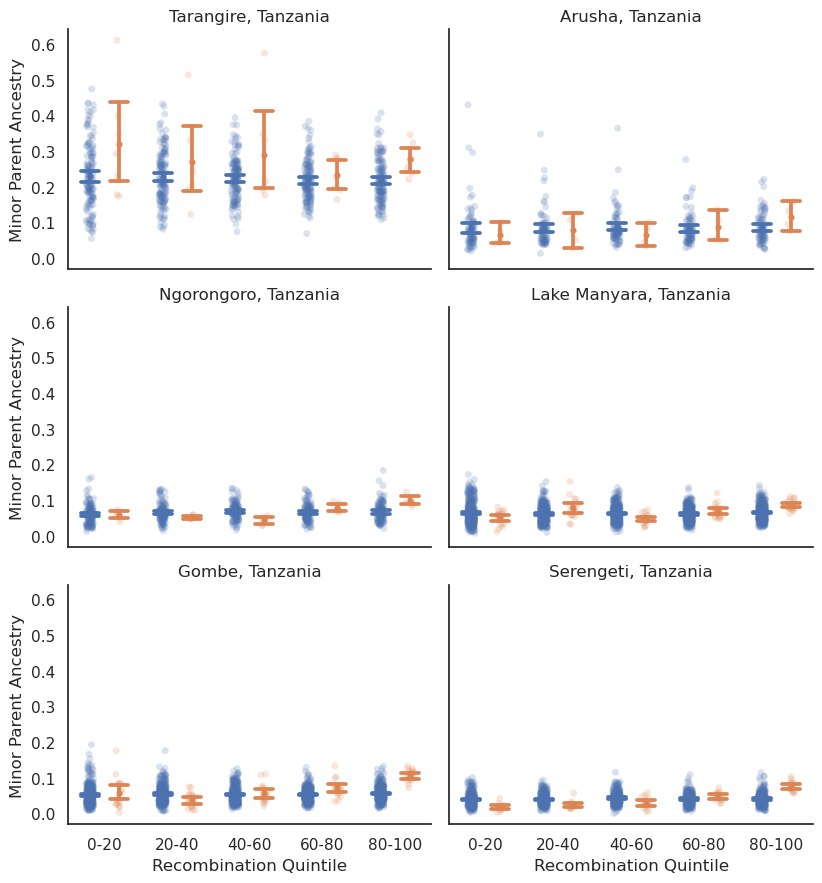

In [195]:
g = sns.FacetGrid(admix_div_ind_mean.loc[admix_div_ind_mean.Origin.isin(focus_pops6)], col="Origin",
                  col_wrap = 2, col_order=focus_pops6, aspect=1.4)
g.map_dataframe(sns.pointplot, y="minor_parent_percentage", x="Recombination Quantile", hue="Chromosome Type",
                linestyles="none", capsize=.25, errorbar=("ci", 95), scale = 0.5, dodge=0.4, palette=sns.color_palette())
g.map_dataframe(sns.stripplot, y="minor_parent_percentage", x="Recombination Quantile", hue="Chromosome Type",
                alpha=0.2, dodge=0.5, palette=sns.color_palette())
#g.set(ylim=(0, None))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Recombination Quintile", ylabel="Minor Parent Ancestry")
#g.set_xticklabels(g.get_xticks(), size = 15)

In [198]:
from matplotlib.colors import to_rgba
varied_alpha = [to_rgba(sns.color_palette()[0], 0.25), to_rgba(sns.color_palette()[1], 0.75)]
transparent_alpha = [to_rgba(sns.color_palette()[0], 0), to_rgba(sns.color_palette()[1], 0)]

/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/home/eriks/miniconda3/envs/baboondiversity/lib/python3.8/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


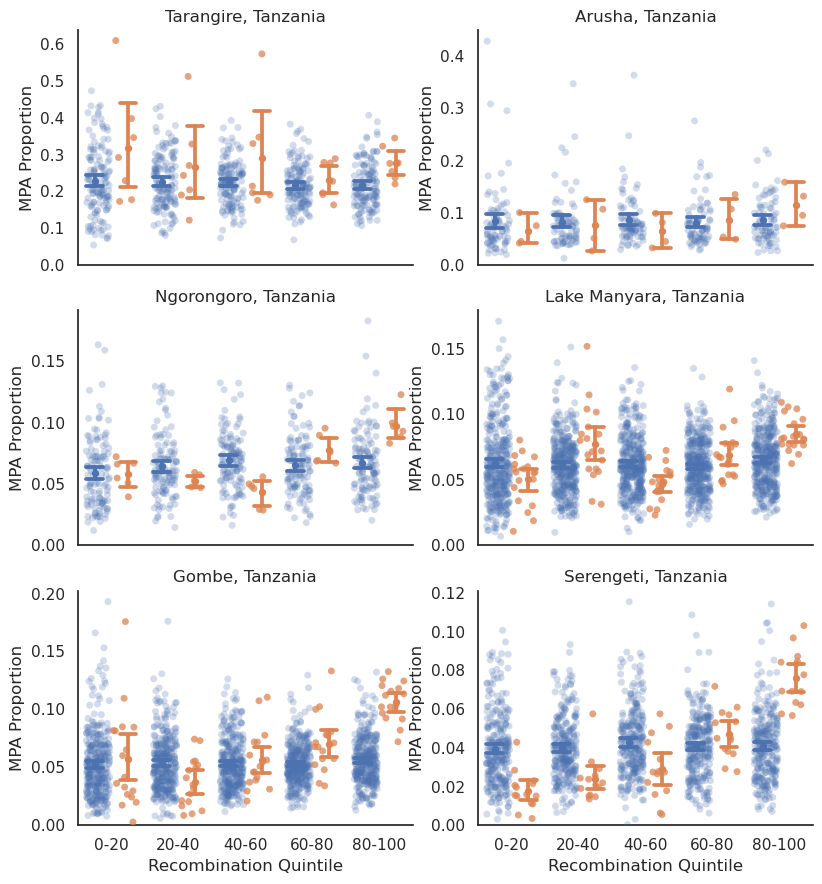

In [199]:
g = sns.FacetGrid(admix_div_ind_mean.loc[admix_div_ind_mean.Origin.isin(focus_pops6)], col="Origin",
                  col_wrap = 2, col_order=focus_pops6, aspect=1.4, sharey=False)
g.map_dataframe(sns.pointplot, y="minor_parent_percentage", x="Recombination Quantile", hue="Chromosome Type",
                linestyles="none", capsize=.25, errorbar=("ci", 95), scale = 0.6, dodge=0.5,
                palette=sns.color_palette())
g.map_dataframe(sns.stripplot, y="minor_parent_percentage", x="Recombination Quantile", hue="Chromosome Type",
                dodge=0.7, palette=varied_alpha, jitter=0.35, size=5)
g.set(ylim=(0, None))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Recombination Quintile", ylabel="MPA Proportion")
#g.set_xticklabels(g.get_xticks(), size = 15)

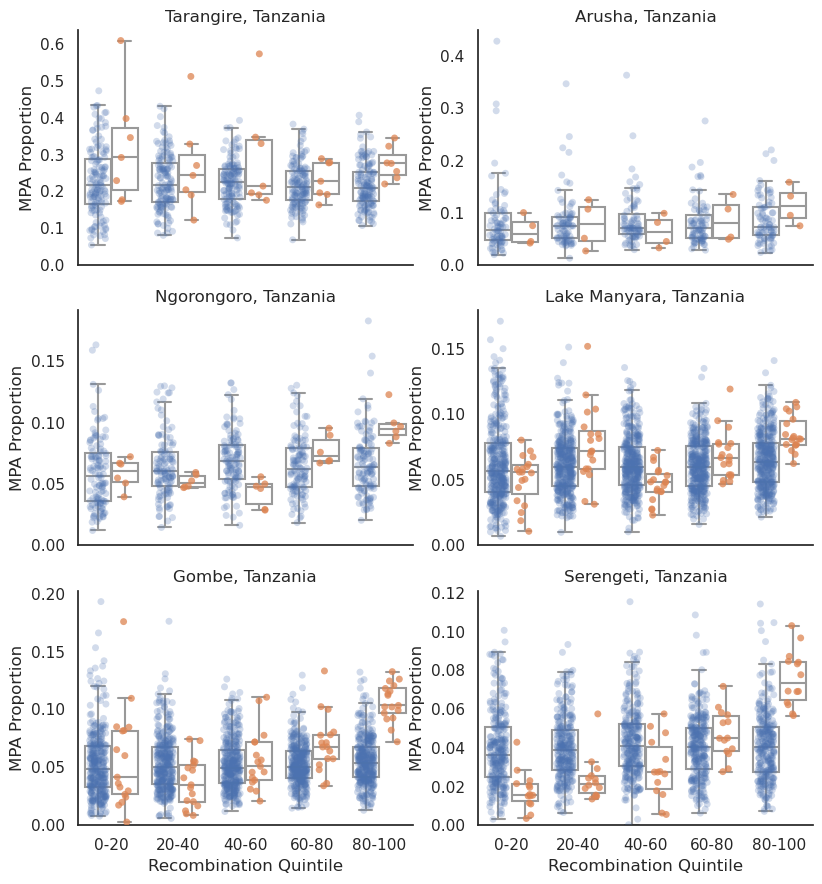

In [200]:
g = sns.FacetGrid(admix_div_ind_mean.loc[admix_div_ind_mean.Origin.isin(focus_pops6)], col="Origin",
                  col_wrap = 2, col_order=focus_pops6, aspect=1.4, sharey=False)
g.map_dataframe(sns.stripplot, y="minor_parent_percentage", x="Recombination Quantile", hue="Chromosome Type",
                dodge=0.5, palette=varied_alpha, jitter=0.25, size=5)
g.map_dataframe(sns.boxplot, y="minor_parent_percentage", x="Recombination Quantile", hue="Chromosome Type",
               palette=[(1,1,1), (1,1,1)], fliersize=0)
g.set(ylim=(0, None))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Recombination Quintile", ylabel="MPA Proportion")

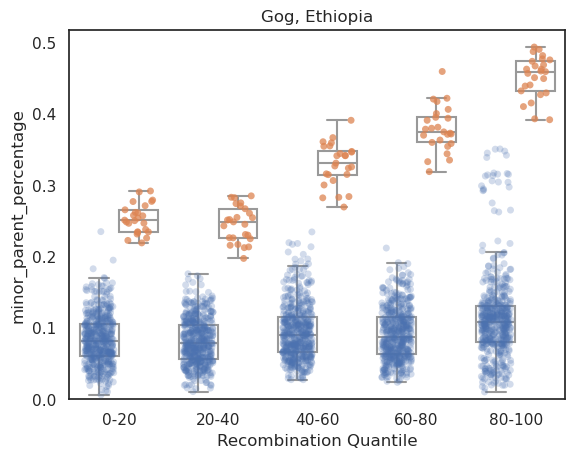

In [202]:
gog_observations = admix_div_ind_mean.loc[admix_div_ind_mean.Origin.isin(['Gog Woreda, Ethiopia'])]
g = sns.stripplot(gog_observations, y="minor_parent_percentage", x="Recombination Quantile", hue="Chromosome Type",
                dodge=0.5, jitter=0.3, palette=varied_alpha)
g = sns.boxplot(gog_observations, y="minor_parent_percentage", x="Recombination Quantile", hue="Chromosome Type",
               palette=[(1,1,1), (1,1,1)], fliersize=0)
g.set(ylim=(0, None))
g.set(title="Gog, Ethiopia")
plt.legend([],[], frameon=False)

In [203]:
admix_div_ind['Diversity Quantile'] = admix_div_ind.groupby(['chrom'])['diversity'].transform(
                     lambda x: pd.qcut(x, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"]))

admix_div_ind_mean = admix_div_ind.groupby(["Origin", "individual", "chrom", "Diversity Quantile"])[["minor_parent_percentage"]].mean().reset_index()
admix_div_ind_mean["Chromosome Type"] = ["chrX" if x == "chrX" else "autosome" for x in admix_div_ind_mean["chrom"]]
admix_div_ind_mean["Chromosome Type"].unique()

array(['autosome', 'chrX'], dtype=object)

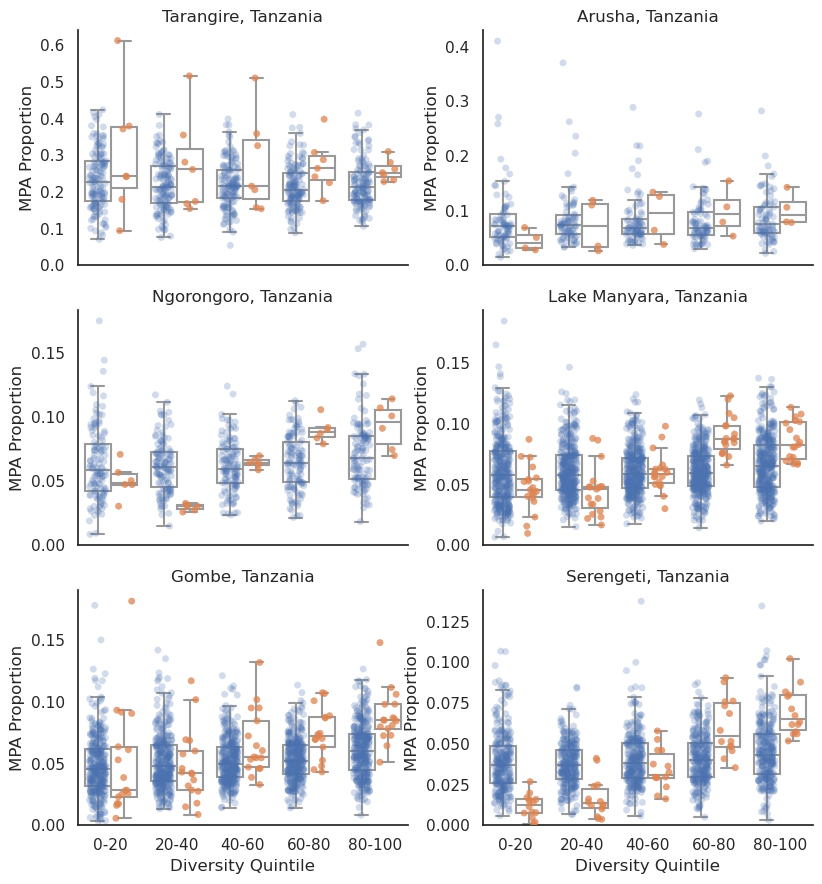

In [204]:
g = sns.FacetGrid(admix_div_ind_mean.loc[admix_div_ind_mean.Origin.isin(focus_pops6)], col="Origin",
                  col_wrap = 2, col_order=focus_pops6, aspect=1.4, sharey=False)
g.map_dataframe(sns.stripplot, y="minor_parent_percentage", x="Diversity Quantile", hue="Chromosome Type",
                dodge=0.5, palette=varied_alpha, jitter=0.25, size=5)
g.map_dataframe(sns.boxplot, y="minor_parent_percentage", x="Diversity Quantile", hue="Chromosome Type",
               palette=[(1,1,1), (1,1,1)], fliersize=0)
g.set(ylim=(0, None))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Diversity Quintile", ylabel="MPA Proportion")

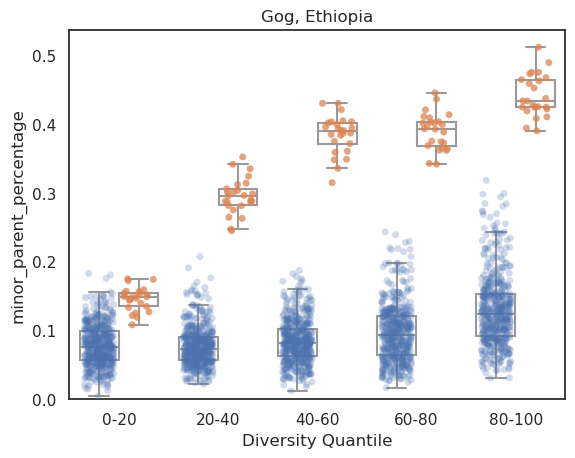

In [205]:
gog_observations = admix_div_ind_mean.loc[admix_div_ind_mean.Origin.isin(['Gog Woreda, Ethiopia'])]
g = sns.stripplot(gog_observations, y="minor_parent_percentage", x="Diversity Quantile", hue="Chromosome Type",
                dodge=0.5, jitter=0.3, palette=varied_alpha)
g = sns.boxplot(gog_observations, y="minor_parent_percentage", x="Diversity Quantile", hue="Chromosome Type",
               palette=[(1,1,1), (1,1,1)], fliersize=0)
g.set(ylim=(0, None))
g.set(title="Gog, Ethiopia")
plt.legend([],[], frameon=False)

In [27]:
admix_div_ind['Recombination Quantile'] = admix_div_ind.groupby(['chrom'])['average_cM_window'].transform(
                     lambda x: pd.qcut(x, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"]))

admix_div_ind_mean = admix_div_ind.groupby(["Origin", "individual", "chrom", "Recombination Quantile"])[["minor_parent_percentage"]].mean().reset_index()
admix_div_ind_mean["Chromosome Type"] = ["chrX" if x == "chrX" else "autosome" for x in admix_div_ind_mean["chrom"]]
admix_div_ind_mean["Chromosome Type"].unique()

array(['autosome', 'chrX'], dtype=object)

In [28]:
filter_callable_ind = admix_div_ind.loc[admix_div_ind.callable_frac > 0.75]
filter_callable_ind.loc[filter_callable_ind['Origin'] == 'Gog Woreda, Gambella region, Ethiopia_eth_case', ['Origin']] = 'Gog Woreda, Ethiopia'
filter_callable_ind = filter_callable_ind.loc[(filter_callable_ind.diversity >= 0.000513) &
                                 (filter_callable_ind.diversity <= 0.00408)]

In [29]:
filter_callable_ind

,chrom,start,diversity,individual,Origin,end_x,north_sum,Species,callable_frac,end_y,cM,end_cM,average_cM_window,genes,genic,North Percentage,minor_parent_percentage,local_minor_ancestry,Recombination Quantile,Diversity Quantile
0,chr1,0,0.00306,PD_0067,captive,100000,0,gelada,0.795,100000,0,0.36,3.6e-06,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0,1,0,80-100,80-100
1,chr1,0,0.00306,PD_0199,"Serengeti, Tanzania",100000,9.98e+04,anubis,0.795,100000,0,0.36,3.6e-06,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.998,0.0016,0.0016,80-100,80-100
2,chr1,0,0.00306,PD_0200,"Serengeti, Tanzania",100000,9.98e+04,anubis,0.795,100000,0,0.36,3.6e-06,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.998,0.0016,0.0016,80-100,80-100
3,chr1,0,0.00306,PD_0201,"Serengeti, Tanzania",100000,9.98e+04,anubis,0.795,100000,0,0.36,3.6e-06,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.998,0.0016,0.0016,80-100,80-100
4,chr1,0,0.00306,PD_0202,"Serengeti, Tanzania",100000,9.98e+04,anubis,0.795,100000,0,0.36,3.6e-06,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.998,0.0016,0.0016,80-100,80-100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6343451,chrX,142100000,0.000545,Sci_34449,"Chunga, Zambia_eth_case",142200000,1e+05,NaN,0.816,142200000,126,126,6.59e-07,"['MECP2', 'MECP2', 'MECP2', 'MECP2', 'MECP2']",True,1,0,0,40-60,40-60
6343452,chrX,142100000,0.000545,Sci_34474,"Chunga, Zambia",142200000,1e+05,kindae,0.816,142200000,126,126,6.59e-07,"['MECP2', 'MECP2', 'MECP2', 'MECP2', 'MECP2']",True,1,0,0,40-60,40-60
6343453,chrX,142100000,0.000545,Sci_34474,"Chunga, Zambia_eth_case",142200000,1e+05,NaN,0.816,142200000,126,126,6.59e-07,"['MECP2', 'MECP2', 'MECP2', 'MECP2', 'MECP2']",True,1,0,0,40-60,40-60
6343454,chrX,142100000,0.000545,Sci_97074,"Awash, Ethiopia",142200000,1e+05,hamadryas,0.816,142200000,126,126,6.59e-07,"['MECP2', 'MECP2', 'MECP2', 'MECP2', 'MECP2']",True,1,0,0,40-60,40-60


Main workflow where windows are grouped per population, resulting in 1 observation per 100kb window per population.

In [30]:
mean_window_df_tanz_eth = window_df_tanz_eth.groupby(["chrom", "Origin", "start", "end"])[["north_sum"]].mean().reset_index()
mean_window_df_tanz = window_df_tanz.groupby(["chrom", "Origin", "start", "end"])[["north_sum"]].mean().reset_index()
admix_div_mean = mean_diversity.merge(mean_window_df_tanz_eth, on=["chrom", "start"])
admix_div_mean["Species"] = admix_div_mean.Origin.map(dict(zip(meta_data_samples_sci.Origin, meta_data_samples_sci.Species)))
admix_div_mean = admix_div_mean.merge(c_r_g_df, on=["chrom", "start"])
admix_div_mean = admix_div_mean.loc[admix_div_mean.chrom != "all_chrX"]
admix_div_mean["North Percentage"] = admix_div_mean.north_sum/100000
admix_div_mean["logdiv"] = np.log10(admix_div_mean.diversity)
admix_div_mean["logrecomb"] = np.log10(admix_div_mean.average_cM_window)
admix_div_mean["norm_diversity"] = (admix_div_mean.diversity-admix_div_mean.diversity.mean())/admix_div_mean.diversity.std()
admix_div_mean["norm_recomb"] = (admix_div_mean.average_cM_window-admix_div_mean.average_cM_window.mean())/admix_div_mean.average_cM_window.std()

In [31]:
#Selecting the cases of interest and setting Minor Parent Ancestry
origins_interest = ['Arusha, Tanzania', 'Mahale, Tanzania',
       'Gog Woreda, Gambella region, Ethiopia_eth_case',
       'Gombe, Tanzania', 'Issa Valley, Tanzania',
       'Katavi, Tanzania','Lake Manyara, Tanzania',
       'Ngorongoro, Tanzania', 'Ruaha, Tanzania',
       'Selous, Tanzania', 'Serengeti, Tanzania', 'Tarangire, Tanzania',
       'Udzungwa, Tanzania']
admix_div_mean = admix_div_mean.loc[admix_div_mean.Origin.isin(origins_interest)]
admix_div_mean["minor_parent_percentage"] = [x if y == ("cynocephalus") or z == "Gog Woreda, Gambella region, Ethiopia_eth_case"
                                             else 1-x for x, y, z in zip(admix_div_mean["North Percentage"],
                                                                         admix_div_mean["Species"],
                                                                        admix_div_mean["Origin"])]
admix_div_mean["local_minor_ancestry"] = [min(x, 1-x) for x in admix_div_mean["North Percentage"]]

In [212]:
yellows = ['Ruaha, Tanzania', 'Mahale, Tanzania', 'Katavi, Tanzania']
olives = ['Arusha, Tanzania', 'Ngorongoro, Tanzania',
             'Lake Manyara, Tanzania', 'Gombe, Tanzania', 'Serengeti, Tanzania']
olives_with_tarangire = ['Tarangire, Tanzania', 'Arusha, Tanzania', 'Ngorongoro, Tanzania',
             'Lake Manyara, Tanzania', 'Gombe, Tanzania', 'Serengeti, Tanzania']
gog = ['Gog Woreda, Ethiopia']
result_order = ['Ruaha, Tanzania', 'Mahale, Tanzania', 'Katavi, Tanzania',
       'Tarangire, Tanzania', 'Arusha, Tanzania', 'Ngorongoro, Tanzania',
             'Lake Manyara, Tanzania', 'Gombe, Tanzania', 'Serengeti, Tanzania', 'Gog Woreda, Ethiopia']
result_order_no_gog = ['Ruaha, Tanzania', 'Mahale, Tanzania', 'Katavi, Tanzania',
       'Tarangire, Tanzania', 'Arusha, Tanzania', 'Ngorongoro, Tanzania',
             'Lake Manyara, Tanzania', 'Gombe, Tanzania', 'Serengeti, Tanzania']

In [33]:
import copy
from textwrap import dedent
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    import statsmodels
    assert statsmodels
    _has_statsmodels = True
except ImportError:
    _has_statsmodels = False

from seaborn import utils
from seaborn import algorithms as algo
from seaborn.axisgrid import FacetGrid, _facet_docs


__all__ = ["lmplot", "regplot", "residplot"]


class _LinearPlotter:
    """Base class for plotting relational data in tidy format.

    To get anything useful done you'll have to inherit from this, but setup
    code that can be abstracted out should be put here.

    """
    def establish_variables(self, data, **kws):
        """Extract variables from data or use directly."""
        self.data = data

        # Validate the inputs
        any_strings = any([isinstance(v, str) for v in kws.values()])
        if any_strings and data is None:
            raise ValueError("Must pass `data` if using named variables.")

        # Set the variables
        for var, val in kws.items():
            if isinstance(val, str):
                vector = data[val]
            elif isinstance(val, list):
                vector = np.asarray(val)
            else:
                vector = val
            if vector is not None and vector.shape != (1,):
                vector = np.squeeze(vector)
            if np.ndim(vector) > 1:
                err = "regplot inputs must be 1d"
                raise ValueError(err)
            setattr(self, var, vector)

    def dropna(self, *vars):
        """Remove observations with missing data."""
        vals = [getattr(self, var) for var in vars]
        vals = [v for v in vals if v is not None]
        not_na = np.all(np.column_stack([pd.notnull(v) for v in vals]), axis=1)
        for var in vars:
            val = getattr(self, var)
            if val is not None:
                setattr(self, var, val[not_na])

    def plot(self, ax):
        raise NotImplementedError


class _RegressionPlotter(_LinearPlotter):
    """Plotter for numeric independent variables with regression model.

    This does the computations and drawing for the `regplot` function, and
    is thus also used indirectly by `lmplot`.
    """
    def __init__(self, x, y, data=None, x_estimator=None, x_bins=None,
                 x_ci="ci", scatter=True, fit_reg=True, ci=95, n_boot=1000,
                 units=None, seed=None, order=1, logistic=False, lowess=False,
                 robust=False, weighted=False, logx=False, x_partial=None, y_partial=None,
                 truncate=False, dropna=True, x_jitter=None, y_jitter=None,
                 color=None, label=None):

        # Set member attributes
        self.x_estimator = x_estimator
        self.ci = ci
        self.x_ci = ci if x_ci == "ci" else x_ci
        self.n_boot = n_boot
        self.seed = seed
        self.scatter = scatter
        self.fit_reg = fit_reg
        self.order = order
        self.logistic = logistic
        self.weighted = weighted
        self.lowess = lowess
        self.robust = robust
        self.logx = logx
        self.truncate = truncate
        self.x_jitter = x_jitter
        self.y_jitter = y_jitter
        self.color = color
        self.label = label

        # Validate the regression options:
        #if sum((order > 1, logistic, robust, weighted, lowess, logx)) > 1:
        #    raise ValueError("Mutually exclusive regression options.")

        # Extract the data vals from the arguments or passed dataframe
        self.establish_variables(data, x=x, y=y, units=units,
                                 x_partial=x_partial, y_partial=y_partial)

        # Drop null observations
        if dropna:
            self.dropna("x", "y", "units", "x_partial", "y_partial")

        # Regress nuisance variables out of the data
        if self.x_partial is not None:
            self.x = self.regress_out(self.x, self.x_partial)
        if self.y_partial is not None:
            self.y = self.regress_out(self.y, self.y_partial)

        # Possibly bin the predictor variable, which implies a point estimate
        if x_bins is not None:
            self.x_estimator = np.mean if x_estimator is None else x_estimator
            x_discrete, x_bins = self.bin_predictor(x_bins)
            self.x_discrete = x_discrete
        else:
            self.x_discrete = self.x

        # Disable regression in case of singleton inputs
        if len(self.x) <= 1:
            self.fit_reg = False

        # Save the range of the x variable for the grid later
        if self.fit_reg:
            self.x_range = self.x.min(), self.x.max()

    @property
    def scatter_data(self):
        """Data where each observation is a point."""
        x_j = self.x_jitter
        if x_j is None:
            x = self.x
        else:
            x = self.x + np.random.uniform(-x_j, x_j, len(self.x))

        y_j = self.y_jitter
        if y_j is None:
            y = self.y
        else:
            y = self.y + np.random.uniform(-y_j, y_j, len(self.y))

        return x, y

    @property
    def estimate_data(self):
        """Data with a point estimate and CI for each discrete x value."""
        x, y = self.x_discrete, self.y
        vals = sorted(np.unique(x))
        points, cis = [], []

        for val in vals:

            # Get the point estimate of the y variable
            _y = y[x == val]
            est = self.x_estimator(_y)
            points.append(est)

            # Compute the confidence interval for this estimate
            if self.x_ci is None:
                cis.append(None)
            else:
                units = None
                if self.x_ci == "sd":
                    sd = np.std(_y)
                    _ci = est - sd, est + sd
                else:
                    if self.units is not None:
                        units = self.units[x == val]
                    boots = algo.bootstrap(_y,
                                           func=self.x_estimator,
                                           n_boot=self.n_boot,
                                           units=units,
                                           seed=self.seed)
                    _ci = utils.ci(boots, self.x_ci)
                cis.append(_ci)

        return vals, points, cis

    def _check_statsmodels(self):
        """Check whether statsmodels is installed if any boolean options require it."""
        options = "logistic", "robust", "lowess"
        err = "`{}=True` requires statsmodels, an optional dependency, to be installed."
        for option in options:
            if getattr(self, option) and not _has_statsmodels:
                raise RuntimeError(err.format(option))

    def fit_regression(self, ax=None, x_range=None, grid=None):
        """Fit the regression model."""
        self._check_statsmodels()

        # Create the grid for the regression
        if grid is None:
            if self.truncate:
                x_min, x_max = self.x_range
            else:
                if ax is None:
                    x_min, x_max = x_range
                else:
                    x_min, x_max = ax.get_xlim()
            grid = np.linspace(x_min, x_max, 100)
        ci = self.ci

        # Fit the regression
        if self.order > 1:
            yhat, yhat_boots = self.fit_poly(grid, self.order)
        elif self.logistic: 
            from statsmodels.genmod.generalized_linear_model import GLM
            from statsmodels.genmod.families import Binomial
            yhat, yhat_boots = self.fit_statsmodels(grid, GLM,
                                                    family=Binomial())
        elif self.weighted: 
            from statsmodels.genmod.generalized_linear_model import GLM
            from statsmodels.genmod.families import Binomial
            yhat, yhat_boots = self.fit_statsmodels(grid, GLM,
                                                   var_weights=np.asarray(self.x))
        elif self.lowess:
            ci = None
            grid, yhat = self.fit_lowess()
        elif self.robust:
            from statsmodels.robust.robust_linear_model import RLM
            yhat, yhat_boots = self.fit_statsmodels(grid, RLM)
        elif self.logx:
            yhat, yhat_boots = self.fit_logx(grid)
        else:
            yhat, yhat_boots = self.fit_fast(grid)

        # Compute the confidence interval at each grid point
        if ci is None:
            err_bands = None
        else:
            err_bands = utils.ci(yhat_boots, ci, axis=0)

        return grid, yhat, err_bands

    def fit_fast(self, grid):
        """Low-level regression and prediction using linear algebra."""
        def reg_func(_x, _y):
            return np.linalg.pinv(_x).dot(_y)

        X, y = np.c_[np.ones(len(self.x)), self.x], self.y
        grid = np.c_[np.ones(len(grid)), grid]
        yhat = grid.dot(reg_func(X, y))
        if self.ci is None:
            return yhat, None

        beta_boots = algo.bootstrap(X, y,
                                    func=reg_func,
                                    n_boot=self.n_boot,
                                    units=self.units,
                                    seed=self.seed).T
        yhat_boots = grid.dot(beta_boots).T
        return yhat, yhat_boots

    def fit_poly(self, grid, order):
        """Regression using numpy polyfit for higher-order trends."""
        def reg_func(_x, _y):
            return np.polyval(np.polyfit(_x, _y, order), grid)

        x, y = self.x, self.y
        yhat = reg_func(x, y)
        if self.ci is None:
            return yhat, None

        yhat_boots = algo.bootstrap(x, y,
                                    func=reg_func,
                                    n_boot=self.n_boot,
                                    units=self.units,
                                    seed=self.seed)
        return yhat, yhat_boots

    def fit_statsmodels(self, grid, model, **kwargs):
        """More general regression function using statsmodels objects."""
        import statsmodels.tools.sm_exceptions as sme
        X, y = np.c_[np.ones(len(self.x)), self.x], self.y
        grid = np.c_[np.ones(len(grid)), grid]
        def reg_func(_x, _y, **kwargs):
            err_classes = (sme.PerfectSeparationError,)
            try:
                with warnings.catch_warnings():
                    if hasattr(sme, "PerfectSeparationWarning"):
                        # statsmodels>=0.14.0
                        warnings.simplefilter("error", sme.PerfectSeparationWarning)
                        err_classes = (*err_classes, sme.PerfectSeparationWarning)
                    m = model(_y, _x, var_weights=np.asarray(_x[:, 1])).fit()
                    yhat = m.predict(grid)
                    #print(m.summary(), self.x, len(_x), _x[:, 1])
            except err_classes:
                yhat = np.empty(len(grid))
                yhat.fill(np.nan)
            return yhat

        yhat = reg_func(X, y, **kwargs)
        if self.ci is None:
            return yhat, None

        yhat_boots = bootstrap(X, y,
                                    func=reg_func,
                                    n_boot=self.n_boot,
                                    units=self.units,
                                    seed=self.seed,
                                   var_weights=np.asarray(self.x))
        return yhat, yhat_boots

    def fit_lowess(self):
        """Fit a locally-weighted regression, which returns its own grid."""
        from statsmodels.nonparametric.smoothers_lowess import lowess
        grid, yhat = lowess(self.y, self.x).T
        return grid, yhat

    def fit_logx(self, grid):
        """Fit the model in log-space."""
        X, y = np.c_[np.ones(len(self.x)), self.x], self.y
        grid = np.c_[np.ones(len(grid)), np.log(grid)]

        def reg_func(_x, _y):
            _x = np.c_[_x[:, 0], np.log(_x[:, 1])]
            return np.linalg.pinv(_x).dot(_y)

        yhat = grid.dot(reg_func(X, y))
        if self.ci is None:
            return yhat, None

        beta_boots = algo.bootstrap(X, y,
                                    func=reg_func,
                                    n_boot=self.n_boot,
                                    units=self.units,
                                    seed=self.seed).T
        yhat_boots = grid.dot(beta_boots).T
        return yhat, yhat_boots

    def bin_predictor(self, bins):
        """Discretize a predictor by assigning value to closest bin."""
        x = np.asarray(self.x)
        if np.isscalar(bins):
            percentiles = np.linspace(0, 100, bins + 2)[1:-1]
            bins = np.percentile(x, percentiles)
        else:
            bins = np.ravel(bins)

        dist = np.abs(np.subtract.outer(x, bins))
        x_binned = bins[np.argmin(dist, axis=1)].ravel()

        return x_binned, bins

    def regress_out(self, a, b):
        """Regress b from a keeping a's original mean."""
        a_mean = a.mean()
        a = a - a_mean
        b = b - b.mean()
        b = np.c_[b]
        a_prime = a - b.dot(np.linalg.pinv(b).dot(a))
        return np.asarray(a_prime + a_mean).reshape(a.shape)

    def plot(self, ax, scatter_kws, line_kws):
        """Draw the full plot."""
        # Insert the plot label into the correct set of keyword arguments
        if self.scatter:
            scatter_kws["label"] = self.label
        else:
            line_kws["label"] = self.label

        # Use the current color cycle state as a default
        if self.color is None:
            lines, = ax.plot([], [])
            color = lines.get_color()
            lines.remove()
        else:
            color = self.color

        # Ensure that color is hex to avoid matplotlib weirdness
        color = mpl.colors.rgb2hex(mpl.colors.colorConverter.to_rgb(color))

        # Let color in keyword arguments override overall plot color
        scatter_kws.setdefault("color", color)
        line_kws.setdefault("color", color)

        # Draw the constituent plots
        if self.scatter:
            self.scatterplot(ax, scatter_kws)

        if self.fit_reg:
            self.lineplot(ax, line_kws)

        # Label the axes
        if hasattr(self.x, "name"):
            ax.set_xlabel(self.x.name)
        if hasattr(self.y, "name"):
            ax.set_ylabel(self.y.name)

    def scatterplot(self, ax, kws):
        """Draw the data."""
        # Treat the line-based markers specially, explicitly setting larger
        # linewidth than is provided by the seaborn style defaults.
        # This would ideally be handled better in matplotlib (i.e., distinguish
        # between edgewidth for solid glyphs and linewidth for line glyphs
        # but this should do for now.
        line_markers = ["1", "2", "3", "4", "+", "x", "|", "_"]
        if self.x_estimator is None:
            if "marker" in kws and kws["marker"] in line_markers:
                lw = mpl.rcParams["lines.linewidth"]
            else:
                lw = mpl.rcParams["lines.markeredgewidth"]
            kws.setdefault("linewidths", lw)

            if not hasattr(kws['color'], 'shape') or kws['color'].shape[1] < 4:
                kws.setdefault("alpha", .8)

            x, y = self.scatter_data
            ax.scatter(x, y, **kws)
        else:
            # TODO abstraction
            ci_kws = {"color": kws["color"]}
            if "alpha" in kws:
                ci_kws["alpha"] = kws["alpha"]
            ci_kws["linewidth"] = mpl.rcParams["lines.linewidth"] * 1.75
            kws.setdefault("s", 50)

            xs, ys, cis = self.estimate_data
            if [ci for ci in cis if ci is not None]:
                for x, ci in zip(xs, cis):
                    ax.plot([x, x], ci, **ci_kws)
            ax.scatter(xs, ys, **kws)

    def lineplot(self, ax, kws):
        """Draw the model."""
        # Fit the regression model
        grid, yhat, err_bands = self.fit_regression(ax)
        edges = grid[0], grid[-1]

        # Get set default aesthetics
        fill_color = kws["color"]
        lw = kws.pop("lw", mpl.rcParams["lines.linewidth"] * 1.5)
        kws.setdefault("linewidth", lw)

        # Draw the regression line and confidence interval
        line, = ax.plot(grid, yhat, **kws)
        if not self.truncate:
            line.sticky_edges.x[:] = edges  # Prevent mpl from adding margin
        if err_bands is not None:
            ax.fill_between(grid, *err_bands, facecolor=fill_color, alpha=.15)


_regression_docs = dict(

    model_api=dedent("""\
    There are a number of mutually exclusive options for estimating the
    regression model. See the :ref:`tutorial <regression_tutorial>` for more
    information.\
    """),
    regplot_vs_lmplot=dedent("""\
    The :func:`regplot` and :func:`lmplot` functions are closely related, but
    the former is an axes-level function while the latter is a figure-level
    function that combines :func:`regplot` and :class:`FacetGrid`.\
    """),
    x_estimator=dedent("""\
    x_estimator : callable that maps vector -> scalar, optional
        Apply this function to each unique value of ``x`` and plot the
        resulting estimate. This is useful when ``x`` is a discrete variable.
        If ``x_ci`` is given, this estimate will be bootstrapped and a
        confidence interval will be drawn.\
    """),
    x_bins=dedent("""\
    x_bins : int or vector, optional
        Bin the ``x`` variable into discrete bins and then estimate the central
        tendency and a confidence interval. This binning only influences how
        the scatterplot is drawn; the regression is still fit to the original
        data.  This parameter is interpreted either as the number of
        evenly-sized (not necessary spaced) bins or the positions of the bin
        centers. When this parameter is used, it implies that the default of
        ``x_estimator`` is ``numpy.mean``.\
    """),
    x_ci=dedent("""\
    x_ci : "ci", "sd", int in [0, 100] or None, optional
        Size of the confidence interval used when plotting a central tendency
        for discrete values of ``x``. If ``"ci"``, defer to the value of the
        ``ci`` parameter. If ``"sd"``, skip bootstrapping and show the
        standard deviation of the observations in each bin.\
    """),
    scatter=dedent("""\
    scatter : bool, optional
        If ``True``, draw a scatterplot with the underlying observations (or
        the ``x_estimator`` values).\
    """),
    fit_reg=dedent("""\
    fit_reg : bool, optional
        If ``True``, estimate and plot a regression model relating the ``x``
        and ``y`` variables.\
    """),
    ci=dedent("""\
    ci : int in [0, 100] or None, optional
        Size of the confidence interval for the regression estimate. This will
        be drawn using translucent bands around the regression line. The
        confidence interval is estimated using a bootstrap; for large
        datasets, it may be advisable to avoid that computation by setting
        this parameter to None.\
    """),
    n_boot=dedent("""\
    n_boot : int, optional
        Number of bootstrap resamples used to estimate the ``ci``. The default
        value attempts to balance time and stability; you may want to increase
        this value for "final" versions of plots.\
    """),
    units=dedent("""\
    units : variable name in ``data``, optional
        If the ``x`` and ``y`` observations are nested within sampling units,
        those can be specified here. This will be taken into account when
        computing the confidence intervals by performing a multilevel bootstrap
        that resamples both units and observations (within unit). This does not
        otherwise influence how the regression is estimated or drawn.\
    """),
    seed=dedent("""\
    seed : int, numpy.random.Generator, or numpy.random.RandomState, optional
        Seed or random number generator for reproducible bootstrapping.\
    """),
    order=dedent("""\
    order : int, optional
        If ``order`` is greater than 1, use ``numpy.polyfit`` to estimate a
        polynomial regression.\
    """),
    logistic=dedent("""\
    logistic : bool, optional
        If ``True``, assume that ``y`` is a binary variable and use
        ``statsmodels`` to estimate a logistic regression model. Note that this
        is substantially more computationally intensive than linear regression,
        so you may wish to decrease the number of bootstrap resamples
        (``n_boot``) or set ``ci`` to None.\
    """),
    lowess=dedent("""\
    lowess : bool, optional
        If ``True``, use ``statsmodels`` to estimate a nonparametric lowess
        model (locally weighted linear regression). Note that confidence
        intervals cannot currently be drawn for this kind of model.\
    """),
    robust=dedent("""\
    robust : bool, optional
        If ``True``, use ``statsmodels`` to estimate a robust regression. This
        will de-weight outliers. Note that this is substantially more
        computationally intensive than standard linear regression, so you may
        wish to decrease the number of bootstrap resamples (``n_boot``) or set
        ``ci`` to None.\
    """),
    logx=dedent("""\
    logx : bool, optional
        If ``True``, estimate a linear regression of the form y ~ log(x), but
        plot the scatterplot and regression model in the input space. Note that
        ``x`` must be positive for this to work.\
    """),
    xy_partial=dedent("""\
    {x,y}_partial : strings in ``data`` or matrices
        Confounding variables to regress out of the ``x`` or ``y`` variables
        before plotting.\
    """),
    truncate=dedent("""\
    truncate : bool, optional
        If ``True``, the regression line is bounded by the data limits. If
        ``False``, it extends to the ``x`` axis limits.
    """),
    dropna=dedent("""\
    dropna : bool, optional
        If ``True``, remove observations with missing data from the plot.
    """),
    xy_jitter=dedent("""\
    {x,y}_jitter : floats, optional
        Add uniform random noise of this size to either the ``x`` or ``y``
        variables. The noise is added to a copy of the data after fitting the
        regression, and only influences the look of the scatterplot. This can
        be helpful when plotting variables that take discrete values.\
    """),
    scatter_line_kws=dedent("""\
    {scatter,line}_kws : dictionaries
        Additional keyword arguments to pass to ``plt.scatter`` and
        ``plt.plot``.\
    """),
)
_regression_docs.update(_facet_docs)


def lmplot(
    data, *,
    x=None, y=None, hue=None, col=None, row=None,
    palette=None, col_wrap=None, height=5, aspect=1, markers="o",
    sharex=None, sharey=None, hue_order=None, col_order=None, row_order=None,
    legend=True, legend_out=None, x_estimator=None, x_bins=None,
    x_ci="ci", scatter=True, fit_reg=True, ci=95, n_boot=1000,
    units=None, seed=None, order=1, logistic=False, lowess=False,
    robust=False, weighted=False, logx=False, x_partial=None, y_partial=None,
    truncate=True, x_jitter=None, y_jitter=None, scatter_kws=None,
    line_kws=None, facet_kws=None,
):

    if facet_kws is None:
        facet_kws = {}

    def facet_kw_deprecation(key, val):
        msg = (
            f"{key} is deprecated from the `lmplot` function signature. "
            "Please update your code to pass it using `facet_kws`."
        )
        if val is not None:
            warnings.warn(msg, UserWarning)
            facet_kws[key] = val

    facet_kw_deprecation("sharex", sharex)
    facet_kw_deprecation("sharey", sharey)
    facet_kw_deprecation("legend_out", legend_out)

    if data is None:
        raise TypeError("Missing required keyword argument `data`.")

    # Reduce the dataframe to only needed columns
    need_cols = [x, y, hue, col, row, units, x_partial, y_partial]
    cols = np.unique([a for a in need_cols if a is not None]).tolist()
    data = data[cols]

    # Initialize the grid
    facets = FacetGrid(
        data, row=row, col=col, hue=hue,
        palette=palette,
        row_order=row_order, col_order=col_order, hue_order=hue_order,
        height=height, aspect=aspect, col_wrap=col_wrap,
        **facet_kws,
    )

    # Add the markers here as FacetGrid has figured out how many levels of the
    # hue variable are needed and we don't want to duplicate that process
    if facets.hue_names is None:
        n_markers = 1
    else:
        n_markers = len(facets.hue_names)
    if not isinstance(markers, list):
        markers = [markers] * n_markers
    if len(markers) != n_markers:
        raise ValueError("markers must be a singleton or a list of markers "
                         "for each level of the hue variable")
    facets.hue_kws = {"marker": markers}

    #def update_datalim(data, x, y, ax, **kws):
    #    xys = data[[x, y]].to_numpy().astype(float)
    #    ax.update_datalim(xys, updatey=False)
    #    ax.autoscale_view(scaley=False)

    #facets.map_dataframe(update_datalim, x=x, y=y)

    # Draw the regression plot on each facet
    regplot_kws = dict(
        x_estimator=x_estimator, x_bins=x_bins, x_ci=x_ci,
        scatter=scatter, fit_reg=fit_reg, ci=ci, n_boot=n_boot, units=units,
        seed=seed, order=order, logistic=logistic, lowess=lowess,
        robust=robust, weighted=weighted, logx=logx, x_partial=x_partial, y_partial=y_partial,
        truncate=truncate, x_jitter=x_jitter, y_jitter=y_jitter,
        scatter_kws=scatter_kws, line_kws=line_kws,
    )
    facets.map_dataframe(regplot, x=x, y=y, **regplot_kws)
    facets.set_axis_labels(x, y)

    # Add a legend
    if legend and (hue is not None) and (hue not in [col, row]):
        facets.add_legend()
    return facets


lmplot.__doc__ = dedent("""\
    Plot data and regression model fits across a FacetGrid.

    This function combines :func:`regplot` and :class:`FacetGrid`. It is
    intended as a convenient interface to fit regression models across
    conditional subsets of a dataset.

    When thinking about how to assign variables to different facets, a general
    rule is that it makes sense to use ``hue`` for the most important
    comparison, followed by ``col`` and ``row``. However, always think about
    your particular dataset and the goals of the visualization you are
    creating.

    {model_api}

    The parameters to this function span most of the options in
    :class:`FacetGrid`, although there may be occasional cases where you will
    want to use that class and :func:`regplot` directly.

    Parameters
    ----------
    {data}
    x, y : strings, optional
        Input variables; these should be column names in ``data``.
    hue, col, row : strings
        Variables that define subsets of the data, which will be drawn on
        separate facets in the grid. See the ``*_order`` parameters to control
        the order of levels of this variable.
    {palette}
    {col_wrap}
    {height}
    {aspect}
    markers : matplotlib marker code or list of marker codes, optional
        Markers for the scatterplot. If a list, each marker in the list will be
        used for each level of the ``hue`` variable.
    {share_xy}

        .. deprecated:: 0.12.0
            Pass using the `facet_kws` dictionary.

    {{hue,col,row}}_order : lists, optional
        Order for the levels of the faceting variables. By default, this will
        be the order that the levels appear in ``data`` or, if the variables
        are pandas categoricals, the category order.
    legend : bool, optional
        If ``True`` and there is a ``hue`` variable, add a legend.
    {legend_out}

        .. deprecated:: 0.12.0
            Pass using the `facet_kws` dictionary.

    {x_estimator}
    {x_bins}
    {x_ci}
    {scatter}
    {fit_reg}
    {ci}
    {n_boot}
    {units}
    {seed}
    {order}
    {logistic}
    {lowess}
    {robust}
    {logx}
    {xy_partial}
    {truncate}
    {xy_jitter}
    {scatter_line_kws}
    facet_kws : dict
        Dictionary of keyword arguments for :class:`FacetGrid`.

    Returns
    -------
    :class:`FacetGrid`
        The :class:`FacetGrid` object with the plot on it for further tweaking.

    See Also
    --------
    regplot : Plot data and a conditional model fit.
    FacetGrid : Subplot grid for plotting conditional relationships.
    pairplot : Combine :func:`regplot` and :class:`PairGrid` (when used with
               ``kind="reg"``).

    Notes
    -----

    {regplot_vs_lmplot}

    Examples
    --------

    .. include:: ../docstrings/lmplot.rst

    """).format(**_regression_docs)


def regplot(
    data=None, *, x=None, y=None,
    x_estimator=None, x_bins=None, x_ci="ci",
    scatter=True, fit_reg=True, ci=95, n_boot=1000, units=None,
    seed=None, order=1, logistic=False, lowess=False, robust=False, weighted=False,
    logx=False, x_partial=None, y_partial=None,
    truncate=True, dropna=True, x_jitter=None, y_jitter=None,
    label=None, color=None, marker="o",
    scatter_kws=None, line_kws=None, ax=None
):

    plotter = _RegressionPlotter(x, y, data, x_estimator, x_bins, x_ci,
                                 scatter, fit_reg, ci, n_boot, units, seed,
                                 order, logistic, lowess, robust, weighted, logx,
                                 x_partial, y_partial, truncate, dropna,
                                 x_jitter, y_jitter, color, label)

    if ax is None:
        ax = plt.gca()

    scatter_kws = {} if scatter_kws is None else copy.copy(scatter_kws)
    scatter_kws["marker"] = marker
    line_kws = {} if line_kws is None else copy.copy(line_kws)
    plotter.plot(ax, scatter_kws, line_kws)
    return ax


regplot.__doc__ = dedent("""\
    Plot data and a linear regression model fit.

    {model_api}

    Parameters
    ----------
    x, y : string, series, or vector array
        Input variables. If strings, these should correspond with column names
        in ``data``. When pandas objects are used, axes will be labeled with
        the series name.
    {data}
    {x_estimator}
    {x_bins}
    {x_ci}
    {scatter}
    {fit_reg}
    {ci}
    {n_boot}
    {units}
    {seed}
    {order}
    {logistic}
    {lowess}
    {robust}
    {logx}
    {xy_partial}
    {truncate}
    {dropna}
    {xy_jitter}
    label : string
        Label to apply to either the scatterplot or regression line (if
        ``scatter`` is ``False``) for use in a legend.
    color : matplotlib color
        Color to apply to all plot elements; will be superseded by colors
        passed in ``scatter_kws`` or ``line_kws``.
    marker : matplotlib marker code
        Marker to use for the scatterplot glyphs.
    {scatter_line_kws}
    ax : matplotlib Axes, optional
        Axes object to draw the plot onto, otherwise uses the current Axes.

    Returns
    -------
    ax : matplotlib Axes
        The Axes object containing the plot.

    See Also
    --------
    lmplot : Combine :func:`regplot` and :class:`FacetGrid` to plot multiple
             linear relationships in a dataset.
    jointplot : Combine :func:`regplot` and :class:`JointGrid` (when used with
                ``kind="reg"``).
    pairplot : Combine :func:`regplot` and :class:`PairGrid` (when used with
               ``kind="reg"``).
    residplot : Plot the residuals of a linear regression model.

    Notes
    -----

    {regplot_vs_lmplot}


    It's also easy to combine :func:`regplot` and :class:`JointGrid` or
    :class:`PairGrid` through the :func:`jointplot` and :func:`pairplot`
    functions, although these do not directly accept all of :func:`regplot`'s
    parameters.

    Examples
    --------

    .. include:: ../docstrings/regplot.rst

    """).format(**_regression_docs)


def bootstrap(*args, **kwargs):
    """Resample one or more arrays with replacement and store aggregate values.

    Positional arguments are a sequence of arrays to bootstrap along the first
    axis and pass to a summary function.

    Keyword arguments:
        n_boot : int, default=10000
            Number of iterations
        axis : int, default=None
            Will pass axis to ``func`` as a keyword argument.
        units : array, default=None
            Array of sampling unit IDs. When used the bootstrap resamples units
            and then observations within units instead of individual
            datapoints.
        func : string or callable, default="mean"
            Function to call on the args that are passed in. If string, uses as
            name of function in the numpy namespace. If nans are present in the
            data, will try to use nan-aware version of named function.
        seed : Generator | SeedSequence | RandomState | int | None
            Seed for the random number generator; useful if you want
            reproducible resamples.

    Returns
    -------
    boot_dist: array
        array of bootstrapped statistic values

    """
    # Ensure list of arrays are same length
    if len(np.unique(list(map(len, args)))) > 1:
        raise ValueError("All input arrays must have the same length")
    n = len(args[0])

    # Default keyword arguments
    n_boot = kwargs.get("n_boot", 10000)
    func = kwargs.get("func", "mean")
    axis = kwargs.get("axis", None)
    units = kwargs.get("units", None)
    var_weights = kwargs.get("var_weights", None)
    random_seed = kwargs.get("random_seed", None)
    if random_seed is not None:
        msg = "`random_seed` has been renamed to `seed` and will be removed"
        warnings.warn(msg)
    seed = kwargs.get("seed", random_seed)
    if axis is None:
        func_kwargs = dict()
    else:
        func_kwargs = dict(axis=axis)

    # Initialize the resampler
    if isinstance(seed, np.random.RandomState):
        rng = seed
    else:
        rng = np.random.default_rng(seed)

    # Coerce to arrays
    args = list(map(np.asarray, args))
    if units is not None:
        units = np.asarray(units)

    if isinstance(func, str):

        # Allow named numpy functions
        f = getattr(np, func)

        # Try to use nan-aware version of function if necessary
        missing_data = np.isnan(np.sum(np.column_stack(args)))

        if missing_data and not func.startswith("nan"):
            nanf = getattr(np, f"nan{func}", None)
            if nanf is None:
                msg = f"Data contain nans but no nan-aware version of `{func}` found"
                warnings.warn(msg, UserWarning)
            else:
                f = nanf

    else:
        f = func

    # Handle numpy changes
    try:
        integers = rng.integers
    except AttributeError:
        integers = rng.randint


    boot_dist = []
    for i in range(int(n_boot)):
        resampler = integers(0, n, n, dtype=np.intp)  # intp is indexing dtype
        sample = [a.take(resampler, axis=0) for a in args]
        boot_dist.append(f(*sample, **func_kwargs))
    return np.array(boot_dist)

In [34]:
filter_callable = admix_div_mean.loc[admix_div_mean.callable_frac > 0.75]
filter_callable.loc[filter_callable['Origin'] == 'Gog Woreda, Gambella region, Ethiopia_eth_case', ['Origin']] = 'Gog Woreda, Ethiopia'
filter_callable["diversity"].quantile([0.005, 0.995])

0.005     0.000513
0.995      0.00408
Name: diversity, dtype: float64

In [35]:
len(filter_callable)/len(admix_div_mean)

0.9890152245133937

In [36]:
filter_callable = admix_div_mean.loc[admix_div_mean.callable_frac > 0.75]
filter_callable.loc[filter_callable['Origin'] == 'Gog Woreda, Gambella region, Ethiopia_eth_case', ['Origin']] = 'Gog Woreda, Ethiopia'
filter_qcut = filter_callable.loc[(filter_callable.diversity >= 0.000513) &
                                 (filter_callable.diversity <= 0.00408)]

In [37]:
o_l, stat_l, pval_l = [], [], []
for o in result_order:
    o_div = filter_callable.loc[filter_callable.Origin == o]
    o_div = o_div.loc[(o_div.minor_parent_percentage < 0.5)]
    st, pval = stats.spearmanr(o_div.diversity, o_div["minor_parent_percentage"])
    print(o, stats.spearmanr(o_div.diversity, o_div["minor_parent_percentage"]))
    o_l.append(o), stat_l.append(st), pval_l.append(pval)

Ruaha, Tanzania SignificanceResult(statistic=0.07445508541176768, pvalue=1.0628356029283243e-32)
Mahale, Tanzania SignificanceResult(statistic=0.051829571182174815, pvalue=1.6129593439043073e-16)
Katavi, Tanzania SignificanceResult(statistic=0.08193351160315887, pvalue=3.29619207378878e-38)
Tarangire, Tanzania SignificanceResult(statistic=-0.013756175336525806, pvalue=0.03494512611907831)
Arusha, Tanzania SignificanceResult(statistic=0.03478142037980935, pvalue=3.481475354653773e-08)
Ngorongoro, Tanzania SignificanceResult(statistic=0.06127053348697334, pvalue=1.5797592897293404e-22)
Lake Manyara, Tanzania SignificanceResult(statistic=0.05754560271518479, pvalue=3.5353252039955875e-20)
Gombe, Tanzania SignificanceResult(statistic=0.08633276679439507, pvalue=1.783691719426173e-43)
Serengeti, Tanzania SignificanceResult(statistic=0.05645522117623081, pvalue=1.5004520197754787e-19)


In [38]:
pd.DataFrame({"Origin": o_l, "Statistic": stat_l, "P-Value": pval_l})

,Origin,Statistic,P-Value
0,"Ruaha, Tanzania",0.0745,1.06e-32
1,"Mahale, Tanzania",0.0518,1.61e-16
2,"Katavi, Tanzania",0.0819,3.3e-38
3,"Tarangire, Tanzania",-0.0138,0.0349
4,"Arusha, Tanzania",0.0348,3.48e-08
5,"Ngorongoro, Tanzania",0.0613,1.58e-22
6,"Lake Manyara, Tanzania",0.0575,3.54e-20
7,"Gombe, Tanzania",0.0863,1.78e-43
8,"Serengeti, Tanzania",0.0565,1.5e-19


In [39]:
import statsmodels.formula.api as smf

o_l, slope_l, intercept_l, rval_l, pval_l, stderr_l = [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut.loc[filter_qcut.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity", data=o_div).fit()
    print(o, glm_results.summary())

Ruaha, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                        0.010641
Method:                               IRLS   Log-Likelihood:                 21662.
Date:                     Fri, 14 Aug 2026   Deviance:                       270.31
Time:                             08:41:18   Pearson chi2:                     270.
No. Iterations:                          3   Pseudo R-squ. (CS):           0.004510
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

In [40]:
import statsmodels.api as sm
import numpy as np

df_l = []
for o in result_order:
    o_div = filter_qcut.loc[filter_qcut.Origin == o]
    o_div = o_div.loc[(o_div.callable_frac > 0.75)]
    Y = o_div["minor_parent_percentage"]
    X = o_div.diversity
    X = sm.add_constant(X)
    model = sm.OLS(Y,X)
    results = model.fit()
    print(o)
    #print(results.t_test([1, 0]))
    het_test = sm.stats.het_breuschpagan(resid=results.resid, exog_het=X)
    print(het_test)
    #print(sm.stats.diagnostic.linear_harvey_collier(results))
    df_l.append(list(het_test))
bp_df = pd.DataFrame(df_l, columns=["Lagrange Multiplier", "Lagrange Multiplier P-value", "F-statistic", "F-statistic P-value"])
bp_df["Origin"] = result_order
bp_df

Ruaha, Tanzania
(20.959563648252303, 4.690802550778077e-06, 20.975217914474573, 4.674701464044094e-06)
Mahale, Tanzania
(0.445844991826684, 0.5043147345376984, 0.4458177177821096, 0.5043338395028885)
Katavi, Tanzania
(0.2101580228440605, 0.6466435755265131, 0.210143217178643, 0.6466590963906873)
Tarangire, Tanzania
(0.2708115510500324, 0.6027878959005164, 0.27079311882031176, 0.6028047720059416)
Arusha, Tanzania
(12.417819285134751, 0.0004252565294772634, 12.422913745470415, 0.0004248437642398142)
Ngorongoro, Tanzania
(2.0988869714666114, 0.14740640804055224, 2.098895141573379, 0.14741796292820636)
Lake Manyara, Tanzania
(7.807481793756939, 0.005203035862885951, 7.809267031361038, 0.005201793569060105)
Gombe, Tanzania
(11.419632744595294, 0.0007267205904975915, 11.423868638434769, 0.0007261562690188163)
Serengeti, Tanzania
(14.35766834520157, 0.00015116276977014323, 14.36465597133851, 0.00015095053999918194)


,Lagrange Multiplier,Lagrange Multiplier P-value,F-statistic,F-statistic P-value,Origin
0,21,4.69e-06,21,4.67e-06,"Ruaha, Tanzania"
1,0.446,0.504,0.446,0.504,"Mahale, Tanzania"
2,0.21,0.647,0.21,0.647,"Katavi, Tanzania"
3,0.271,0.603,0.271,0.603,"Tarangire, Tanzania"
4,12.4,0.000425,12.4,0.000425,"Arusha, Tanzania"
5,2.1,0.147,2.1,0.147,"Ngorongoro, Tanzania"
6,7.81,0.0052,7.81,0.0052,"Lake Manyara, Tanzania"
7,11.4,0.000727,11.4,0.000726,"Gombe, Tanzania"
8,14.4,0.000151,14.4,0.000151,"Serengeti, Tanzania"


/tmp/55160035/ipykernel_2576839/2401538422.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut["Diversity Quantile"] = pd.qcut(filter_qcut.diversity, 5,


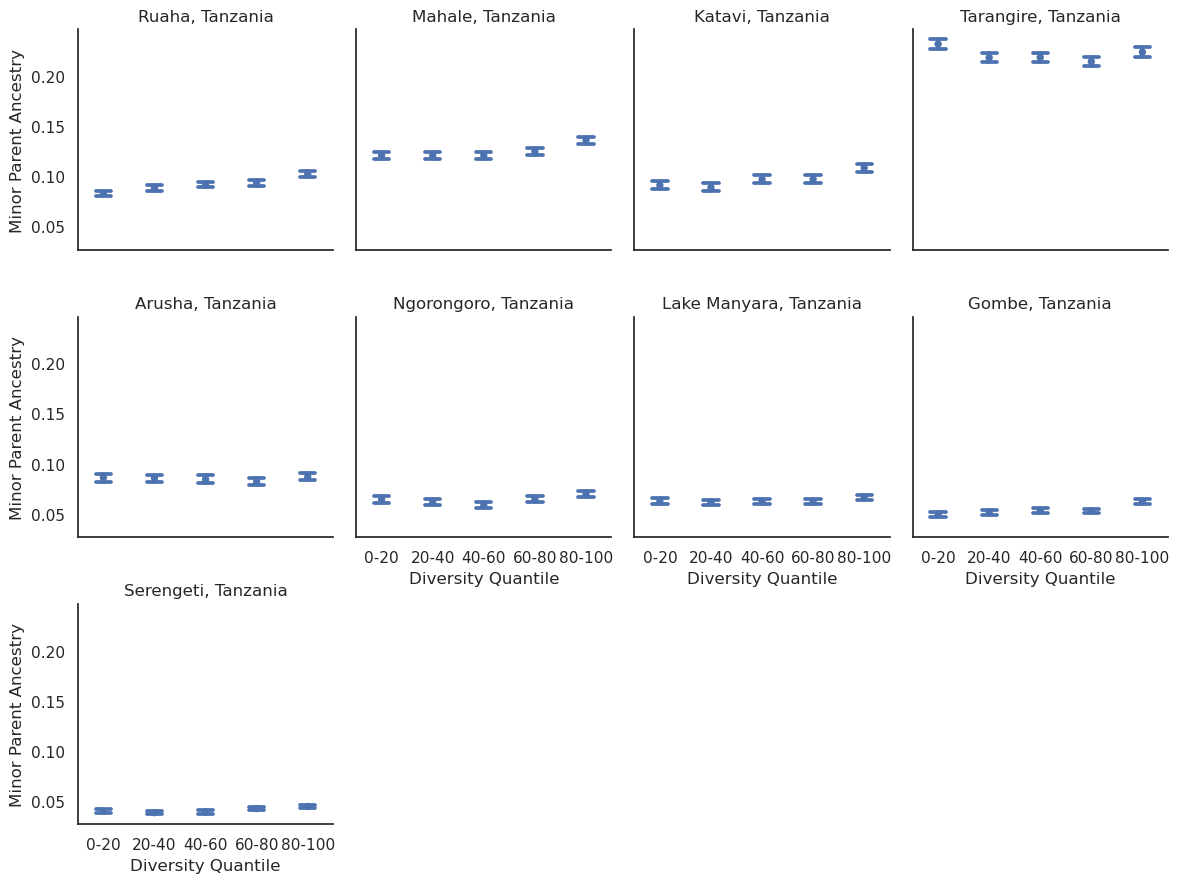

In [41]:
filter_qcut["Diversity Quantile"] = pd.qcut(filter_qcut.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
g = sns.FacetGrid(filter_qcut.loc[filter_qcut.Origin.isin(result_order_no_gog)], col="Origin",
                  col_wrap = 4, col_order=result_order_no_gog)
g.map_dataframe(sns.pointplot, y="minor_parent_percentage", x="Diversity Quantile", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
#g.set(xlim=(0, 0.25))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Diversity Quantile", ylabel="Minor Parent Ancestry")

In [221]:
o_l, low_l, high_l, effect_l, effect_hl_l = [], [], [], [], []
filter_qcut["Diversity Quantile"] = pd.qcut(filter_qcut.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
for o in result_order:
    s_df = filter_qcut.loc[filter_qcut.Origin == o]
    #print(o, s_df.groupby(["Diversity Quantile"])[["minor_parent_percentage"]].mean())
    low_mean = s_df.loc[s_df["Diversity Quantile"] == "0-20"][["minor_parent_percentage"]].mean()[0]*100
    high_mean = s_df.loc[s_df["Diversity Quantile"] == "80-100"][["minor_parent_percentage"]].mean()[0]*100
    o_l.append(o)
    low_l.append(low_mean)
    high_l.append(high_mean)
    effect_l.append(high_mean/low_mean-1)

In [222]:
mean_quantile_df = pd.DataFrame({"Origin": o_l, "0-20 Minor Parent Percentage": low_l, 
                        "80-100 Minor Parent Percentage": high_l, "Relative Increase": effect_l})
mean_quantile_df["Absolute Increase"] = mean_quantile_df["80-100 Minor Parent Percentage"]-mean_quantile_df["0-20 Minor Parent Percentage"]
mean_quantile_df

,Origin,0-20 Minor Parent Percentage,80-100 Minor Parent Percentage,Relative Increase,Absolute Increase
0,"Ruaha, Tanzania",8.27,10.2,0.237,1.96
1,"Mahale, Tanzania",12.1,13.6,0.126,1.52
2,"Katavi, Tanzania",9.11,10.8,0.191,1.74
3,"Tarangire, Tanzania",23.2,22.4,-0.035,-0.812
4,"Arusha, Tanzania",8.59,8.68,0.0109,0.0936
5,"Ngorongoro, Tanzania",6.42,6.94,0.0798,0.513
6,"Lake Manyara, Tanzania",6.24,6.6,0.0576,0.359
7,"Gombe, Tanzania",4.93,6.22,0.261,1.29
8,"Serengeti, Tanzania",3.94,4.43,0.124,0.489
9,"Gog Woreda, Ethiopia",7.21,12.8,0.775,5.59


In [44]:
o_l, low_l, high_l, effect_l, effect_hl_l = [], [], [], [], []
filter_qcut["Diversity Quantile"] = pd.qcut(filter_qcut.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
for o in result_order:
    s_df = filter_qcut.loc[filter_qcut.Origin == o]
    #print(o, s_df.groupby(["Diversity Quantile"])[["minor_parent_percentage"]].mean())
    low_mean = s_df.loc[s_df["Diversity Quantile"] == "0-20"][["minor_parent_percentage"]].mean()[0]*100
    high_mean = s_df.loc[s_df["Diversity Quantile"] == "80-100"][["minor_parent_percentage"]].mean()[0]*100
    o_l.append(o)
    low_l.append(low_mean)
    high_l.append(high_mean)
    effect_l.append(high_mean/low_mean-1)

/tmp/55160035/ipykernel_2576839/4242712310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut["Diversity Quantile"] = pd.qcut(filter_qcut.diversity, 5,


In [45]:
filter_qcut

,chrom,start,diversity,Origin,end_x,north_sum,Species,callable_frac,end_y,cM,...,genes,genic,North Percentage,logdiv,logrecomb,norm_diversity,norm_recomb,minor_parent_percentage,local_minor_ancestry,Diversity Quantile
2,chr1,0,0.00306,"Arusha, Tanzania",100000,9.98e+04,anubis,0.795,100000,0,...,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.998,-2.51,-5.44,1.69,2.91,0.0016,0.0016,80-100
9,chr1,0,0.00306,"Gog Woreda, Ethiopia",100000,9.86e+04,NaN,0.795,100000,0,...,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.986,-2.51,-5.44,1.69,2.91,0.986,0.0143,80-100
10,chr1,0,0.00306,"Gombe, Tanzania",100000,9.88e+04,anubis,0.795,100000,0,...,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.988,-2.51,-5.44,1.69,2.91,0.0123,0.0123,80-100
11,chr1,0,0.00306,"Issa Valley, Tanzania",100000,9.98e+04,cynocephalus,0.795,100000,0,...,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.998,-2.51,-5.44,1.69,2.91,0.998,0.0016,80-100
13,chr1,0,0.00306,"Katavi, Tanzania",100000,1.58e+04,cynocephalus,0.795,100000,0,...,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.158,-2.51,-5.44,1.69,2.91,0.158,0.158,80-100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
674538,chr9,125600000,0.0023,"Ruaha, Tanzania",125700000,2.21e+04,cynocephalus,0.869,125700000,115,...,"['SYCE1', 'SYCE1']",True,0.221,-2.64,-5.58,0.709,1.87,0.221,0.221,80-100
674539,chr9,125600000,0.0023,"Selous, Tanzania",125700000,0,cynocephalus,0.869,125700000,115,...,"['SYCE1', 'SYCE1']",True,0,-2.64,-5.58,0.709,1.87,0,0,80-100
674540,chr9,125600000,0.0023,"Serengeti, Tanzania",125700000,1e+05,anubis,0.869,125700000,115,...,"['SYCE1', 'SYCE1']",True,1,-2.64,-5.58,0.709,1.87,0,0,80-100
674541,chr9,125600000,0.0023,"Tarangire, Tanzania",125700000,6.62e+04,anubis,0.869,125700000,115,...,"['SYCE1', 'SYCE1']",True,0.662,-2.64,-5.58,0.709,1.87,0.338,0.338,80-100


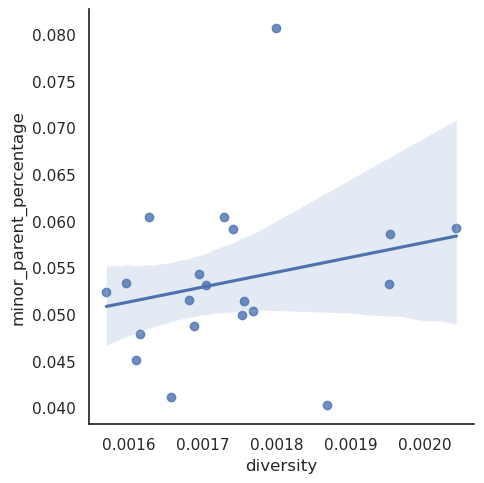

In [46]:
sns.lmplot(filter_qcut.loc[filter_qcut.Origin == "Gombe, Tanzania"].groupby(["chrom"])[["diversity", "minor_parent_percentage"]].mean(),
               x="diversity", y="minor_parent_percentage")

In [47]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_callable.loc[filter_callable.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity", data=o_div).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Ruaha, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25660
Model:                                 GLM   Df Residuals:                    25658
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                        0.010640
Method:                               IRLS   Log-Likelihood:                 21879.
Date:                     Fri, 14 Aug 2026   Deviance:                       273.01
Time:                             08:41:24   Pearson chi2:                     273.
No. Iterations:                          3   Pseudo R-squ. (CS):           0.004329
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

Lake Manyara, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25660
Model:                                 GLM   Df Residuals:                    25658
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                       0.0081468
Method:                               IRLS   Log-Likelihood:                 25305.
Date:                     Fri, 14 Aug 2026   Deviance:                       209.03
Time:                             08:41:25   Pearson chi2:                     209.
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001149
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

In [48]:
filter_callable.Origin.unique()

array(['Arusha, Tanzania', 'Gog Woreda, Ethiopia', 'Gombe, Tanzania',
       'Issa Valley, Tanzania', 'Katavi, Tanzania',
       'Lake Manyara, Tanzania', 'Mahale, Tanzania',
       'Ngorongoro, Tanzania', 'Ruaha, Tanzania', 'Selous, Tanzania',
       'Serengeti, Tanzania', 'Tarangire, Tanzania', 'Udzungwa, Tanzania'],
      dtype=object)

In [49]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Ruaha, Tanzania",0.0739,10.3,0,5.04e-26,0.0018,0.977
1,"Mahale, Tanzania",0.111,8.36,0,5.26e-13,0.00214,1.16
2,"Katavi, Tanzania",0.081,8.95,1.69e-221,9.07e-11,0.00255,1.38
3,"Tarangire, Tanzania",0.224,-1.5,0,0.35,0.00297,1.61
4,"Arusha, Tanzania",0.0798,3.13,3.45e-263,0.0122,0.0023,1.25
5,"Ngorongoro, Tanzania",0.0533,6.06,1.83e-166,7.92e-09,0.00194,1.05
6,"Lake Manyara, Tanzania",0.0548,4.65,7.36e-264,5.57e-08,0.00158,0.855
7,"Gombe, Tanzania",0.0376,9.33,1.9e-140,6.82e-31,0.00149,0.807
8,"Serengeti, Tanzania",0.0296,6.48,2.32e-137,6.51e-24,0.00119,0.643


In [50]:
filter_callable["diversity"].quantile([0.05, 0.95])

0.05      0.00082
0.95       0.0028
Name: diversity, dtype: float64

In [51]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_callable.loc[(filter_callable.Origin == o)]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity", data=o_div).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Ruaha, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25660
Model:                                 GLM   Df Residuals:                    25658
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                        0.010640
Method:                               IRLS   Log-Likelihood:                 21879.
Date:                     Fri, 14 Aug 2026   Deviance:                       273.01
Time:                             08:41:25   Pearson chi2:                     273.
No. Iterations:                          3   Pseudo R-squ. (CS):           0.004329
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

Lake Manyara, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25660
Model:                                 GLM   Df Residuals:                    25658
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                       0.0081468
Method:                               IRLS   Log-Likelihood:                 25305.
Date:                     Fri, 14 Aug 2026   Deviance:                       209.03
Time:                             08:41:25   Pearson chi2:                     209.
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001149
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

In [52]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Ruaha, Tanzania",0.0739,10.3,0,5.04e-26,0.0018,0.977
1,"Mahale, Tanzania",0.111,8.36,0,5.26e-13,0.00214,1.16
2,"Katavi, Tanzania",0.081,8.95,1.69e-221,9.07e-11,0.00255,1.38
3,"Tarangire, Tanzania",0.224,-1.5,0,0.35,0.00297,1.61
4,"Arusha, Tanzania",0.0798,3.13,3.45e-263,0.0122,0.0023,1.25
5,"Ngorongoro, Tanzania",0.0533,6.06,1.83e-166,7.92e-09,0.00194,1.05
6,"Lake Manyara, Tanzania",0.0548,4.65,7.36e-264,5.57e-08,0.00158,0.855
7,"Gombe, Tanzania",0.0376,9.33,1.9e-140,6.82e-31,0.00149,0.807
8,"Serengeti, Tanzania",0.0296,6.48,2.32e-137,6.51e-24,0.00119,0.643


In [53]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut.loc[filter_qcut.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Ruaha, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      1.8600e-05
Method:                               IRLS   Log-Likelihood:                 20619.
Date:                     Fri, 14 Aug 2026   Deviance:                      0.47253
Time:                             08:41:25   Pearson chi2:                    0.473
No. Iterations:                          3   Pseudo R-squ. (CS):           0.005159
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

Lake Manyara, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      1.3572e-05
Method:                               IRLS   Log-Likelihood:                 24623.
Date:                     Fri, 14 Aug 2026   Deviance:                      0.34477
Time:                             08:41:26   Pearson chi2:                    0.345
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0009909
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

In [54]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Ruaha, Tanzania",0.0705,12.3,1.31e-234,2.01e-30,0.00216,1.07
1,"Mahale, Tanzania",0.107,10.1,0,7.86e-16,0.00253,1.26
2,"Katavi, Tanzania",0.0759,11.8,8.91e-140,3.16e-15,0.00302,1.5
3,"Tarangire, Tanzania",0.218,1.6,0,0.36,0.0035,1.74
4,"Arusha, Tanzania",0.0817,1.68,1.14e-202,0.21,0.00269,1.34
5,"Ngorongoro, Tanzania",0.0515,6.8,1.52e-113,1.95e-09,0.00228,1.13
6,"Lake Manyara, Tanzania",0.0545,4.6,2.56e-192,5.2e-07,0.00184,0.917
7,"Gombe, Tanzania",0.0352,10.4,1.43e-87,3.42e-32,0.00178,0.885
8,"Serengeti, Tanzania",0.0314,5.23,3.27e-110,8.2e-14,0.00141,0.701


In [55]:
groups = filter_qcut.groupby("chrom")
aut_mean, chrom_mean = groups["diversity"].transform("mean"), filter_qcut["diversity"].mean()
filter_qcut["aut_norm_div"] = filter_qcut.diversity*chrom_mean/aut_mean

/tmp/55160035/ipykernel_2576839/3362829037.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut["aut_norm_div"] = filter_qcut.diversity*chrom_mean/aut_mean


<Axes: xlabel='diversity', ylabel='aut_norm_div'>

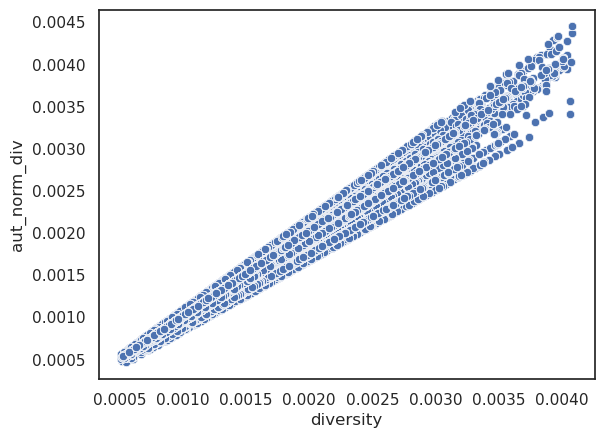

In [56]:
sns.scatterplot(filter_qcut, x="diversity", y="aut_norm_div")

In [215]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut.loc[filter_qcut.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ aut_norm_div", data=o_div,
                         var_weights=np.asarray(o_div["aut_norm_div"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Ruaha, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      1.8601e-05
Method:                               IRLS   Log-Likelihood:                 20642.
Date:                     Fri, 14 Aug 2026   Deviance:                      0.47255
Time:                             11:46:42   Pearson chi2:                    0.473
No. Iterations:                          3   Pseudo R-squ. (CS):           0.004748
Covariance Type:                 nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

Lake Manyara, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      1.3582e-05
Method:                               IRLS   Log-Likelihood:                 24636.
Date:                     Fri, 14 Aug 2026   Deviance:                      0.34505
Time:                             11:46:42   Pearson chi2:                    0.345
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001145
Covariance Type:                 nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

In [216]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Ruaha, Tanzania",0.0713,11.9,1.56e-237,3.97e-28,0.00217,1.08
1,"Mahale, Tanzania",0.107,9.88,0,6.54e-15,0.00254,1.27
2,"Katavi, Tanzania",0.0787,10.2,2.99e-149,1.61e-11,0.00302,1.51
3,"Tarangire, Tanzania",0.22,0.67,0,0.703,0.00352,1.76
4,"Arusha, Tanzania",0.0795,3,2.91e-190,0.0263,0.0027,1.35
5,"Ngorongoro, Tanzania",0.0531,5.92,1.51e-119,2.21e-07,0.00229,1.14
6,"Lake Manyara, Tanzania",0.0537,4.99,1.52e-185,6.84e-08,0.00185,0.924
7,"Gombe, Tanzania",0.0356,10.2,1.15e-88,2.27e-30,0.00178,0.891
8,"Serengeti, Tanzania",0.0304,5.78,7.42e-103,2.7e-16,0.00141,0.706
9,"Gog Woreda, Ethiopia",0.0326,32.5,2.63e-23,5.87e-88,0.00327,1.64


In [59]:
o_div = filter_qcut.loc[filter_qcut.Origin.isin(["Mikumi, Tanzania", "Ruaha, Tanzania"])]
glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity*Origin", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
print(glm_results.summary(), glm_results.pvalues)

                    Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      1.8600e-05
Method:                               IRLS   Log-Likelihood:                 20619.
Date:                     Fri, 14 Aug 2026   Deviance:                      0.47253
Time:                             08:41:27   Pearson chi2:                    0.473
No. Iterations:                          3   Pseudo R-squ. (CS):           0.005159
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
In

In [60]:
o_div = filter_qcut.loc[filter_qcut.Origin.isin(["Ngorongoro, Tanzania", "Tarangire, Tanzania"])]
glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity*Origin", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
print(glm_results.summary(), glm_results.pvalues)

                    Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                50812
Model:                                 GLM   Df Residuals:                    50808
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      3.4927e-05
Method:                               IRLS   Log-Likelihood:                 25231.
Date:                     Fri, 14 Aug 2026   Deviance:                       1.7746
Time:                             08:41:27   Pearson chi2:                     1.77
No. Iterations:                          3   Pseudo R-squ. (CS):             0.2593
Covariance Type:                 nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

In [61]:
from scipy.stats import norm

predictions = glm_results.get_prediction()
df_predictions = predictions.summary_frame()
df_predictions["diversity"] = o_div["diversity"]

[[<matplotlib.axis.XTick at 0x14f022143760>,

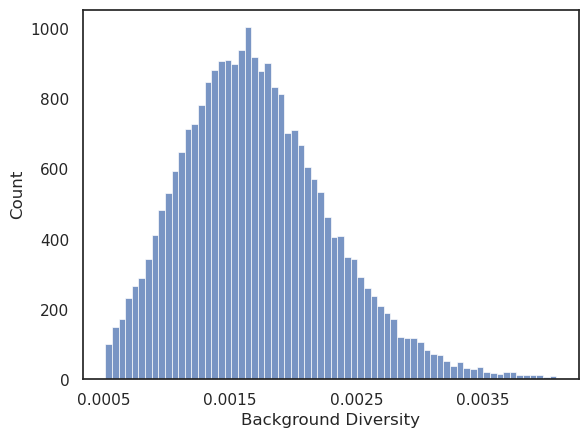

In [62]:
g = sns.histplot(filter_qcut.loc[filter_qcut.Origin.isin(gog)], x="diversity")
g.set(xlabel = "Background Diversity")
g.set(xticks=np.arange(0.0005, 0.004, 0.001))

[Text(0.5, 0, 'Background Diversity')]

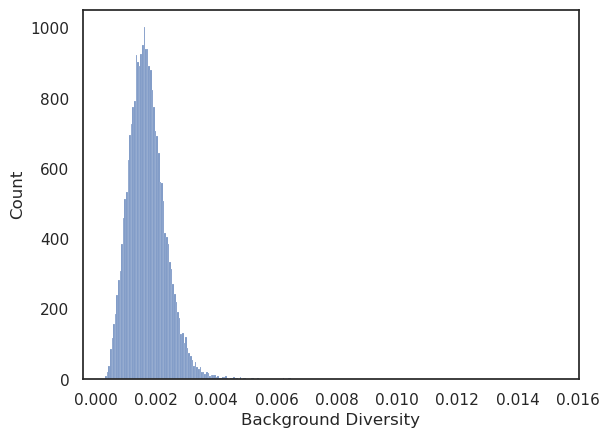

In [63]:
g = sns.histplot(filter_callable.loc[filter_callable.Origin.isin(gog)], x="diversity")
g.set(xlabel = "Background Diversity")
#g.set(xticks=np.arange(0.0005, 0.014, 0.001))

In [64]:
filter_qcut.loc[filter_qcut.Origin.isin(gog)]["diversity"].mean(), filter_qcut.loc[filter_qcut.Origin.isin(gog)]["diversity"].median()

(0.001711774744977684, 0.001658228842197082)

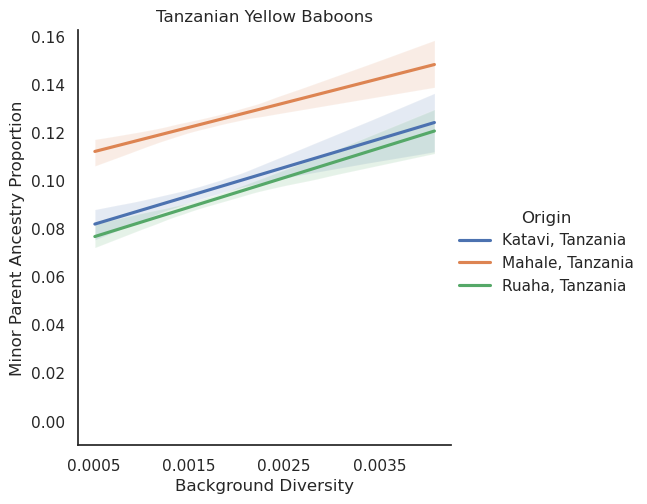

In [65]:
g = lmplot(filter_qcut.loc[filter_qcut.Origin.isin(yellows)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Yellow Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=np.arange(0.0005, 0.004, 0.001))

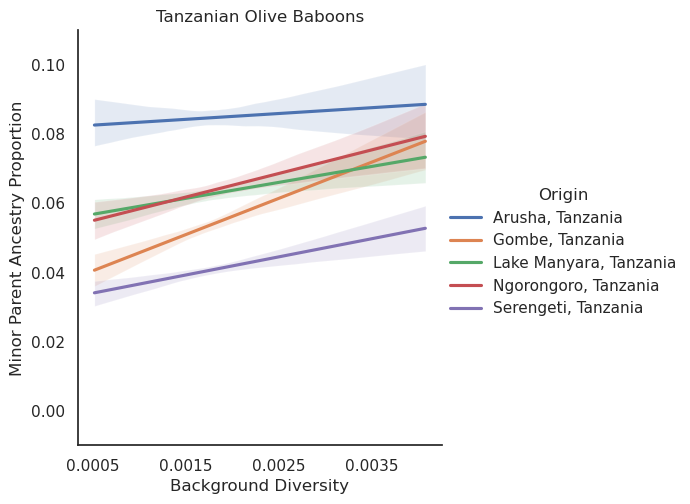

In [66]:
g = lmplot(filter_qcut.loc[filter_qcut.Origin.isin(olives)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Olive Baboons")
g.set(ylim=(-0.01, 0.11))
g.set(xticks=np.arange(0.0005, 0.004, 0.001))

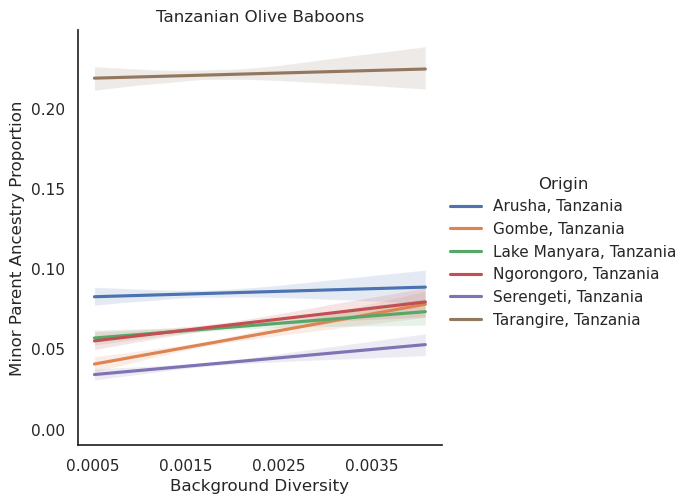

In [67]:
g = lmplot(filter_qcut.loc[filter_qcut.Origin.isin(olives_with_tarangire)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Olive Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=np.arange(0.0005, 0.004, 0.001))

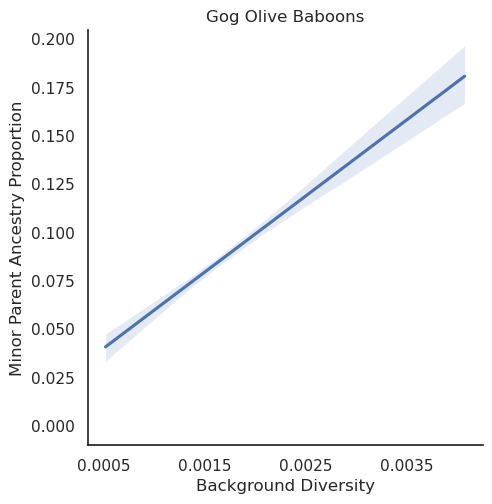

In [68]:
g = lmplot(filter_qcut.loc[filter_qcut.Origin.isin(gog)], x="diversity", y="minor_parent_percentage",
                            scatter=False, weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Gog Olive Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=np.arange(0.0005, 0.004, 0.001))

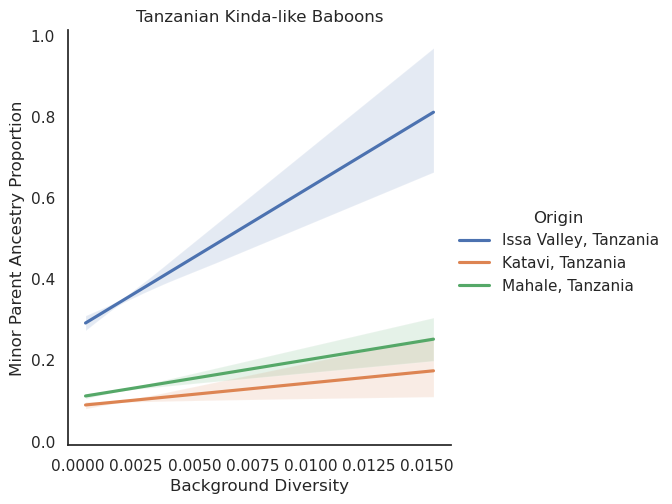

In [69]:
g = lmplot(filter_callable.loc[filter_callable.Origin.isin(["Mahale, Tanzania",
                                                           "Katavi, Tanzania",
                                                           "Issa Valley, Tanzania"])], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Kinda-like Baboons")
g.set(ylim=(-0.01, None))

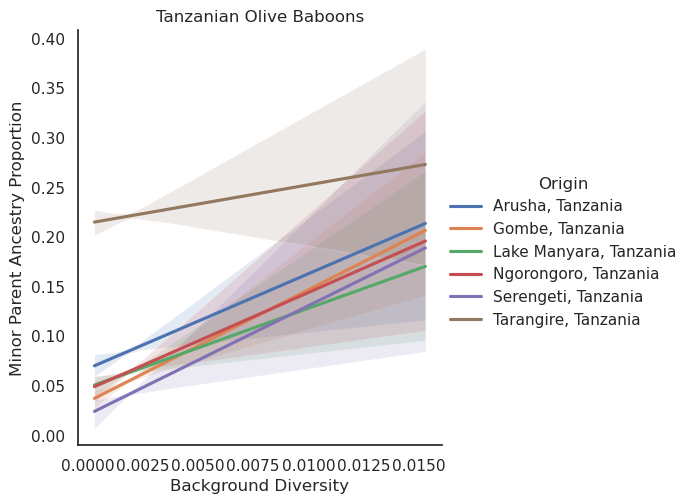

In [70]:
g = lmplot(filter_callable.loc[filter_callable.Origin.isin(olives_with_tarangire)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Olive Baboons")
g.set(ylim=(-0.01, None))

In [71]:
o_l, stat_l, pval_l = [], [], []
for o in result_order:
    o_div = filter_qcut.loc[filter_qcut.Origin == o]
    #o_div = o_div.loc[(o_div.minor_parent_percentage < 0.5)]
    st, pval = stats.pearsonr(o_div.diversity, o_div["minor_parent_percentage"])
    print(o, stats.pearsonr(o_div.diversity, o_div["minor_parent_percentage"]))
    o_l.append(o), stat_l.append(st), pval_l.append(pval)
pd.DataFrame({"Origin": o_l, "Statistic": stat_l, "P-Value": pval_l})

Ruaha, Tanzania PearsonRResult(statistic=0.06708200090642125, pvalue=9.757635732594574e-27)
Mahale, Tanzania PearsonRResult(statistic=0.043095509887781235, pvalue=6.332584705405791e-12)
Katavi, Tanzania PearsonRResult(statistic=0.04234500082114992, pvalue=1.4564405504670103e-11)
Tarangire, Tanzania PearsonRResult(statistic=-0.011679623426993782, pvalue=0.06265703830650615)
Arusha, Tanzania PearsonRResult(statistic=-0.00039385463671910833, pvalue=0.9499461299424741)
Ngorongoro, Tanzania PearsonRResult(statistic=0.023816704648322883, pvalue=0.0001467189867052877)
Lake Manyara, Tanzania PearsonRResult(statistic=0.017519256156361053, pvalue=0.005229977817138457)
Gombe, Tanzania PearsonRResult(statistic=0.05694117916313174, pvalue=1.0569520089739728e-19)
Serengeti, Tanzania PearsonRResult(statistic=0.03439781725733274, pvalue=4.155551120783743e-08)


,Origin,Statistic,P-Value
0,"Ruaha, Tanzania",0.0671,9.76e-27
1,"Mahale, Tanzania",0.0431,6.33e-12
2,"Katavi, Tanzania",0.0423,1.46e-11
3,"Tarangire, Tanzania",-0.0117,0.0627
4,"Arusha, Tanzania",-0.000394,0.95
5,"Ngorongoro, Tanzania",0.0238,0.000147
6,"Lake Manyara, Tanzania",0.0175,0.00523
7,"Gombe, Tanzania",0.0569,1.06e-19
8,"Serengeti, Tanzania",0.0344,4.16e-08


Recomb investigation for autosomes

In [72]:
filter_callable = admix_div_mean.loc[admix_div_mean.callable_frac > 0.75]
filter_callable.loc[filter_callable['Origin'] == 'Gog Woreda, Gambella region, Ethiopia_eth_case', ['Origin']] = 'Gog Woreda, Ethiopia'
filter_callable["average_cM_window"].quantile([0.005, 0.995])

0.005     1.13e-07
0.995     4.08e-06
Name: average_cM_window, dtype: float64

In [73]:
len(filter_callable)

333580

In [74]:
len(filter_callable)/len(admix_div_mean)

0.9890152245133937

In [75]:
filter_qcut_recomb = filter_callable.loc[(filter_callable.average_cM_window >= 1.13e-07) &
                                 (filter_callable.average_cM_window <=  4.08e-06)]
filter_callable["window_cM"] = filter_callable["average_cM_window"]*100000
filter_qcut_recomb["window_cM"] = filter_qcut_recomb["average_cM_window"]*100000

/tmp/55160035/ipykernel_2576839/436718125.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_callable["window_cM"] = filter_callable["average_cM_window"]*100000
/tmp/55160035/ipykernel_2576839/436718125.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_recomb["window_cM"] = filter_qcut_recomb["average_cM_window"]*100000


In [184]:
filter_qcut_recomb.window_cM.mean(), filter_qcut_recomb.window_cM.median()

(0.08150930258188299, 0.06682910775519701)

In [76]:
import statsmodels.api as sm
import numpy as np

df_l = []
for o in result_order:
    o_div = filter_qcut_recomb.loc[filter_qcut_recomb.Origin == o]
    Y = o_div["minor_parent_percentage"]
    X = o_div.window_cM
    X = sm.add_constant(X)
    model = sm.OLS(Y,X)
    results = model.fit()
    print(o)
    #print(results.t_test([1, 0]))
    het_test = sm.stats.het_breuschpagan(resid=results.resid, exog_het=X)
    print(het_test)
    #print(sm.stats.diagnostic.linear_harvey_collier(results))
    df_l.append(list(het_test))
bp_df = pd.DataFrame(df_l, columns=["Lagrange Multiplier", "Lagrange Multiplier P-value", "F-statistic", "F-statistic P-value"])
bp_df["Origin"] = result_order
bp_df

Ruaha, Tanzania
(1.9807440057531225, 0.15931204925783599, 1.9807425040746283, 0.15932444465190737)
Mahale, Tanzania
(3.625757132058377, 0.05689168017602352, 3.625989226937664, 0.05689503352950392)
Katavi, Tanzania
(3.921032427630041, 0.047685586904480354, 3.9213290141165493, 0.047687948967927156)
Tarangire, Tanzania
(0.19882862635531195, 0.6556680109707509, 0.19881452741351738, 0.6556832323476001)
Arusha, Tanzania
(5.784027979478595, 0.01617243837163061, 5.7848898317156845, 0.016171616761110705)
Ngorongoro, Tanzania
(0.007538892206699677, 0.9308091892844308, 0.0075383008549922805, 0.9308125806194144)
Lake Manyara, Tanzania
(5.904846571088737, 0.015099280820679654, 5.905754522790543, 0.015098378941467667)
Gombe, Tanzania
(1.1230631304690892, 0.28925983753635276, 1.1230243564444182, 0.28927823994525464)
Serengeti, Tanzania
(27.959435675433983, 1.2388538574119665e-07, 27.98804128027202, 1.2307841620235849e-07)


,Lagrange Multiplier,Lagrange Multiplier P-value,F-statistic,F-statistic P-value,Origin
0,1.98,0.159,1.98,0.159,"Ruaha, Tanzania"
1,3.63,0.0569,3.63,0.0569,"Mahale, Tanzania"
2,3.92,0.0477,3.92,0.0477,"Katavi, Tanzania"
3,0.199,0.656,0.199,0.656,"Tarangire, Tanzania"
4,5.78,0.0162,5.78,0.0162,"Arusha, Tanzania"
5,0.00754,0.931,0.00754,0.931,"Ngorongoro, Tanzania"
6,5.9,0.0151,5.91,0.0151,"Lake Manyara, Tanzania"
7,1.12,0.289,1.12,0.289,"Gombe, Tanzania"
8,28,1.24e-07,28,1.23e-07,"Serengeti, Tanzania"


/tmp/55160035/ipykernel_2576839/3329632309.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_recomb["Recombination Quantile"] = pd.qcut(filter_qcut_recomb.window_cM, 5,


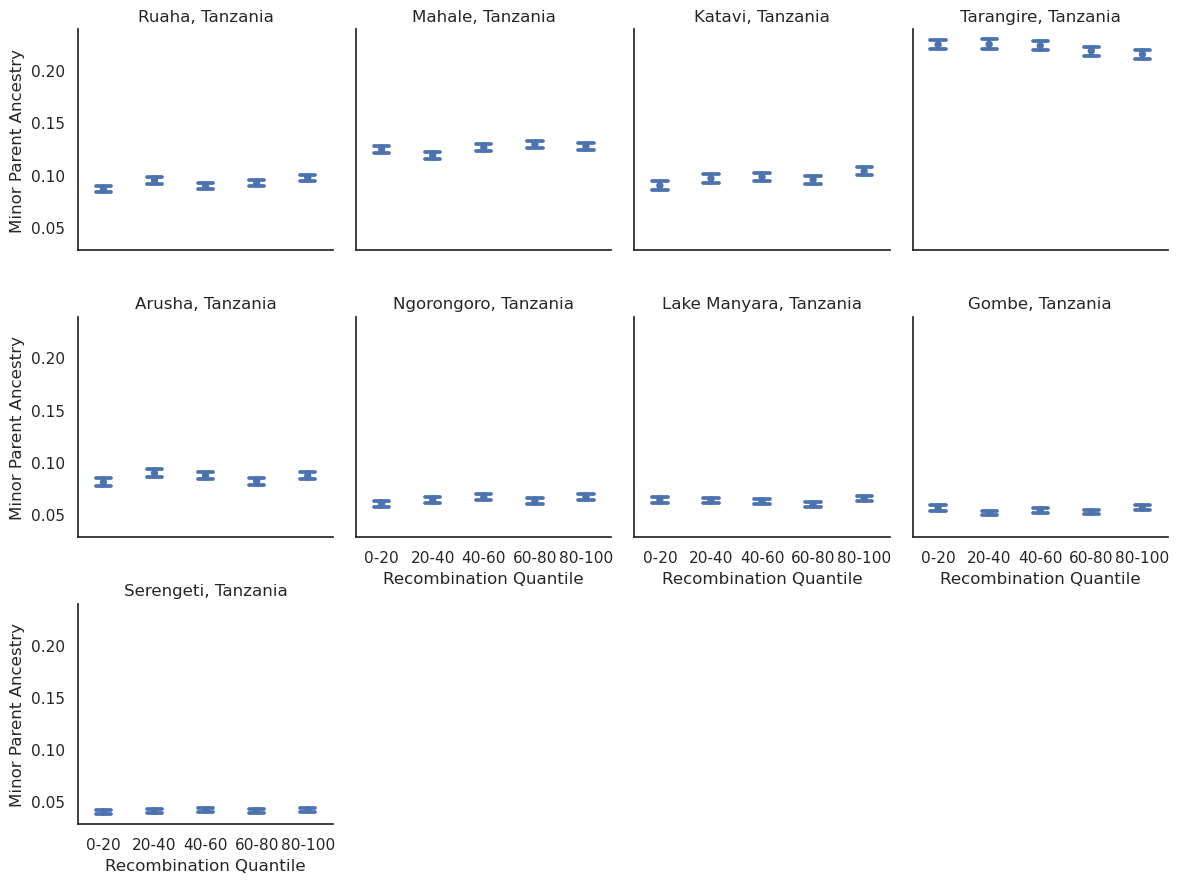

In [77]:
filter_qcut_recomb["Recombination Quantile"] = pd.qcut(filter_qcut_recomb.window_cM, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
g = sns.FacetGrid(filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(result_order_no_gog)], col="Origin",
                  col_wrap = 4, col_order=result_order_no_gog)
g.map_dataframe(sns.pointplot, y="minor_parent_percentage", x="Recombination Quantile", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
#g.set(xlim=(0, 0.25))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Recombination Quantile", ylabel="Minor Parent Ancestry")

In [78]:
o_l, low_l, high_l, effect_l, effect_hl_l = [], [], [], [], []
filter_qcut_recomb["Recombination Quantile"] = pd.qcut(filter_qcut_recomb.window_cM, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
for o in result_order:
    s_df = filter_qcut_recomb.loc[filter_qcut_recomb.Origin == o]
    #print(o, s_df.groupby(["Recombination Quantile"])[["minor_parent_percentage"]].mean())
    low_mean = s_df.loc[s_df["Recombination Quantile"] == "0-20"][["minor_parent_percentage"]].mean()[0]*100
    high_mean = s_df.loc[s_df["Recombination Quantile"] == "80-100"][["minor_parent_percentage"]].mean()[0]*100
    o_l.append(o)
    low_l.append(low_mean)
    high_l.append(high_mean)
    effect_l.append(high_mean/low_mean-1)

/tmp/55160035/ipykernel_2576839/3586050451.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_recomb["Recombination Quantile"] = pd.qcut(filter_qcut_recomb.window_cM, 5,


In [79]:
mean_quantile_df = pd.DataFrame({"Origin": o_l, "0-20 Minor Parent Percentage": low_l, 
                        "80-100 Minor Parent Percentage": high_l, "Relative Increase": effect_l})
mean_quantile_df["Absolute Increase"] = mean_quantile_df["80-100 Minor Parent Percentage"]-mean_quantile_df["0-20 Minor Parent Percentage"]
mean_quantile_df

,Origin,0-20 Minor Parent Percentage,80-100 Minor Parent Percentage,Relative Increase,Absolute Increase
0,"Ruaha, Tanzania",8.65,9.69,0.12,1.04
1,"Mahale, Tanzania",12.4,12.7,0.0236,0.293
2,"Katavi, Tanzania",8.94,10.3,0.156,1.39
3,"Tarangire, Tanzania",22.5,21.5,-0.0414,-0.93
4,"Arusha, Tanzania",8.03,8.66,0.0775,0.622
5,"Ngorongoro, Tanzania",5.97,6.63,0.11,0.657
6,"Lake Manyara, Tanzania",6.39,6.48,0.0145,0.0926
7,"Gombe, Tanzania",5.57,5.58,0.00102,0.00566
8,"Serengeti, Tanzania",3.93,4.16,0.0611,0.24


In [80]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_callable.loc[filter_callable.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ window_cM", data=o_div,
                         var_weights=np.asarray(o_div["window_cM"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Ruaha, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25660
Model:                                 GLM   Df Residuals:                    25658
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      0.00089101
Method:                               IRLS   Log-Likelihood:                 19282.
Date:                     Fri, 14 Aug 2026   Deviance:                       22.862
Time:                             08:47:06   Pearson chi2:                     22.9
No. Iterations:                          3   Pseudo R-squ. (CS):           0.004851
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

Lake Manyara, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25660
Model:                                 GLM   Df Residuals:                    25658
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      0.00066169
Method:                               IRLS   Log-Likelihood:                 23100.
Date:                     Fri, 14 Aug 2026   Deviance:                       16.978
Time:                             08:47:07   Pearson chi2:                     17.0
No. Iterations:                          3   Pseudo R-squ. (CS):           0.002551
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

In [81]:
glm_recomb_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_recomb_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Ruaha, Tanzania",0.0861,0.0611,0,5.65e-29,0.00097,0.00547
1,"Mahale, Tanzania",0.122,0.0336,0,1.75e-07,0.00114,0.00644
2,"Katavi, Tanzania",0.0938,0.0362,0,2.24e-06,0.00136,0.00765
3,"Tarangire, Tanzania",0.217,0.0268,0,0.00282,0.00159,0.00897
4,"Arusha, Tanzania",0.0808,0.0445,0,1.17e-10,0.00122,0.0069
5,"Ngorongoro, Tanzania",0.0569,0.0715,0,1.66e-33,0.00105,0.00593
6,"Lake Manyara, Tanzania",0.059,0.0381,0,5.66e-16,0.000836,0.00471
7,"Gombe, Tanzania",0.0491,0.0467,0,3.44e-24,0.000817,0.00461
8,"Serengeti, Tanzania",0.039,0.0219,0,8.27e-09,0.000673,0.0038


In [213]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut_recomb.loc[filter_qcut_recomb.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ window_cM", data=o_div,
                         var_weights=np.asarray(o_div["window_cM"])
                         ).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Ruaha, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25401
Model:                                 GLM   Df Residuals:                    25399
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      0.00085847
Method:                               IRLS   Log-Likelihood:                 19564.
Date:                     Fri, 14 Aug 2026   Deviance:                       21.804
Time:                             11:46:07   Pearson chi2:                     21.8
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0008472
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

Lake Manyara, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25401
Model:                                 GLM   Df Residuals:                    25399
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      0.00063338
Method:                               IRLS   Log-Likelihood:                 23426.
Date:                     Fri, 14 Aug 2026   Deviance:                       16.087
Time:                             11:46:07   Pearson chi2:                     16.1
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001101
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

In [214]:
glm_recomb_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_recomb_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Ruaha, Tanzania",0.0887,0.0406,0,3.48e-06,0.00121,0.00875
1,"Mahale, Tanzania",0.124,0.0118,0,0.252,0.00142,0.0103
2,"Katavi, Tanzania",0.0946,0.0313,0,0.011,0.0017,0.0123
3,"Tarangire, Tanzania",0.221,-0.00948,0,0.511,0.00199,0.0144
4,"Arusha, Tanzania",0.08,0.0497,0,6.66e-06,0.00152,0.011
5,"Ngorongoro, Tanzania",0.0586,0.0573,0,1.2e-09,0.0013,0.00942
6,"Lake Manyara, Tanzania",0.0586,0.0397,0,1.22e-07,0.00104,0.00751
7,"Gombe, Tanzania",0.0484,0.0517,0,1.6e-12,0.00101,0.00731
8,"Serengeti, Tanzania",0.0366,0.0429,0,6.65e-13,0.000824,0.00597
9,"Gog Woreda, Ethiopia",0.0679,0.249,1.04e-274,7.92e-72,0.00192,0.0139


In [84]:
groups = filter_qcut_recomb.groupby("chrom")
aut_mean, chrom_mean = groups["window_cM"].transform("mean"), filter_qcut_recomb["window_cM"].mean()
filter_qcut_recomb["aut_recomb_div"] = filter_qcut_recomb.window_cM*chrom_mean/aut_mean

/tmp/55160035/ipykernel_2576839/2691077268.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_recomb["aut_recomb_div"] = filter_qcut_recomb.window_cM*chrom_mean/aut_mean


In [85]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut_recomb.loc[filter_qcut_recomb.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ aut_recomb_div", data=o_div,
                         var_weights=np.asarray(o_div["aut_recomb_div"])
                         ).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Ruaha, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25401
Model:                                 GLM   Df Residuals:                    25399
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      0.00086023
Method:                               IRLS   Log-Likelihood:                 19684.
Date:                     Fri, 14 Aug 2026   Deviance:                       21.849
Time:                             08:47:07   Pearson chi2:                     21.8
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0005058
Covariance Type:                 nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

Lake Manyara, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25401
Model:                                 GLM   Df Residuals:                    25399
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      0.00063703
Method:                               IRLS   Log-Likelihood:                 23499.
Date:                     Fri, 14 Aug 2026   Deviance:                       16.180
Time:                             08:47:07   Pearson chi2:                     16.2
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001150
Covariance Type:                 nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [86]:
glm_recomb_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_recomb_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Ruaha, Tanzania",0.0894,0.0324,0,0.000337,0.00122,0.00904
1,"Mahale, Tanzania",0.123,0.0238,0,0.0255,0.00143,0.0107
2,"Katavi, Tanzania",0.0957,0.0223,0,0.08,0.00171,0.0127
3,"Tarangire, Tanzania",0.218,0.0128,0,0.391,0.002,0.0149
4,"Arusha, Tanzania",0.0794,0.0613,0,8.24e-08,0.00154,0.0114
5,"Ngorongoro, Tanzania",0.0599,0.0428,0,1.05e-05,0.00131,0.00971
6,"Lake Manyara, Tanzania",0.0585,0.0421,0,6.43e-08,0.00105,0.00778
7,"Gombe, Tanzania",0.0484,0.0528,0,3.62e-12,0.00102,0.00759
8,"Serengeti, Tanzania",0.0356,0.0532,0,7.81e-18,0.000833,0.00619


In [87]:
filter_callable.loc[filter_callable['Origin'] == 'Gog Woreda, Gambella region, Ethiopia_eth_case', ['Origin']] = 'Gog Woreda, Ethiopia'
filter_callable["average_cM_window"].quantile([0.000, 0.99])

   0     7.12e-09
0.99     3.25e-06
Name: average_cM_window, dtype: float64

[Text(0.5, 0, 'Recombination across window (cM)')]

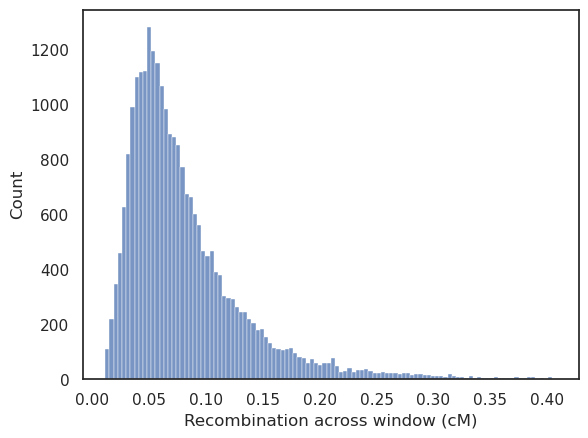

In [88]:
g = sns.histplot(filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(gog)], x="window_cM")
g.set(xlabel="Recombination across window (cM)")

In [89]:
filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(gog)]["window_cM"].mean(), filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(gog)]["window_cM"].median()

(0.08150930258188299, 0.06682910775519701)

[Text(0.5, 0, 'Recombination across window (cM)')]

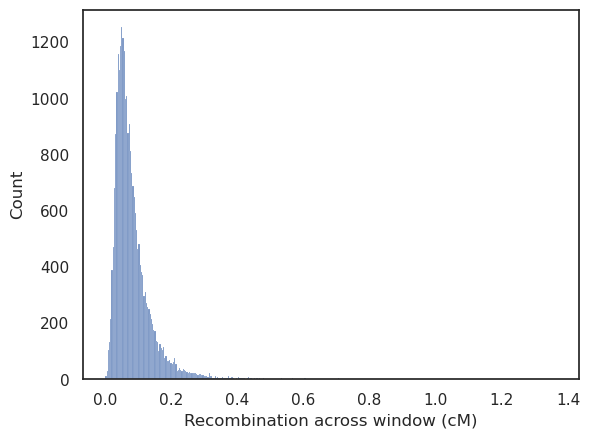

In [90]:
g = sns.histplot(filter_callable.loc[filter_callable.Origin.isin(gog)], x="window_cM")
g.set(xlabel="Recombination across window (cM)")

In [91]:
filter_callable.loc[filter_callable.Origin.isin(gog)]["window_cM"].mean(), filter_callable.loc[filter_callable.Origin.isin(gog)]["window_cM"].median()

(0.0835180564270441, 0.06682918646315805)

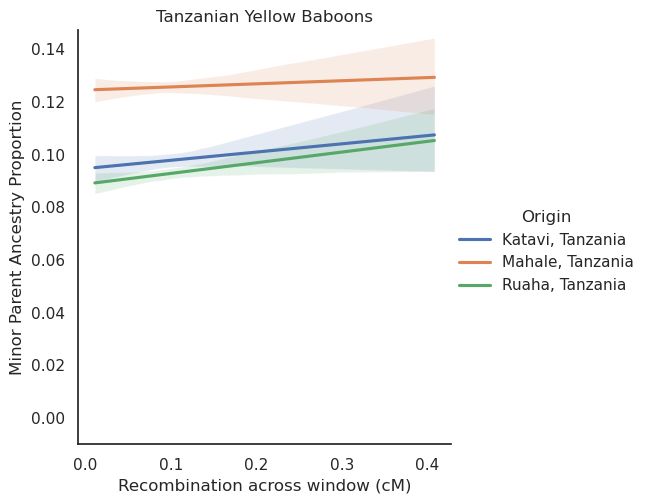

In [92]:
g = lmplot(filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(yellows)], x="window_cM", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5)
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Recombination across window (cM)", title="Tanzanian Yellow Baboons")
g.set(ylim=(-0.01, None))

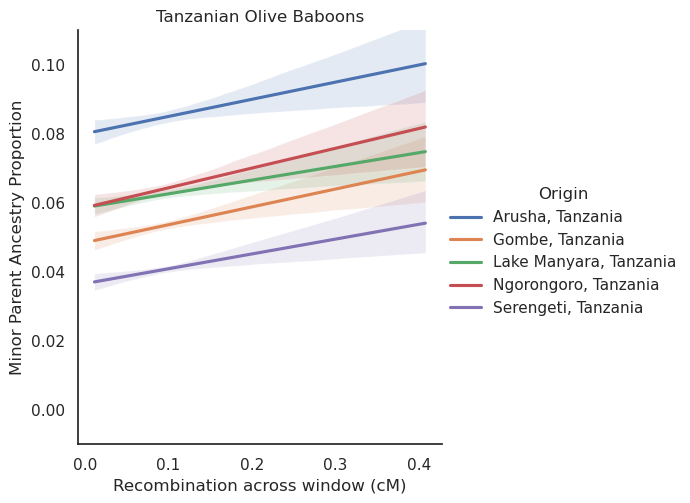

In [93]:
g = lmplot(filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(olives)], x="window_cM", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=95)
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Recombination across window (cM)", title="Tanzanian Olive Baboons")
g.set(ylim=(-0.01, 0.11))

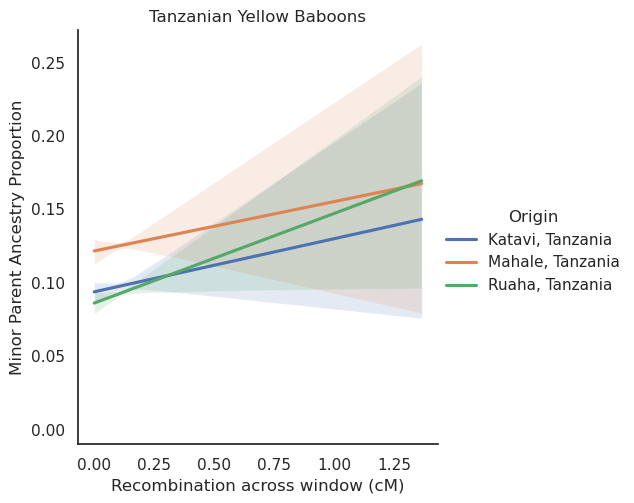

In [94]:
g = lmplot(filter_callable.loc[filter_callable.Origin.isin(yellows)], x="window_cM", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5)
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Recombination across window (cM)", title="Tanzanian Yellow Baboons")
g.set(ylim=(-0.01, None))

[Text(0.5, 0, 'Recombination across window (cM)'),
 Text(0, 0.5, 'Background Diversity')]

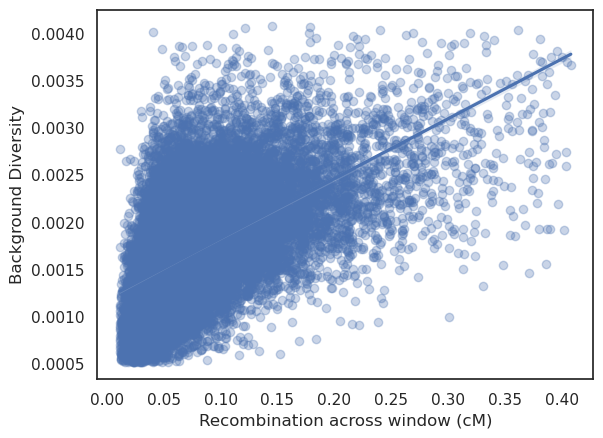

In [95]:
norm_filter = filter_qcut_recomb.loc[(filter_qcut_recomb.diversity >= 0.000513) &
                                 (filter_qcut_recomb.diversity <= 0.00408)]
g = sns.regplot(norm_filter.loc[(norm_filter.Origin == "Serengeti, Tanzania") &
                              #(admix_div_mean["minor_parent_percentage"] < 0.5) &
                              (norm_filter.callable_frac > 0.75)], x="window_cM", y="diversity",
                            ci=95, scatter_kws={'alpha':0.3})
g.set(xlabel="Recombination across window (cM)", ylabel = "Background Diversity")

In [96]:
stats.pearsonr(norm_filter.window_cM, norm_filter.diversity)

PearsonRResult(statistic=0.5730825286503434, pvalue=0.0)

In [97]:
norm_filter

,chrom,start,diversity,Origin,end_x,north_sum,Species,callable_frac,end_y,cM,...,North Percentage,logdiv,logrecomb,norm_diversity,norm_recomb,minor_parent_percentage,local_minor_ancestry,window_cM,Recombination Quantile,aut_recomb_div
2,chr1,0,0.00306,"Arusha, Tanzania",100000,9.98e+04,anubis,0.795,100000,0,...,0.998,-2.51,-5.44,1.69,2.91,0.0016,0.0016,0.36,80-100,0.4
9,chr1,0,0.00306,"Gog Woreda, Ethiopia",100000,9.86e+04,NaN,0.795,100000,0,...,0.986,-2.51,-5.44,1.69,2.91,0.986,0.0143,0.36,80-100,0.4
10,chr1,0,0.00306,"Gombe, Tanzania",100000,9.88e+04,anubis,0.795,100000,0,...,0.988,-2.51,-5.44,1.69,2.91,0.0123,0.0123,0.36,80-100,0.4
11,chr1,0,0.00306,"Issa Valley, Tanzania",100000,9.98e+04,cynocephalus,0.795,100000,0,...,0.998,-2.51,-5.44,1.69,2.91,0.998,0.0016,0.36,80-100,0.4
13,chr1,0,0.00306,"Katavi, Tanzania",100000,1.58e+04,cynocephalus,0.795,100000,0,...,0.158,-2.51,-5.44,1.69,2.91,0.158,0.158,0.36,80-100,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
674538,chr9,125600000,0.0023,"Ruaha, Tanzania",125700000,2.21e+04,cynocephalus,0.869,125700000,115,...,0.221,-2.64,-5.58,0.709,1.87,0.221,0.221,0.263,80-100,0.261
674539,chr9,125600000,0.0023,"Selous, Tanzania",125700000,0,cynocephalus,0.869,125700000,115,...,0,-2.64,-5.58,0.709,1.87,0,0,0.263,80-100,0.261
674540,chr9,125600000,0.0023,"Serengeti, Tanzania",125700000,1e+05,anubis,0.869,125700000,115,...,1,-2.64,-5.58,0.709,1.87,0,0,0.263,80-100,0.261
674541,chr9,125600000,0.0023,"Tarangire, Tanzania",125700000,6.62e+04,anubis,0.869,125700000,115,...,0.662,-2.64,-5.58,0.709,1.87,0.338,0.338,0.263,80-100,0.261


In [98]:
norm_filter["norm_diversity"] = (norm_filter.diversity-norm_filter.diversity.mean())/(norm_filter.diversity.std())
norm_filter["norm_recomb"] = (norm_filter.window_cM-norm_filter.window_cM.mean())/(norm_filter.window_cM.std())

/tmp/55160035/ipykernel_2576839/1414838712.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  norm_filter["norm_diversity"] = (norm_filter.diversity-norm_filter.diversity.mean())/(norm_filter.diversity.std())
/tmp/55160035/ipykernel_2576839/1414838712.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  norm_filter["norm_recomb"] = (norm_filter.window_cM-norm_filter.window_cM.mean())/(norm_filter.window_cM.std())


In [99]:
o_l, cd_l, cr_l, nd_l, rd_l = [], [], [], [], []
for o in result_order:
    o_div = norm_filter.loc[norm_filter.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ norm_diversity", data=o_div
                         ).fit()
    print(o, glm_results.summary2(), glm_results.pvalues, glm_results.f_test(np.identity(len(glm_results.params))[1:,:]))
    #o_l.append(o), cd_l.append(glm_results.params[1]), cr_l.append(glm_results.params[2])
    #nd_l.append(glm_results.pvalues[1]), rd_l.append(glm_results.pvalues[2])

Ruaha, Tanzania                    Results: Generalized linear model
Model:              GLM                     AIC:            -42995.7543 
Link Function:      Identity                BIC:            -255159.3236
Dependent Variable: minor_parent_percentage Log-Likelihood: 21500.      
Date:               2026-08-14 08:49        LL-Null:        21445.      
No. Observations:   25205                   Deviance:       267.98      
Df Model:           1                       Pearson chi2:   268.        
Df Residuals:       25203                   Scale:          0.010633    
Method:             IRLS                                                
--------------------------------------------------------------------------
                   Coef.    Std.Err.      z       P>|z|    [0.025   0.975]
--------------------------------------------------------------------------
Intercept          0.0917     0.0006   141.1215   0.0000   0.0904   0.0929
norm_diversity     0.0068     0.0006    10.4856

In [223]:
o_l, cd_l, cr_l, nd_l, rd_l = [], [], [], [], []
for o in result_order:
    o_div = norm_filter.loc[norm_filter.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ norm_diversity + norm_recomb",
                          data=o_div
                         ).fit()
    print(o, glm_results.summary2(), glm_results.pvalues)
    o_l.append(o), cd_l.append(glm_results.params[1]), cr_l.append(glm_results.params[2])
    nd_l.append(glm_results.pvalues[1]), rd_l.append(glm_results.pvalues[2])

Ruaha, Tanzania                    Results: Generalized linear model
Model:              GLM                     AIC:            -42998.5797 
Link Function:      Identity                BIC:            -255149.2401
Dependent Variable: minor_parent_percentage Log-Likelihood: 21502.      
Date:               2026-08-14 14:08        LL-Null:        21445.      
No. Observations:   25205                   Deviance:       267.93      
Df Model:           2                       Pearson chi2:   268.        
Df Residuals:       25202                   Scale:          0.010631    
Method:             IRLS                                                
-------------------------------------------------------------------------
                     Coef.   Std.Err.     z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------------
Intercept            0.0917    0.0006  141.1322  0.0000   0.0904   0.0929
norm_diversity       0.0078    0.0008    9.8524  0.

In [224]:
pd.DataFrame({"Origin": o_l, "Recombination Slope": cr_l, "Diversity Slope": cd_l,
              "Recombination p-val": rd_l, "Diversity p-val": nd_l})

,Origin,Recombination Slope,Diversity Slope,Recombination p-val,Diversity p-val
0,"Ruaha, Tanzania",-0.00174,0.00781,0.028,6.69e-23
1,"Mahale, Tanzania",-0.00281,0.00703,0.00268,6.06e-14
2,"Katavi, Tanzania",-0.00148,0.00703,0.186,3.36e-10
3,"Tarangire, Tanzania",-0.00218,-0.000693,0.0946,0.594
4,"Arusha, Tanzania",0.00141,-0.000661,0.161,0.512
5,"Ngorongoro, Tanzania",0.000907,0.00201,0.285,0.0181
6,"Lake Manyara, Tanzania",-0.000707,0.00202,0.304,0.0034
7,"Gombe, Tanzania",-0.00298,0.00638,4.6e-06,9.32e-23
8,"Serengeti, Tanzania",-0.00139,0.00321,0.00675,4.11e-10
9,"Gog Woreda, Ethiopia",0.000762,0.0198,0.515,1.72e-64


In [102]:
o_l, cd_l, cr_l, nd_l, rd_l, i_l, id_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = norm_filter.loc[norm_filter.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ norm_diversity * norm_recomb", data=o_div
                         ).fit()
    print(o, glm_results.summary2(), glm_results.pvalues)
    o_l.append(o), cd_l.append(glm_results.params[1]), cr_l.append(glm_results.params[2])
    nd_l.append(glm_results.pvalues[1]), rd_l.append(glm_results.pvalues[2])
    i_l.append(glm_results.params[3]), id_l.append(glm_results.pvalues[3])

Ruaha, Tanzania                      Results: Generalized linear model
Model:               GLM                      AIC:             -43000.5745 
Link Function:       Identity                 BIC:             -255139.1478
Dependent Variable:  minor_parent_percentage  Log-Likelihood:  21504.      
Date:                2026-08-14 08:49         LL-Null:         21445.      
No. Observations:    25205                    Deviance:        267.89      
Df Model:            3                        Pearson chi2:    268.        
Df Residuals:        25201                    Scale:           0.010630    
Method:              IRLS                                                  
---------------------------------------------------------------------------
                            Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
---------------------------------------------------------------------------
Intercept                   0.0910   0.0007 126.7350 0.0000  0.0896  0.0925
norm_diversity   

Lake Manyara, Tanzania                     Results: Generalized linear model
Model:                GLM                     AIC:            -50133.4766 
Link Function:        Identity                BIC:            -255205.1760
Dependent Variable:   minor_parent_percentage Log-Likelihood: 25071.      
Date:                 2026-08-14 08:49        LL-Null:        25062.      
No. Observations:     25205                   Deviance:       201.86      
Df Model:             3                       Pearson chi2:   202.        
Df Residuals:         25201                   Scale:          0.0080100   
Method:               IRLS                                                
--------------------------------------------------------------------------
                            Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
--------------------------------------------------------------------------
Intercept                   0.0617   0.0006 98.9636 0.0000  0.0605  0.0629
norm_diversity         

In [103]:
pd.DataFrame({"Origin": o_l, "Recombination Slope": cr_l, "Diversity Slope": cd_l, "Interaction Slope": i_l,
              "Recombination p-val": rd_l, "Diversity p-val": nd_l, "Interaction p-val": id_l})

,Origin,Recombination Slope,Diversity Slope,Interaction Slope,Recombination p-val,Diversity p-val,Interaction p-val
0,"Ruaha, Tanzania",-0.00266,0.00791,0.00107,0.00369,2.29e-23,0.0456
1,"Mahale, Tanzania",-0.0033,0.00709,0.000567,0.00232,4.41e-14,0.371
2,"Katavi, Tanzania",-0.00158,0.00704,0.000112,0.223,3.44e-10,0.882
3,"Tarangire, Tanzania",-0.00523,-0.00036,0.00356,0.000513,0.782,5.37e-05
4,"Arusha, Tanzania",0.000754,-0.000589,0.000765,0.517,0.56,0.261
5,"Ngorongoro, Tanzania",0.00022,0.00208,0.000801,0.823,0.0144,0.163
6,"Lake Manyara, Tanzania",-0.00187,0.00214,0.00135,0.0188,0.00188,0.00361
7,"Gombe, Tanzania",-0.00413,0.00651,0.00134,3.92e-08,1.62e-23,0.00229
8,"Serengeti, Tanzania",-0.00193,0.00327,0.000631,0.00113,2.12e-10,0.0691


In [104]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = norm_filter.loc[norm_filter.Origin == o]
    glm_results = smf.ols(formula = "minor_parent_percentage ~ norm_diversity", data=o_div
                         ).fit()
    print(o, glm_results.summary2())

Ruaha, Tanzania                       Results: Ordinary least squares
Model:              OLS                     Adj. R-squared:     0.004      
Dependent Variable: minor_parent_percentage AIC:                -42995.7543
Date:               2026-08-14 08:49        BIC:                -42979.4847
No. Observations:   25205                   Log-Likelihood:     21500.     
Df Model:           1                       F-statistic:        109.9      
Df Residuals:       25203                   Prob (F-statistic): 1.14e-25   
R-squared:          0.004                   Scale:              0.010633   
------------------------------------------------------------------------------
                  Coef.     Std.Err.       t        P>|t|     [0.025    0.975]
------------------------------------------------------------------------------
Intercept         0.0917      0.0006    141.1215    0.0000    0.0904    0.0929
norm_diversity    0.0068      0.0006     10.4856    0.0000    0.0055    0.0081
---

Lake Manyara, Tanzania                       Results: Ordinary least squares
Model:              OLS                     Adj. R-squared:     0.000      
Dependent Variable: minor_parent_percentage AIC:                -50127.9505
Date:               2026-08-14 08:49        BIC:                -50111.6809
No. Observations:   25205                   Log-Likelihood:     25066.     
Df Model:           1                       F-statistic:        8.158      
Df Residuals:       25203                   Prob (F-statistic): 0.00429    
R-squared:          0.000                   Scale:              0.0080124  
------------------------------------------------------------------------------
                  Coef.     Std.Err.       t        P>|t|     [0.025    0.975]
------------------------------------------------------------------------------
Intercept         0.0625      0.0006    110.8343    0.0000    0.0614    0.0636
norm_diversity    0.0016      0.0006      2.8562    0.0043    0.0005    0.0

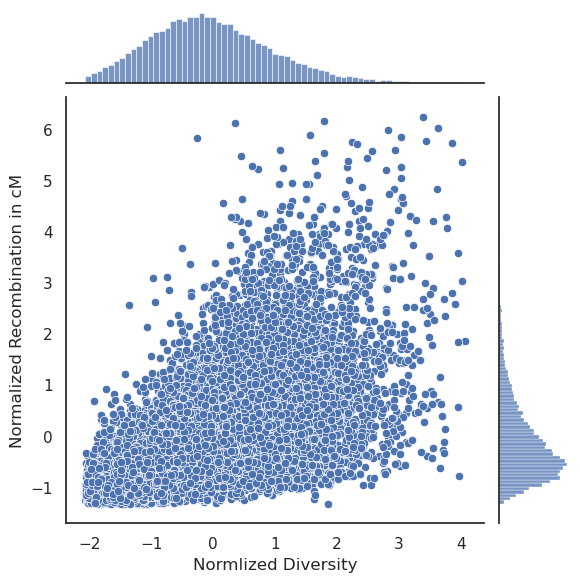

In [105]:
g = sns.jointplot(norm_filter.loc[(norm_filter.Origin == "Serengeti, Tanzania") &
                              #(admix_div_mean["minor_parent_percentage"] < 0.5) &
                              (norm_filter.callable_frac > 0.9)], x="norm_diversity", y="norm_recomb")
g.set_axis_labels(xlabel="Normlized Diversity", ylabel="Normalized Recombination in cM")

In [106]:
ser_div = admix_div_mean.loc[admix_div_mean.Origin == "Serengeti, Tanzania"].reset_index()
ser_div["tarangire_diff"] = (admix_div_mean.loc[admix_div_mean.Origin == "Serengeti, Tanzania"].minor_parent_percentage.reset_index()-admix_div_mean.loc[admix_div_mean.Origin == "Tarangire, Tanzania"].minor_parent_percentage.reset_index()).minor_parent_percentage
ser_div = ser_div.loc[(ser_div.callable_frac > 0.9)]
glm_results = smf.glm(formula = "tarangire_diff ~ diversity", data=ser_div,
                         var_weights=np.asarray(ser_div.diversity)
                         ).fit()
print(glm_results.summary(), glm_results.pvalues[1])

                 Generalized Linear Model Regression Results                  
Dep. Variable:         tarangire_diff   No. Observations:                22963
Model:                            GLM   Df Residuals:                    22961
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                      5.0175e-05
Method:                          IRLS   Log-Likelihood:                 7042.9
Date:                Fri, 14 Aug 2026   Deviance:                       1.1521
Time:                        08:49:53   Pearson chi2:                     1.15
No. Iterations:                     3   Pseudo R-squ. (CS):          0.0006055
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1920      0.003    -58.436      0.0

In [107]:
yellow_pops = filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(["Mahale, Tanzania", "Ruaha, Tanzania"])]
glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity*Origin", data=yellow_pops,
                         var_weights=np.asarray(yellow_pops.diversity)
                         ).fit()
print(glm_results.summary(), glm_results.pvalues[0], glm_results.pvalues[3])

                    Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                50802
Model:                                 GLM   Df Residuals:                    50798
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      2.2201e-05
Method:                               IRLS   Log-Likelihood:                 36717.
Date:                     Fri, 14 Aug 2026   Deviance:                       1.1278
Time:                             08:49:53   Pearson chi2:                     1.13
No. Iterations:                          3   Pseudo R-squ. (CS):            0.02496
Covariance Type:                 nonrobust                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

ChrX case

In [108]:
chrX_mean = mean_window_df_tanz_eth.loc[mean_window_df_tanz_eth.chrom == "all_chrX"]
chrX_mean["chrom"] = "chrX"
admix_div_chrX_all = mean_diversity.merge(chrX_mean, on=["chrom", "start"])
admix_div_chrX_all["North Percentage"] = admix_div_chrX_all.north_sum/100000
admix_div_chrX_all = admix_div_chrX_all.merge(c_r_g_df, on=["chrom", "start"])
admix_div_chrX_all["Species"] = admix_div_chrX_all.Origin.map(dict(zip(meta_data_samples_sci.Origin, meta_data_samples_sci.Species)))


/tmp/55160035/ipykernel_2576839/4154381476.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chrX_mean["chrom"] = "chrX"


In [109]:
#Selecting the cases of interest and setting Minor Parent Ancestry

admix_div_chrX_all = admix_div_chrX_all.loc[admix_div_chrX_all.Origin.isin(origins_interest)]
admix_div_chrX_all["minor_parent_percentage"] = [x if y == ("cynocephalus") or z == "Gog Woreda, Gambella region, Ethiopia_eth_case"
                                             else 1-x for x, y, z in zip(admix_div_chrX_all["North Percentage"],
                                                                         admix_div_chrX_all["Species"],
                                                                        admix_div_chrX_all["Origin"])]
admix_div_chrX_all["local_minor_ancestry"] = [min(x, 1-x) for x in admix_div_chrX_all["North Percentage"]]
filter_callable_chrX = admix_div_chrX_all.loc[admix_div_chrX_all.callable_frac > 0.9]
filter_callable_chrX.loc[filter_callable_chrX['Origin'] == 'Gog Woreda, Gambella region, Ethiopia_eth_case', ['Origin']] = 'Gog Woreda, Ethiopia'
filter_callable_chrX["diversity"].quantile([0.005, 0.995])

0.005     0.000147
0.995      0.00156
Name: diversity, dtype: float64

Plot of difference in frequencies across the autosome and ChrX.

In [110]:
filter_callable_all = pd.concat([filter_callable_chrX, filter_callable])
filter_callable_all["chrom_type"] = ["autosome" if x != "chrX" else "chrX" for x in filter_callable_all.chrom]

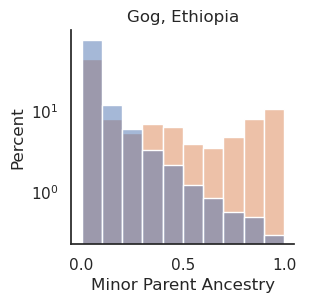

In [111]:
g = sns.FacetGrid(filter_callable_all.loc[filter_callable_all.Origin.isin(["Gog Woreda, Ethiopia"])])
g.map_dataframe(sns.histplot, x="minor_parent_percentage", hue="chrom_type", hue_order=["autosome", "chrX"],
                 common_norm = False, bins=10, stat="percent") 
g.add_legend()
g.set(yscale="log", title="Gog, Ethiopia")
#g.set_titles(col_template="{col_name}")
g.set(xlabel="Minor Parent Ancestry")

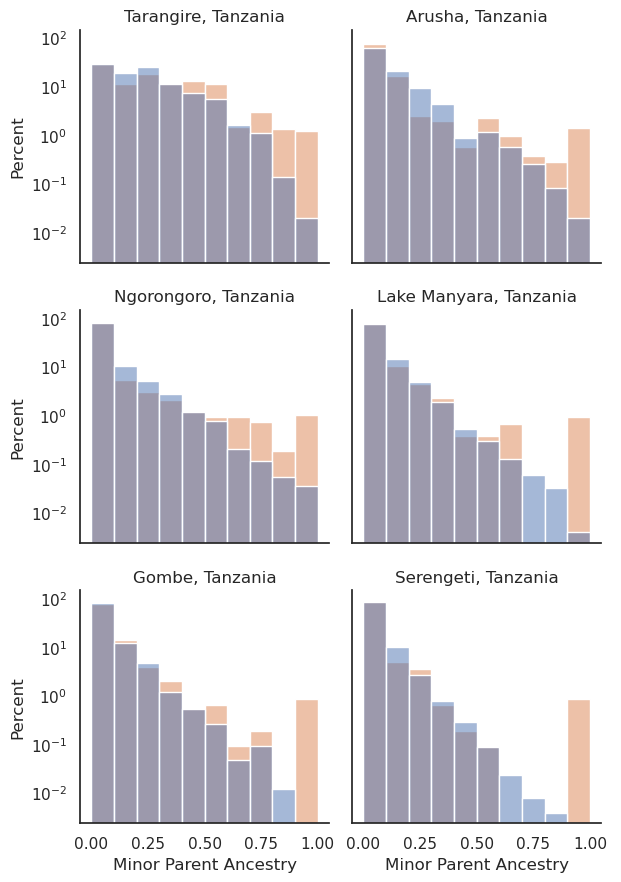

In [186]:
g = sns.FacetGrid(filter_callable_all.loc[filter_callable_all.Origin.isin(focus_pops6)], col="Origin",
                  col_wrap = 2, col_order=focus_pops6,legend_out=True)
g.map_dataframe(sns.histplot, x="minor_parent_percentage", hue="chrom_type", hue_order=["autosome", "chrX"],
                 common_norm = False, bins=10, stat="percent") 
g.add_legend()
g.set(yscale="log")
g.set_titles(col_template="{col_name}")
g.set(xlabel="Minor Parent Ancestry")


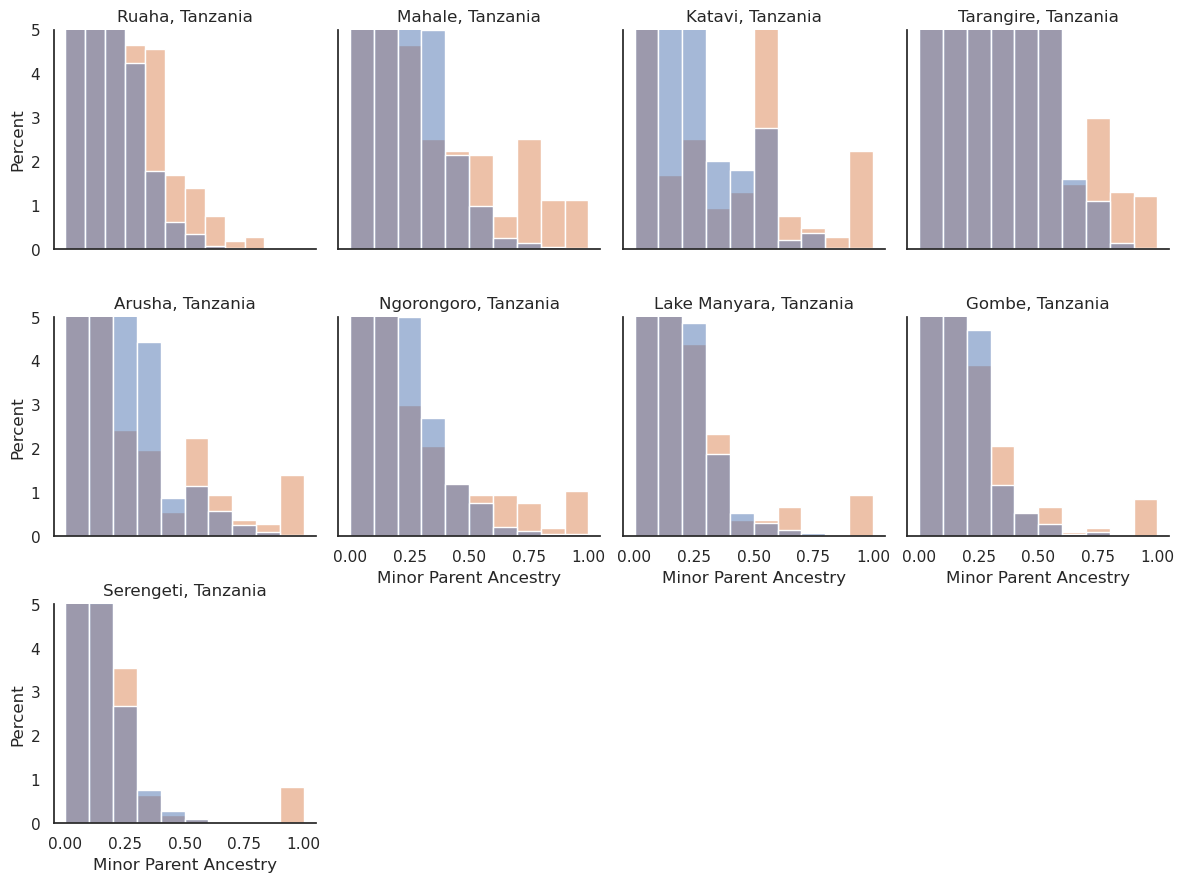

In [113]:
g = sns.FacetGrid(filter_callable_all.loc[filter_callable_all.Origin.isin(result_order_no_gog)], col="Origin",
                  col_wrap = 4, col_order=result_order_no_gog,legend_out=True)
g.map_dataframe(sns.histplot, x="minor_parent_percentage", hue="chrom_type", hue_order=["autosome", "chrX"],
                 common_norm = False, bins=10, stat="percent") 
g.add_legend()
g.set(ylim=(0, 5))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Minor Parent Ancestry")

In [114]:
result_order_no_gog_tarangire = ['Selous, Tanzania', 'Udzungwa, Tanzania', 'Mahale, Tanzania', 'Katavi, Tanzania', 'Ruaha, Tanzania',
      'Arusha, Tanzania', 'Ngorongoro, Tanzania', 'Gombe, Tanzania', 
             'Lake Manyara, Tanzania', 'Serengeti, Tanzania']

In [115]:
filter_callable_all

,chrom,start,diversity,Origin,end_x,north_sum,North Percentage,callable_frac,end_y,cM,...,genic,Species,minor_parent_percentage,local_minor_ancestry,logdiv,logrecomb,norm_diversity,norm_recomb,window_cM,chrom_type
52,chrX,200000,0.000826,"Arusha, Tanzania",300000,0,0,0.96,300000,1.32,...,True,anubis,1,0,NaN,NaN,NaN,NaN,NaN,chrX
59,chrX,200000,0.000826,"Gog Woreda, Ethiopia",300000,0,0,0.96,300000,1.32,...,True,NaN,0,0,NaN,NaN,NaN,NaN,NaN,chrX
60,chrX,200000,0.000826,"Gombe, Tanzania",300000,0,0,0.96,300000,1.32,...,True,anubis,1,0,NaN,NaN,NaN,NaN,NaN,chrX
61,chrX,200000,0.000826,"Issa Valley, Tanzania",300000,0,0,0.96,300000,1.32,...,True,cynocephalus,0,0,NaN,NaN,NaN,NaN,NaN,chrX
63,chrX,200000,0.000826,"Katavi, Tanzania",300000,0,0,0.96,300000,1.32,...,True,cynocephalus,0,0,NaN,NaN,NaN,NaN,NaN,chrX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
674538,chr9,125600000,0.0023,"Ruaha, Tanzania",125700000,2.21e+04,0.221,0.869,125700000,115,...,True,cynocephalus,0.221,0.221,-2.64,-5.58,0.709,1.87,0.263,autosome
674539,chr9,125600000,0.0023,"Selous, Tanzania",125700000,0,0,0.869,125700000,115,...,True,cynocephalus,0,0,-2.64,-5.58,0.709,1.87,0.263,autosome
674540,chr9,125600000,0.0023,"Serengeti, Tanzania",125700000,1e+05,1,0.869,125700000,115,...,True,anubis,0,0,-2.64,-5.58,0.709,1.87,0.263,autosome
674541,chr9,125600000,0.0023,"Tarangire, Tanzania",125700000,6.62e+04,0.662,0.869,125700000,115,...,True,anubis,0.338,0.338,-2.64,-5.58,0.709,1.87,0.263,autosome


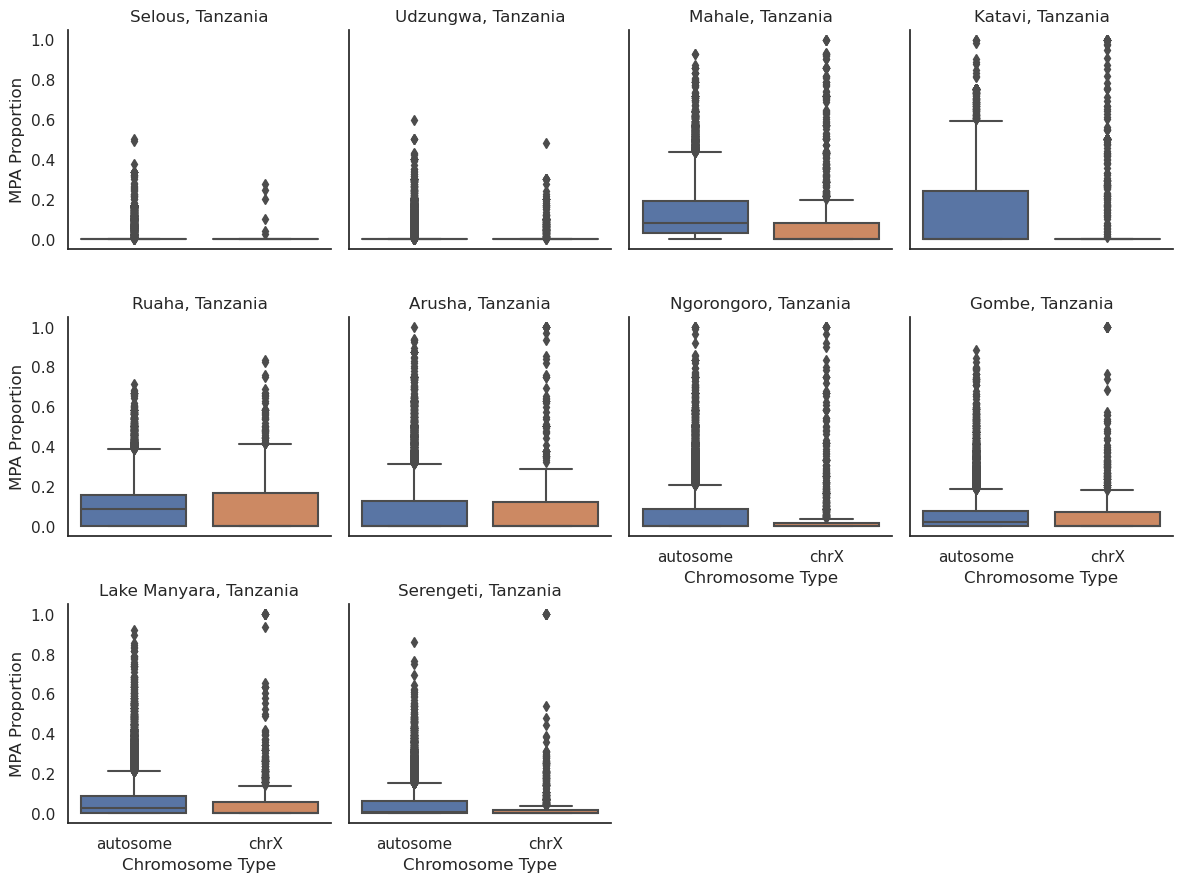

In [116]:
g = sns.FacetGrid(filter_callable_all.loc[filter_callable_all.Origin.isin(result_order_no_gog_tarangire)].sort_values(by=["chrom"]), col="Origin",
                  col_wrap = 4, col_order=result_order_no_gog_tarangire)
g.map_dataframe(sns.boxplot, y="minor_parent_percentage", x="chrom_type", palette=sns.color_palette()) 
g.set_titles(col_template="{col_name}")
g.set(xlabel="Chromosome Type", ylabel="MPA Proportion")

In [117]:
filter_callable_all.loc[filter_callable_all.Origin.isin(gog)].chrom.unique()

array(['chrX', 'chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14',
       'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20',
       'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9'],
      dtype=object)

In [118]:
filter_qcut_chrX = filter_callable_chrX.loc[(filter_callable_chrX.diversity >= 0.000147) & 
                                           (filter_callable_chrX.diversity <= 0.00156)]

In [119]:
filter_qcut.loc[filter_qcut.Origin.isin(gog)].diversity.mean(), filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)].diversity.mean()

(0.001711774744977684, 0.0006392304305855299)

In [120]:
filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)].diversity.mean()/filter_qcut.loc[filter_qcut.Origin.isin(gog)].diversity.mean()

0.373431394791295

In [121]:
from scipy.stats import mannwhitneyu
res = mannwhitneyu(filter_qcut.loc[filter_qcut.Origin.isin(gog)].diversity*0.75,
                   filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)].diversity, alternative="greater")
print(res)

MannwhitneyuResult(statistic=24092456.0, pvalue=0.0)


In [122]:
import statsmodels.api as sm
df_l = []
for o in result_order:
    o_div = filter_qcut_chrX.loc[filter_qcut_chrX.Origin == o]
    Y = o_div["minor_parent_percentage"]
    X = o_div.diversity
    X = sm.add_constant(X)
    model = sm.OLS(Y,X)
    results = model.fit()
    print(o)
    #print(results.t_test([1, 0]))
    het_test = sm.stats.het_breuschpagan(resid=results.resid, exog_het=X)
    print(het_test)
    #print(sm.stats.diagnostic.linear_harvey_collier(results))
    df_l.append(list(het_test))
bp_df = pd.DataFrame(df_l, columns=["Lagrange Multiplier", "Lagrange Multiplier P-value", "F-statistic", "F-statistic P-value"])
bp_df["Origin"] = result_order
bp_df

Ruaha, Tanzania
(32.18427702643666, 1.4022090788745727e-08, 33.126694872818696, 1.1293894150270818e-08)
Mahale, Tanzania
(15.196226313335039, 9.689686352959519e-05, 15.387610279088374, 9.318943701194653e-05)
Katavi, Tanzania
(4.699139645593617, 0.03017772027895282, 4.7111245495020375, 0.03018926655101869)
Tarangire, Tanzania
(1.8332302569435022, 0.17574647966687446, 1.8329421520502978, 0.176068734839343)
Arusha, Tanzania
(0.8409529660607431, 0.35912436423755845, 0.840035303076326, 0.35959494694379956)
Ngorongoro, Tanzania
(3.1392372781656492, 0.07642954152746731, 3.142611623417493, 0.0765584658472794)
Lake Manyara, Tanzania
(3.4030534699442, 0.06507585034340037, 3.4075595852129297, 0.0651767829253232)
Gombe, Tanzania
(4.761009401749722, 0.029111470861197482, 4.773431162653331, 0.029120386096948576)
Serengeti, Tanzania
(10.075819772671672, 0.0015022776894871419, 10.153100270236484, 0.0014826356661312796)


,Lagrange Multiplier,Lagrange Multiplier P-value,F-statistic,F-statistic P-value,Origin
0,32.2,1.4e-08,33.1,1.13e-08,"Ruaha, Tanzania"
1,15.2,9.69e-05,15.4,9.32e-05,"Mahale, Tanzania"
2,4.7,0.0302,4.71,0.0302,"Katavi, Tanzania"
3,1.83,0.176,1.83,0.176,"Tarangire, Tanzania"
4,0.841,0.359,0.84,0.36,"Arusha, Tanzania"
5,3.14,0.0764,3.14,0.0766,"Ngorongoro, Tanzania"
6,3.4,0.0651,3.41,0.0652,"Lake Manyara, Tanzania"
7,4.76,0.0291,4.77,0.0291,"Gombe, Tanzania"
8,10.1,0.0015,10.2,0.00148,"Serengeti, Tanzania"


/tmp/55160035/ipykernel_2576839/515002999.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["Diversity Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,


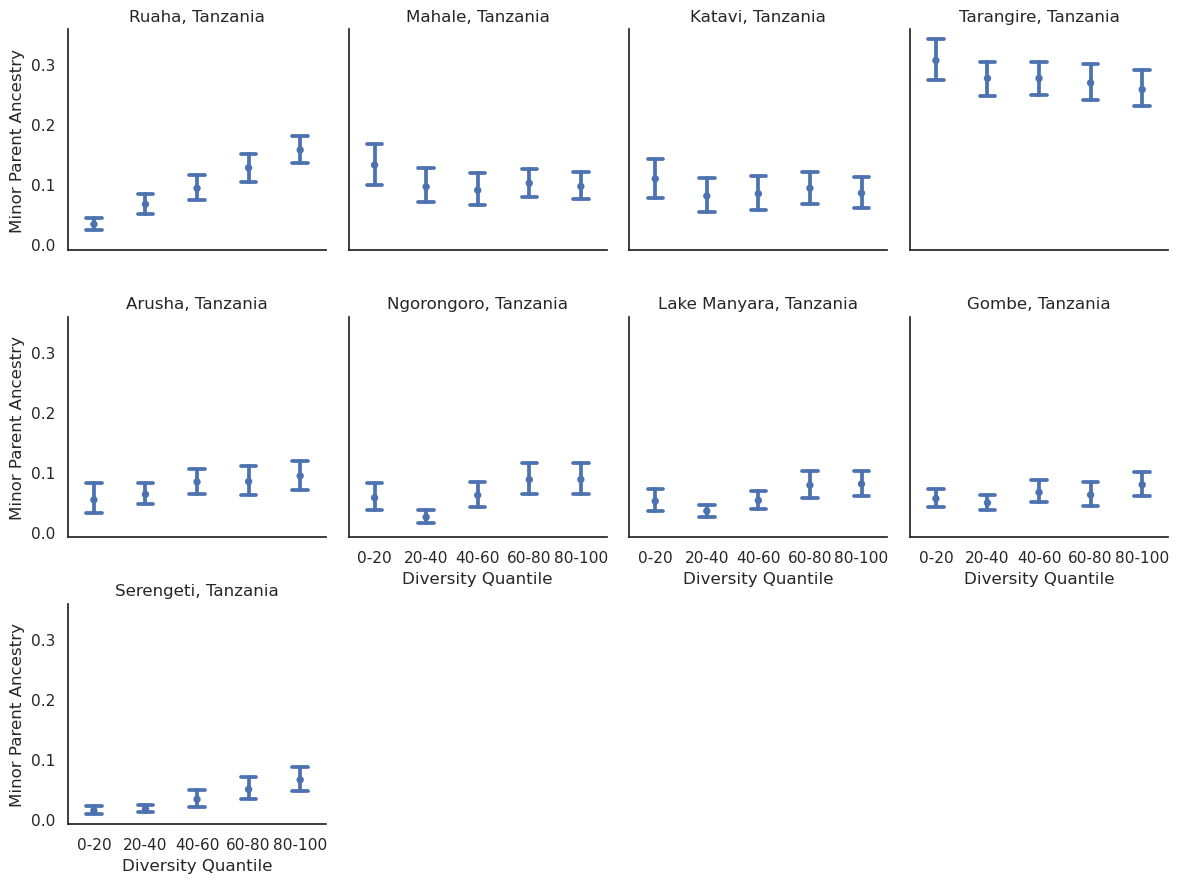

In [123]:
filter_qcut_chrX["Diversity Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
g = sns.FacetGrid(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(result_order_no_gog)], col="Origin",
                  col_wrap = 4, col_order=result_order_no_gog)
g.map_dataframe(sns.pointplot, y="minor_parent_percentage", x="Diversity Quantile", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
#g.set(xlim=(0, 0.25))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Diversity Quantile", ylabel="Minor Parent Ancestry")

/tmp/55160035/ipykernel_2576839/3625251695.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["Diversity Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
/tmp/55160035/ipykernel_2576839/3625251695.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["chrom_type"] = "chrX"


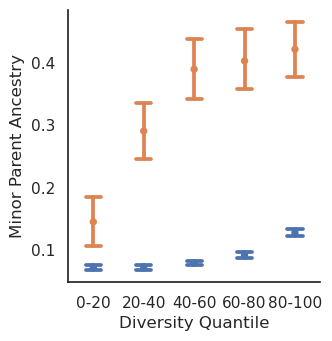

In [124]:
filter_qcut["Diversity Quantile"] = pd.qcut(filter_qcut.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
filter_qcut["chrom_type"] = "autosome"

filter_qcut_chrX["Diversity Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
filter_qcut_chrX["chrom_type"] = "chrX"
concat_df = pd.concat([filter_qcut, filter_qcut_chrX])

g = sns.FacetGrid(concat_df.loc[concat_df.Origin.isin(["Gog Woreda, Ethiopia"])], hue="chrom_type")
g.map_dataframe(sns.pointplot, y="minor_parent_percentage", x="Diversity Quantile", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
#g.set(xlim=(0, 0.25))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Diversity Quantile", ylabel="Minor Parent Ancestry")
g.fig.set_figwidth(3.8)
g.fig.set_figheight(3.8)

In [125]:
o_l, low_l, high_l, effect_l, effect_hl_l = [], [], [], [], []
filter_qcut_chrX["Recombination Quantile"] = pd.qcut(filter_qcut_chrX.cM, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
for o in result_order:
    s_df = filter_qcut_chrX.loc[filter_qcut_chrX.Origin == o]
    #print(o, s_df.groupby(["Recombination Quantile"])[["minor_parent_percentage"]].mean())
    low_mean = s_df.loc[s_df["Recombination Quantile"] == "0-20"][["minor_parent_percentage"]].mean()[0]*100
    high_mean = s_df.loc[s_df["Recombination Quantile"] == "80-100"][["minor_parent_percentage"]].mean()[0]*100
    o_l.append(o)
    low_l.append(low_mean)
    high_l.append(high_mean)
    effect_l.append(high_mean/low_mean-1)

mean_quantile_df = pd.DataFrame({"Origin": o_l, "0-20 Minor Parent Percentage": low_l, 
                        "80-100 Minor Parent Percentage": high_l, "Relative Increase": effect_l})
mean_quantile_df["Absolute Increase"] = mean_quantile_df["80-100 Minor Parent Percentage"]-mean_quantile_df["0-20 Minor Parent Percentage"]
mean_quantile_df

/tmp/55160035/ipykernel_2576839/851487991.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["Recombination Quantile"] = pd.qcut(filter_qcut_chrX.cM, 5,


,Origin,0-20 Minor Parent Percentage,80-100 Minor Parent Percentage,Relative Increase,Absolute Increase
0,"Ruaha, Tanzania",3.67,11.5,2.12,7.79
1,"Mahale, Tanzania",14.4,6.06,-0.579,-8.33
2,"Katavi, Tanzania",7.4,6.9,-0.0666,-0.492
3,"Tarangire, Tanzania",24.4,18.9,-0.227,-5.54
4,"Arusha, Tanzania",6,8.24,0.374,2.24
5,"Ngorongoro, Tanzania",6.8,8.37,0.232,1.57
6,"Lake Manyara, Tanzania",8.61,5.13,-0.404,-3.48
7,"Gombe, Tanzania",5.16,7.68,0.49,2.53
8,"Serengeti, Tanzania",4.92,3.58,-0.272,-1.34


In [227]:
o_l, low_l, high_l, effect_l, effect_hl_l = [], [], [], [], []
filter_qcut_chrX["Diversity Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
for o in result_order:
    s_df = filter_qcut_chrX.loc[filter_qcut_chrX.Origin == o]
    #print(o, s_df.groupby(["Diversity Quantile"])[["minor_parent_percentage"]].mean())
    low_mean = s_df.loc[s_df["Diversity Quantile"] == "0-20"][["minor_parent_percentage"]].mean()[0]*100
    high_mean = s_df.loc[s_df["Diversity Quantile"] == "80-100"][["minor_parent_percentage"]].mean()[0]*100
    o_l.append(o)
    low_l.append(low_mean)
    high_l.append(high_mean)
    effect_l.append(high_mean/low_mean)
    
mean_quantile_df = pd.DataFrame({"Origin": o_l, "0-20 Minor Parent Percentage": low_l, 
                        "80-100 Minor Parent Percentage": high_l, "Relative Increase": effect_l})
mean_quantile_df["Absolute Increase"] = mean_quantile_df["80-100 Minor Parent Percentage"]-mean_quantile_df["0-20 Minor Parent Percentage"]
mean_quantile_df

/tmp/55160035/ipykernel_2576839/1336098566.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["Diversity Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,


,Origin,0-20 Minor Parent Percentage,80-100 Minor Parent Percentage,Relative Increase,Absolute Increase
0,"Ruaha, Tanzania",3.36,15.7,4.68,12.4
1,"Mahale, Tanzania",13.2,9.67,0.731,-3.56
2,"Katavi, Tanzania",10.9,8.56,0.783,-2.38
3,"Tarangire, Tanzania",30.7,25.8,0.842,-4.84
4,"Arusha, Tanzania",5.3,9.3,1.75,4
5,"Ngorongoro, Tanzania",5.65,8.7,1.54,3.05
6,"Lake Manyara, Tanzania",5.09,7.96,1.56,2.87
7,"Gombe, Tanzania",5.51,7.82,1.42,2.3
8,"Serengeti, Tanzania",1.4,6.51,4.65,5.11
9,"Gog Woreda, Ethiopia",14.5,42.1,2.9,27.6


In [127]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

In [217]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut_chrX.loc[filter_qcut_chrX.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Ruaha, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                 1063
Model:                                 GLM   Df Residuals:                     1061
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      1.5599e-05
Method:                               IRLS   Log-Likelihood:                 403.30
Date:                     Fri, 14 Aug 2026   Deviance:                     0.016551
Time:                             11:48:28   Pearson chi2:                   0.0166
No. Iterations:                          3   Pseudo R-squ. (CS):            0.06520
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

In [218]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Ruaha, Tanzania",0.0136,132,0.296,2.54e-17,0.013,15.5
1,"Mahale, Tanzania",0.102,-3.57,1.32e-10,0.851,0.0159,19
2,"Katavi, Tanzania",0.098,-13.1,1.57e-08,0.526,0.0173,20.7
3,"Tarangire, Tanzania",0.307,-46.9,1.77e-61,0.0342,0.0186,22.2
4,"Arusha, Tanzania",0.0591,28.4,6.52e-05,0.108,0.0148,17.7
5,"Ngorongoro, Tanzania",0.0231,61.7,0.107,0.000314,0.0143,17.1
6,"Lake Manyara, Tanzania",0.024,53.7,0.0441,0.000154,0.0119,14.2
7,"Gombe, Tanzania",0.0303,47.2,0.0105,0.000829,0.0118,14.1
8,"Serengeti, Tanzania",-0.00587,65.1,0.575,1.78e-07,0.0105,12.5
9,"Gog Woreda, Ethiopia",0.205,214,1.85e-12,7.18e-10,0.0291,34.7


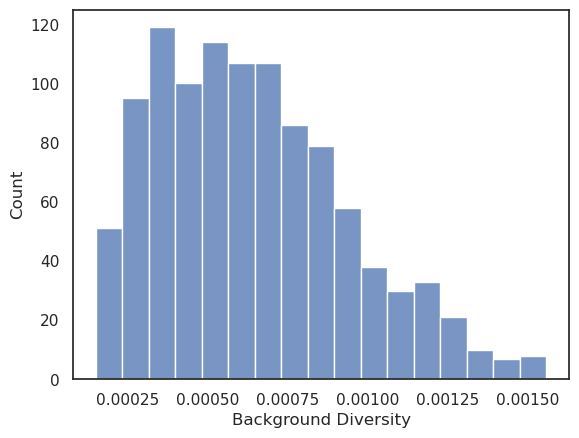

In [131]:
import matplotlib.ticker as ticker
g = sns.histplot(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)], x="diversity", )
g.set(xlabel = "Background Diversity")
g.xaxis.set_major_locator(ticker.MultipleLocator(0.00025))

In [132]:
filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)].diversity.mean(), filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)].diversity.median()

(0.0006392304305855299, 0.0006023039215686274)

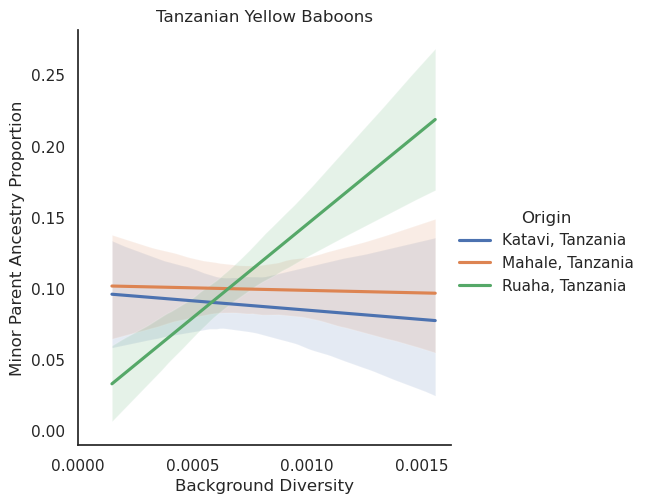

In [133]:
g = lmplot(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(yellows)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Yellow Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=[0, 0.0005, 0.001, 0.0015])

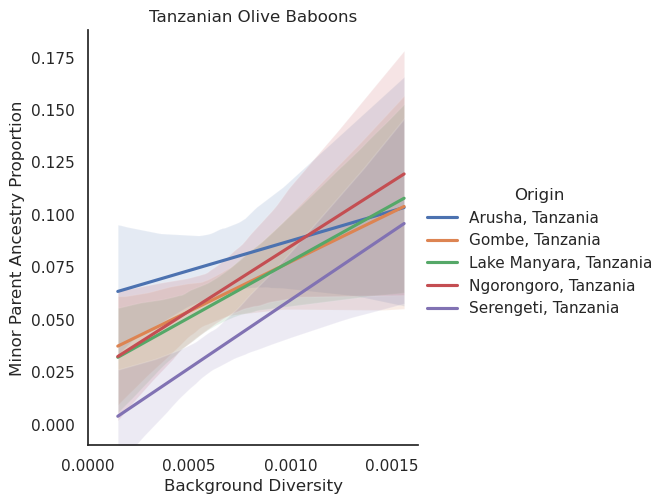

In [134]:
g = lmplot(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(olives)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Olive Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=[0, 0.0005, 0.001, 0.0015])

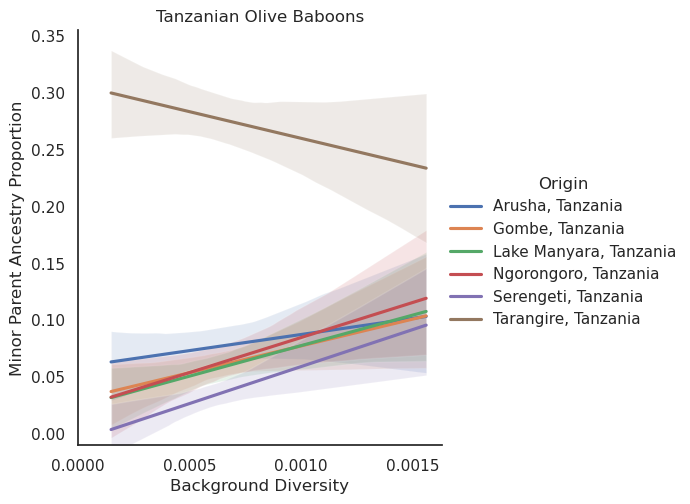

In [135]:
g = lmplot(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(olives_with_tarangire)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Olive Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=[0, 0.0005, 0.001, 0.0015])

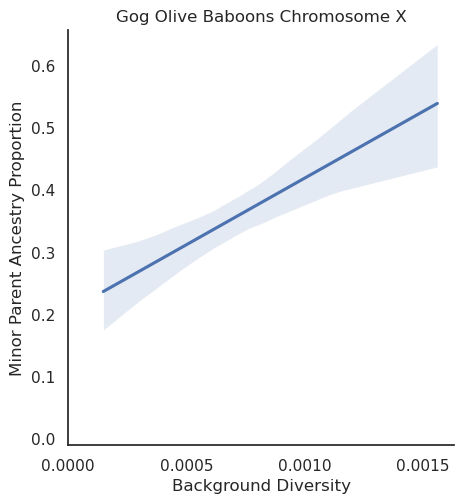

In [136]:
g = lmplot(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)], x="diversity", y="minor_parent_percentage",
                            scatter=False, weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Gog Olive Baboons Chromosome X")
g.set(ylim=(-0.01, None))
g.set(xticks=[0, 0.0005, 0.001, 0.0015])

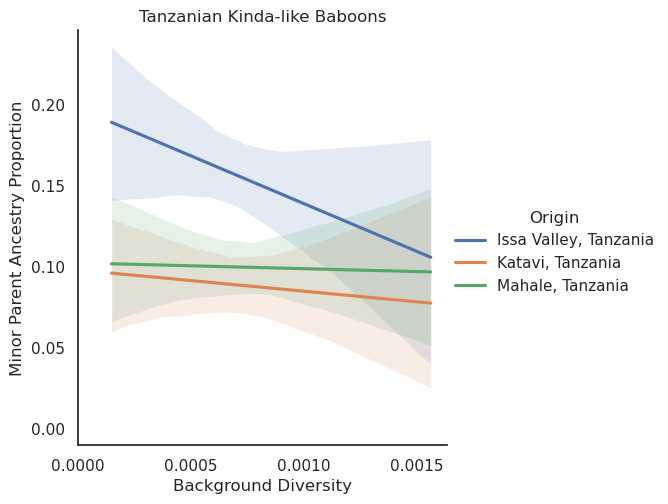

In [137]:
g = lmplot(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(["Mahale, Tanzania",
                                                           "Katavi, Tanzania",
                                                           "Issa Valley, Tanzania"])], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Kinda-like Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=[0, 0.0005, 0.001, 0.0015])

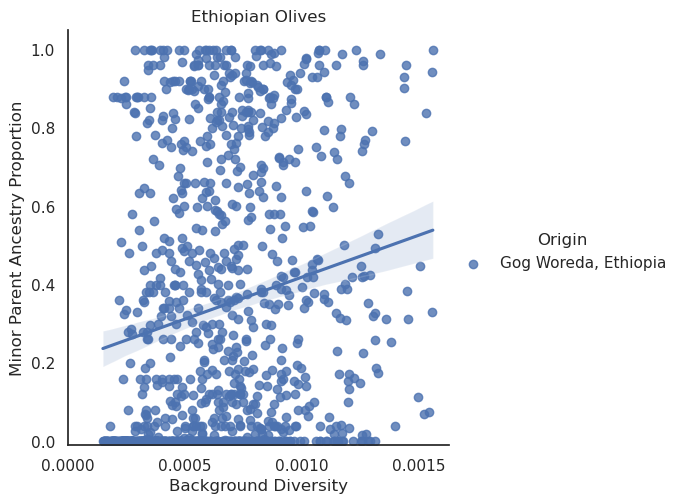

In [138]:
g = lmplot(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)], x="diversity", y="minor_parent_percentage",
                             hue="Origin", weighted=True, n_boot=1000) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Ethiopian Olives")
g.set(ylim=(-0.01, None))
g.set(xticks=[0, 0.0005, 0.001, 0.0015])

In [139]:
filter_callable_chrX["average_cM_window"].quantile([0.005, 0.995])

0.005     1.96e-08
0.995     4.15e-06
Name: average_cM_window, dtype: float64

In [140]:
filter_qcut_recomb_chrX = filter_callable_chrX.loc[(filter_callable_chrX.average_cM_window >=1.96e-08) &
                                                      (filter_callable_chrX.average_cM_window <=4.15e-06)]
filter_qcut_recomb_chrX["window_cM"] = filter_qcut_recomb_chrX.average_cM_window*100000

/tmp/55160035/ipykernel_2576839/1395215121.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_recomb_chrX["window_cM"] = filter_qcut_recomb_chrX.average_cM_window*100000


In [219]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut_recomb_chrX.loc[filter_qcut_recomb_chrX.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ window_cM", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Ruaha, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                 1063
Model:                                 GLM   Df Residuals:                     1061
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      1.5278e-05
Method:                               IRLS   Log-Likelihood:                 413.45
Date:                     Fri, 14 Aug 2026   Deviance:                     0.016210
Time:                             11:49:06   Pearson chi2:                   0.0162
No. Iterations:                          3   Pseudo R-squ. (CS):            0.05594
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

In [220]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Ruaha, Tanzania",0.0634,0.614,5.33e-15,5.19e-15,0.00811,0.0785
1,"Mahale, Tanzania",0.106,-0.0967,2.31e-26,0.318,0.01,0.0969
2,"Katavi, Tanzania",0.0815,0.0548,6.26e-14,0.602,0.0109,0.105
3,"Tarangire, Tanzania",0.284,-0.157,1.86e-130,0.164,0.0117,0.113
4,"Arusha, Tanzania",0.0714,0.112,1.85e-14,0.215,0.00933,0.0902
5,"Ngorongoro, Tanzania",0.0521,0.224,6.95e-09,0.0101,0.009,0.087
6,"Lake Manyara, Tanzania",0.0597,0.0699,2.16e-15,0.337,0.00752,0.0728
7,"Gombe, Tanzania",0.0497,0.194,1.94e-11,0.00684,0.00741,0.0716
8,"Serengeti, Tanzania",0.0218,0.275,0.000952,1.65e-05,0.00661,0.0639
9,"Gog Woreda, Ethiopia",0.279,1.07,1.45e-52,1.39e-09,0.0183,0.177


In [143]:
norm_filter_chrX = filter_qcut_chrX.loc[(filter_qcut_chrX.average_cM_window >=1.96e-08) &
                                                      (filter_qcut_chrX.average_cM_window <=4.15e-06)]
norm_filter_chrX["norm_diversity"] = (norm_filter_chrX.diversity-norm_filter_chrX.diversity.mean())/(norm_filter_chrX.diversity.std())
norm_filter_chrX["norm_recomb"] = (norm_filter_chrX.average_cM_window-norm_filter_chrX.average_cM_window.mean())/(norm_filter_chrX.average_cM_window.std())

/tmp/55160035/ipykernel_2576839/1252545395.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  norm_filter_chrX["norm_diversity"] = (norm_filter_chrX.diversity-norm_filter_chrX.diversity.mean())/(norm_filter_chrX.diversity.std())
/tmp/55160035/ipykernel_2576839/1252545395.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  norm_filter_chrX["norm_recomb"] = (norm_filter_chrX.average_cM_window-norm_filter_chrX.average_cM_window.mean())/(norm_filter_chrX.average_cM_window.std())


In [144]:
autosome_chrX_norm = pd.concat([norm_filter, norm_filter_chrX])
autosome_chrX_norm["chrom_type"] = ["autosome" if x != "chrX" else "chrX" for x in autosome_chrX_norm.chrom]

In [191]:
autosome_chrX_norm.groupby(["Origin", "chrom_type"])[["minor_parent_percentage"]].mean()*100

minor_parent_percentage
Origin                 chrom_type                         
Arusha, Tanzania       autosome                       8.47
                       chrX                           7.55
Gog Woreda, Ethiopia   autosome                       8.84
                       chrX                           32.9
Gombe, Tanzania        autosome                       5.35
                       chrX                           6.15
Issa Valley, Tanzania  autosome                         34
                       chrX                           15.9
Katavi, Tanzania       autosome                       9.64
                       chrX                           9.06
Lake Manyara, Tanzania autosome                       6.25
                       chrX                           5.86
Mahale, Tanzania       autosome                       12.5
                       chrX                           10.4
Ngorongoro, Tanzania   autosome                       6.35
                       chrX                           6.19
Ruaha, Tanzania        autosome                       9.17
                       chrX                            9.5
Selous, Tanzania       autosome                      0.296
                       chrX                         0.0842
Serengeti, Tanzania    autosome                       4.05
                       chrX                           3.59
Tarangire, Tanzania    autosome                       22.1
                       chrX                           27.8
Udzungwa, Tanzania     autosome                       1.43
                       chrX                           1.81

In [225]:
o_l, slope_l, pval_slope_l, slope_multi, stderr_slope_l, div_l, pdiv_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = autosome_chrX_norm.loc[(autosome_chrX_norm.Origin == o)]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ norm_diversity * chrom_type", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[3])
    pval_slope_l.append(glm_results.pvalues[3])
    slope_multi.append(glm_results.params[3]/glm_results.params[2])
    div_l.append(glm_results.params[2]), pdiv_l.append(glm_results.pvalues[2])

Ruaha, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                26257
Model:                                 GLM   Df Residuals:                    26253
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      1.8432e-05
Method:                               IRLS   Log-Likelihood:                 20892.
Date:                     Fri, 14 Aug 2026   Deviance:                      0.48390
Time:                             14:11:30   Pearson chi2:                    0.484
No. Iterations:                          3   Pseudo R-squ. (CS):           0.007286
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

Lake Manyara, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                26257
Model:                                 GLM   Df Residuals:                    26253
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      1.3454e-05
Method:                               IRLS   Log-Likelihood:                 25025.
Date:                     Fri, 14 Aug 2026   Deviance:                      0.35320
Time:                             14:11:31   Pearson chi2:                    0.353
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001526
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

In [226]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Autosome Slope": div_l, "Interaction Slope": slope_l,
                                 "Relative Increase": slope_multi, "Autosome P-value": pdiv_l,
                                 "Interaction Slope P-value": pval_slope_l
                               })
glm_diversity_df

,Origin,Autosome Slope,Interaction Slope,Relative Increase,Autosome P-value,Interaction Slope P-value
0,"Ruaha, Tanzania",0.00706,0.0298,4.21,4.51e-29,7.02e-09
1,"Mahale, Tanzania",0.00615,-0.00862,-1.4,1.05e-16,0.153
2,"Katavi, Tanzania",0.0069,-0.0109,-1.59,5.32e-15,0.128
3,"Tarangire, Tanzania",0.000656,-0.0113,-17.2,0.521,0.175
4,"Arusha, Tanzania",0.000961,0.00903,9.39,0.221,0.158
5,"Ngorongoro, Tanzania",0.00384,0.0171,4.46,8.64e-09,0.00161
6,"Lake Manyara, Tanzania",0.00258,0.0152,5.9,1.67e-06,0.000525
7,"Gombe, Tanzania",0.00585,0.00783,1.34,2.83e-29,0.0647
8,"Serengeti, Tanzania",0.00311,0.0176,5.66,6.13e-14,1.81e-07
9,"Gog Woreda, Ethiopia",0.0226,0.034,1.5,1.82e-119,1.75e-05


In [147]:
selected_pops = ["Mahale, Tanzania","Katavi, Tanzania","Issa Valley, Tanzania"]

o_l, slope_l, pval_slope_l, slope_multi, stderr_slope_l, div_l, pdiv_l = [], [], [], [], [], [], []
for o in selected_pops:
    o_div = autosome_chrX_norm.loc[(autosome_chrX_norm.Origin == o)]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ norm_diversity * chrom_type", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[3])
    pval_slope_l.append(glm_results.pvalues[3])
    slope_multi.append(glm_results.params[3]/glm_results.params[2])
    div_l.append(glm_results.params[2]), pdiv_l.append(glm_results.pvalues[2])

Mahale, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                26257
Model:                                 GLM   Df Residuals:                    26253
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      2.5418e-05
Method:                               IRLS   Log-Likelihood:                 16673.
Date:                     Fri, 14 Aug 2026   Deviance:                      0.66729
Time:                             08:50:30   Pearson chi2:                    0.667
No. Iterations:                          3   Pseudo R-squ. (CS):           0.003336
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

In [148]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Autosome Slope": div_l, "Interaction Slope": slope_l,
                                 "Relative Increase": slope_multi, "Autosome P-value": pdiv_l,
                                 "Interaction Slope P-value": pval_slope_l
                               })
glm_diversity_df

,Origin,Autosome Slope,Interaction Slope,Relative Increase,Autosome P-value,Interaction Slope P-value
0,"Mahale, Tanzania",0.00615,-0.00862,-1.4,1.05e-16,0.153
1,"Katavi, Tanzania",0.0069,-0.0109,-1.59,5.32e-15,0.128
2,"Issa Valley, Tanzania",0.0222,-0.045,-2.03,2.39e-28,0.00595


[None]

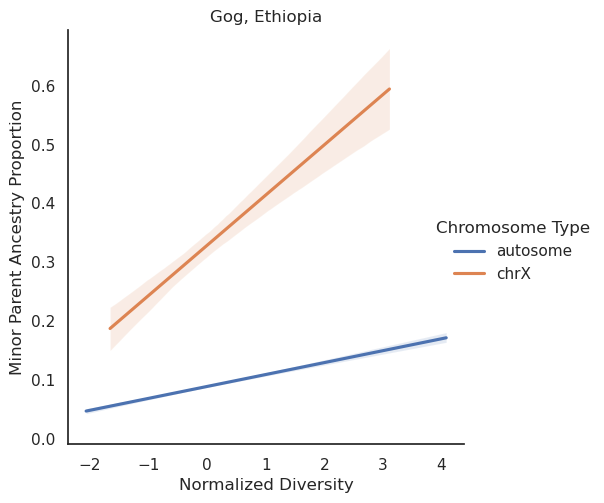

In [149]:
g = lmplot(autosome_chrX_norm.loc[autosome_chrX_norm.Origin.isin(gog)], x="norm_diversity", y="minor_parent_percentage",
                            scatter=False, hue="chrom_type", n_boot=1000) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Normalized Diversity", title="Gog, Ethiopia")
g.set(ylim=(-0.01, None))
g._legend.set(title="Chromosome Type")
#g.set(xticks=[0, 0.0005, 0.001, 0.0015])

In [150]:
o_l, slope_l, pval_slope_l, slope_multi, stderr_slope_l = [], [], [], [], []
for o in result_order:
    o_div = autosome_chrX_norm.loc[autosome_chrX_norm.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ norm_diversity * chrom_type", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[3])
    pval_slope_l.append(glm_results.pvalues[3]), stderr_slope_l.append(glm_results.bse[3])
    slope_multi.append(glm_results.params[3]/glm_results.params[2])

Ruaha, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                26257
Model:                                 GLM   Df Residuals:                    26253
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      1.8432e-05
Method:                               IRLS   Log-Likelihood:                 20892.
Date:                     Fri, 14 Aug 2026   Deviance:                      0.48390
Time:                             08:50:31   Pearson chi2:                    0.484
No. Iterations:                          3   Pseudo R-squ. (CS):           0.007286
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

Lake Manyara, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                26257
Model:                                 GLM   Df Residuals:                    26253
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      1.3454e-05
Method:                               IRLS   Log-Likelihood:                 25025.
Date:                     Fri, 14 Aug 2026   Deviance:                      0.35320
Time:                             08:50:32   Pearson chi2:                    0.353
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001526
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

In [211]:
o_l, slope_l, pval_slope_l, slope_multi, stderr_slope_l = [], [], [], [], []

o_div = autosome_chrX_norm.loc[(autosome_chrX_norm.Origin.isin(gog)) & (autosome_chrX_norm.chrom_type == "autosome")]
glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
print(glm_results.summary())

                    Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25205
Model:                                 GLM   Df Residuals:                    25203
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      4.2329e-05
Method:                               IRLS   Log-Likelihood:                 10102.
Date:                     Fri, 14 Aug 2026   Deviance:                       1.0668
Time:                             11:44:23   Pearson chi2:                     1.07
No. Iterations:                          3   Pseudo R-squ. (CS):            0.02190
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
In

[None]

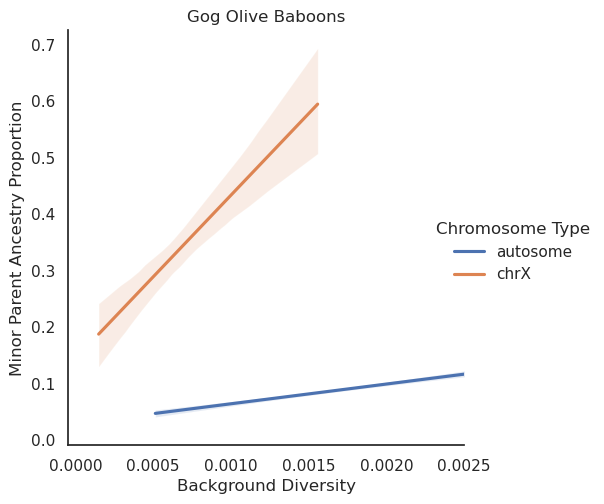

In [152]:
g = lmplot(autosome_chrX_norm.loc[autosome_chrX_norm.Origin.isin(gog)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="chrom_type", n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Gog Olive Baboons")
g.set(ylim=(-0.01, None), xlim=(None, 0.0025))
g._legend.set(title="Chromosome Type")

[None, None]

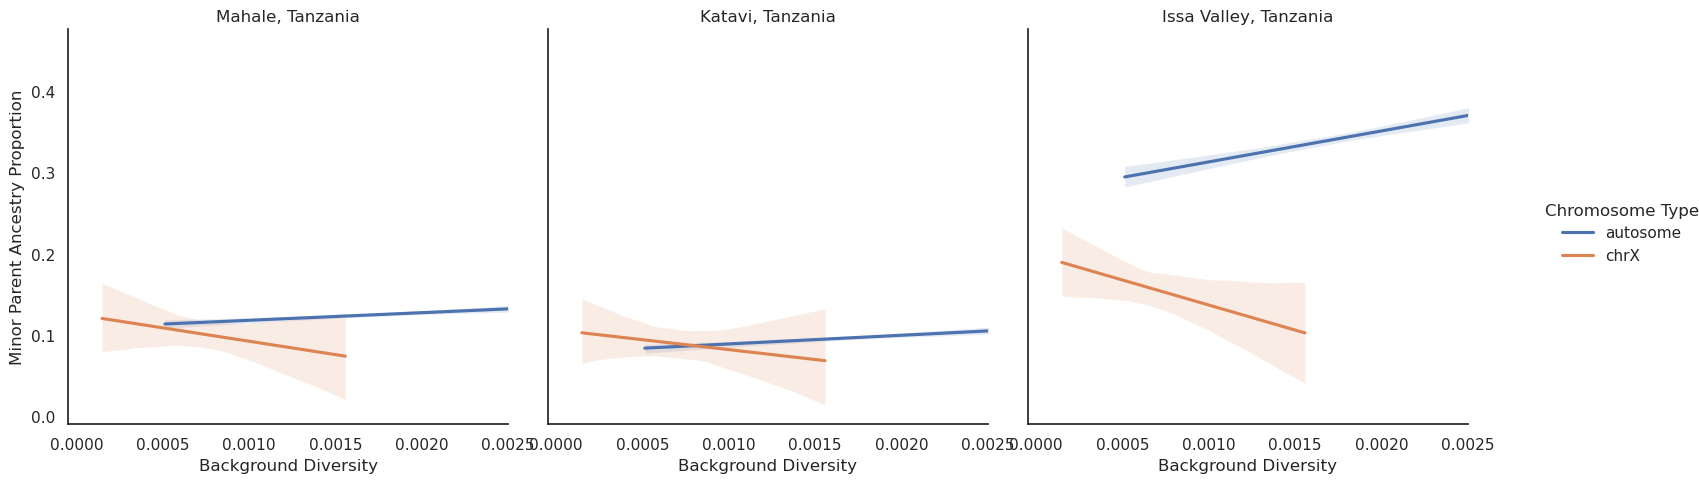

In [153]:
selected_pops = ["Mahale, Tanzania","Katavi, Tanzania","Issa Valley, Tanzania"]
g = lmplot(autosome_chrX_norm.loc[autosome_chrX_norm.Origin.isin(selected_pops)],
           x="diversity", y="minor_parent_percentage",
            scatter=False, hue="chrom_type", n_boot=1000, col="Origin", col_wrap=3,
          col_order=selected_pops, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity")
g.set(ylim=(-0.01, None), xlim=(None, 0.0025))
g.set_titles(col_template="{col_name}")
g._legend.set(title="Chromosome Type", bbox_to_anchor=(1.05, 0.5))

/tmp/55160035/ipykernel_2576839/512481415.py:609: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


[None]

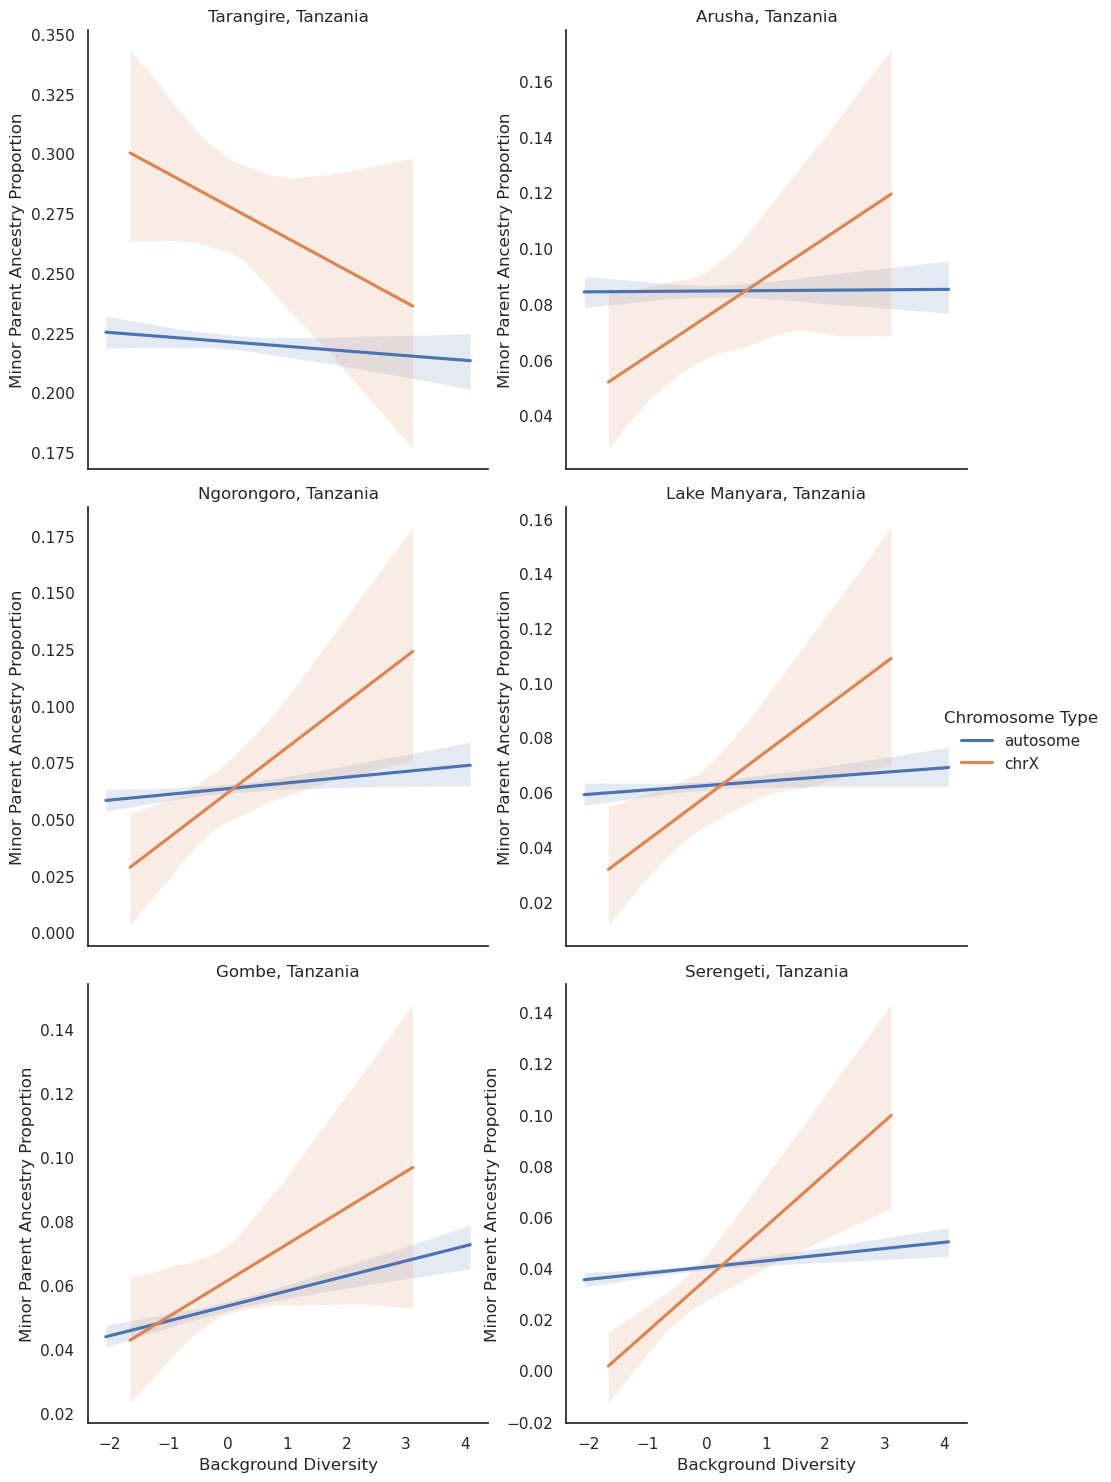

In [155]:
g = lmplot(autosome_chrX_norm.loc[autosome_chrX_norm.Origin.isin(focus_pops6)], x="norm_diversity", y="minor_parent_percentage",
                            scatter=False, hue="chrom_type", n_boot=1000, col="Origin", col_wrap=2, col_order=focus_pops6, ci=99.5, sharey=False) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity")
#g.set(ylim=(-0.01, None), xlim=(None, 0.0026))
g.set_titles(col_template="{col_name}")
g._legend.set(title="Chromosome Type")

In [156]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Interaction Slope": slope_l, "Relative Increase": slope_multi, "Slope P-value": pval_slope_l,
                               "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,Interaction Slope,Relative Increase,Slope P-value,Slope stderr


Removing high freq regions.

In [157]:
o_l, slope_l, pval_slope_l, slope_multi, stderr_slope_l, div_l, pdiv_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = autosome_chrX_norm.loc[(autosome_chrX_norm.Origin == o) & (autosome_chrX_norm.minor_parent_percentage <= 0.25)]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ norm_diversity * chrom_type", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[3])
    pval_slope_l.append(glm_results.pvalues[3])
    slope_multi.append(glm_results.params[3]/glm_results.params[2])
    div_l.append(glm_results.params[2]), pdiv_l.append(glm_results.pvalues[2])

Ruaha, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                24335
Model:                                 GLM   Df Residuals:                    24331
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      8.9842e-06
Method:                               IRLS   Log-Likelihood:                 28063.
Date:                     Fri, 14 Aug 2026   Deviance:                      0.21859
Time:                             08:50:41   Pearson chi2:                    0.219
No. Iterations:                          3   Pseudo R-squ. (CS):           0.004702
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

Lake Manyara, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25045
Model:                                 GLM   Df Residuals:                    25041
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      5.8662e-06
Method:                               IRLS   Log-Likelihood:                 34275.
Date:                     Fri, 14 Aug 2026   Deviance:                      0.14690
Time:                             08:50:42   Pearson chi2:                    0.147
No. Iterations:                          3   Pseudo R-squ. (CS):           0.002269
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

In [158]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Autosome Slope": div_l, "Interaction Slope": slope_l,
                                 "Relative Increase": slope_multi, "Autosome P-value": pdiv_l,
                                 "Interaction Slope P-value": pval_slope_l
                               })
glm_diversity_df

,Origin,Autosome Slope,Interaction Slope,Relative Increase,Autosome P-value,Interaction Slope P-value
0,"Ruaha, Tanzania",0.00389,0.0147,3.79,2.78e-17,0.000169
1,"Mahale, Tanzania",0.0035,0.00811,2.31,8.82e-14,0.0329
2,"Katavi, Tanzania",0.00278,-8.26e-06,-0.00298,9.57e-06,0.999
3,"Tarangire, Tanzania",0.000201,0.00135,6.73,0.739,0.795
4,"Arusha, Tanzania",0.000842,0.00342,4.06,0.093,0.397
5,"Ngorongoro, Tanzania",0.00194,0.00338,1.74,1.82e-06,0.319
6,"Lake Manyara, Tanzania",0.00185,0.00796,4.31,4.73e-07,0.00854
7,"Gombe, Tanzania",0.00362,0.00241,0.667,1.04e-23,0.416
8,"Serengeti, Tanzania",0.002,0.00638,3.19,2.16e-10,0.0145


/tmp/55160035/ipykernel_2576839/512481415.py:609: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


[None]

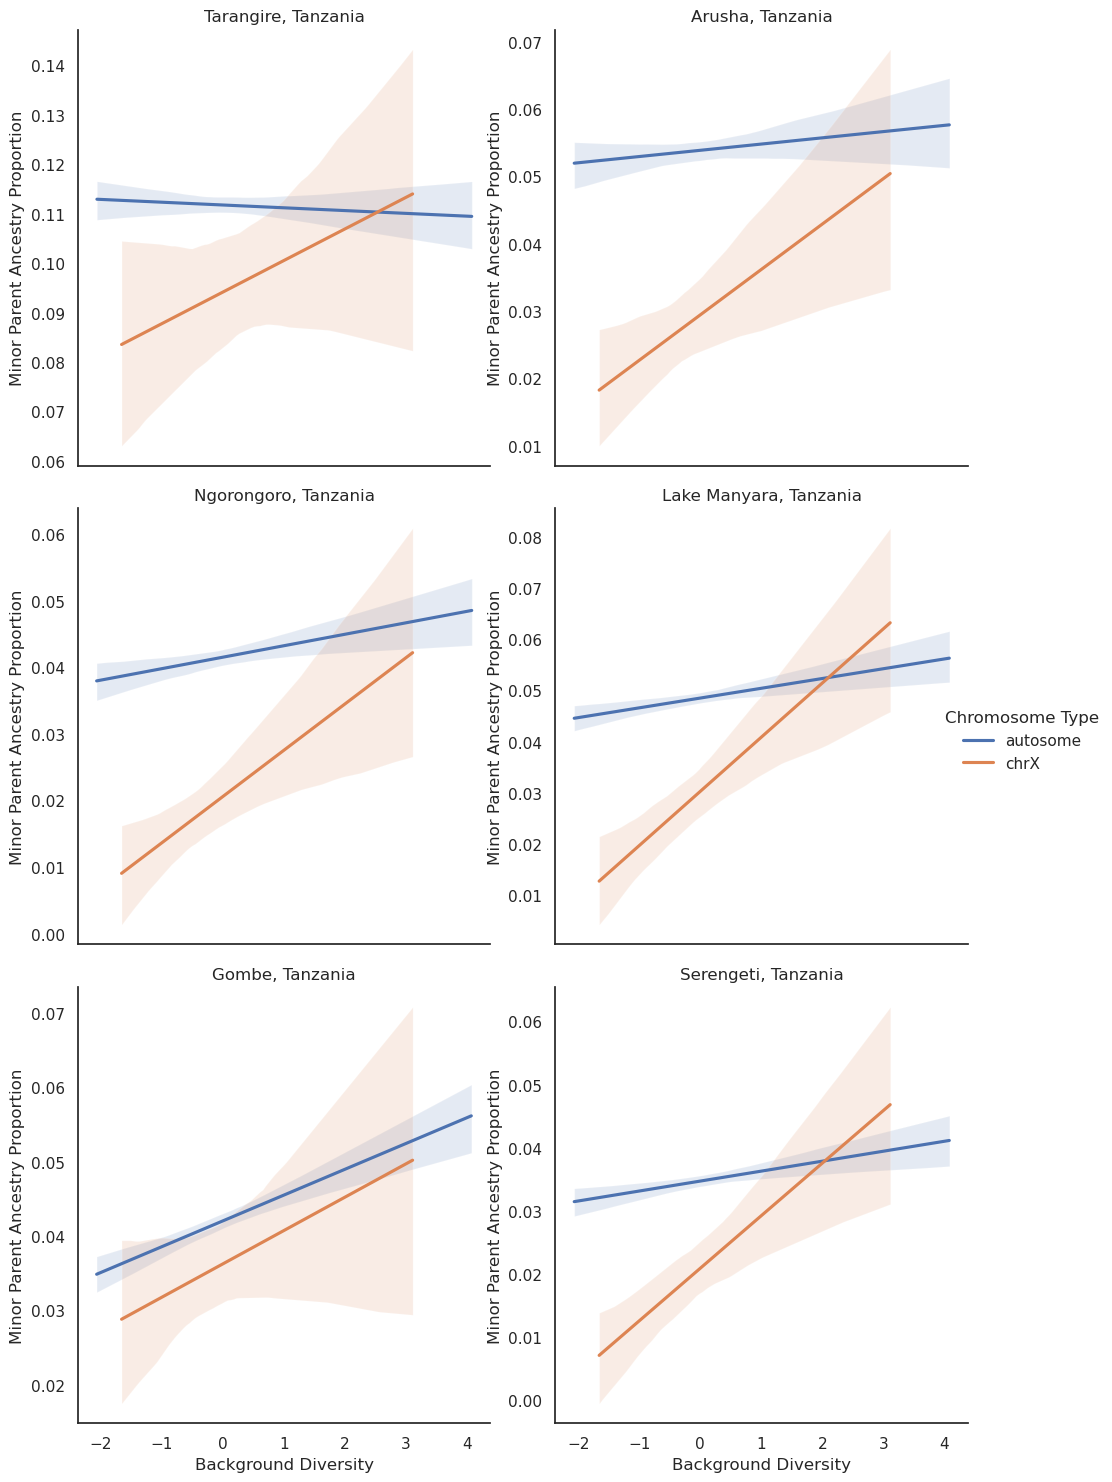

In [159]:
g = lmplot(autosome_chrX_norm.loc[autosome_chrX_norm.Origin.isin(focus_pops6) &
                                  (autosome_chrX_norm.minor_parent_percentage <= 0.25)], x="norm_diversity", y="minor_parent_percentage",
                            scatter=False, hue="chrom_type", n_boot=1000, col="Origin", col_wrap=2, col_order=focus_pops6, ci=99.5, sharey=False) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity")
#g.set(ylim=(-0.01, None), xlim=(None, 0.0026))
g.set_titles(col_template="{col_name}")
g._legend.set(title="Chromosome Type")

Quantiles of Admixture/Diversity

/tmp/55160035/ipykernel_2576839/3063631219.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["ancestry"] = ["Pure Major" if x <= 0.1 else "Pure Minor" if x >= 0.9


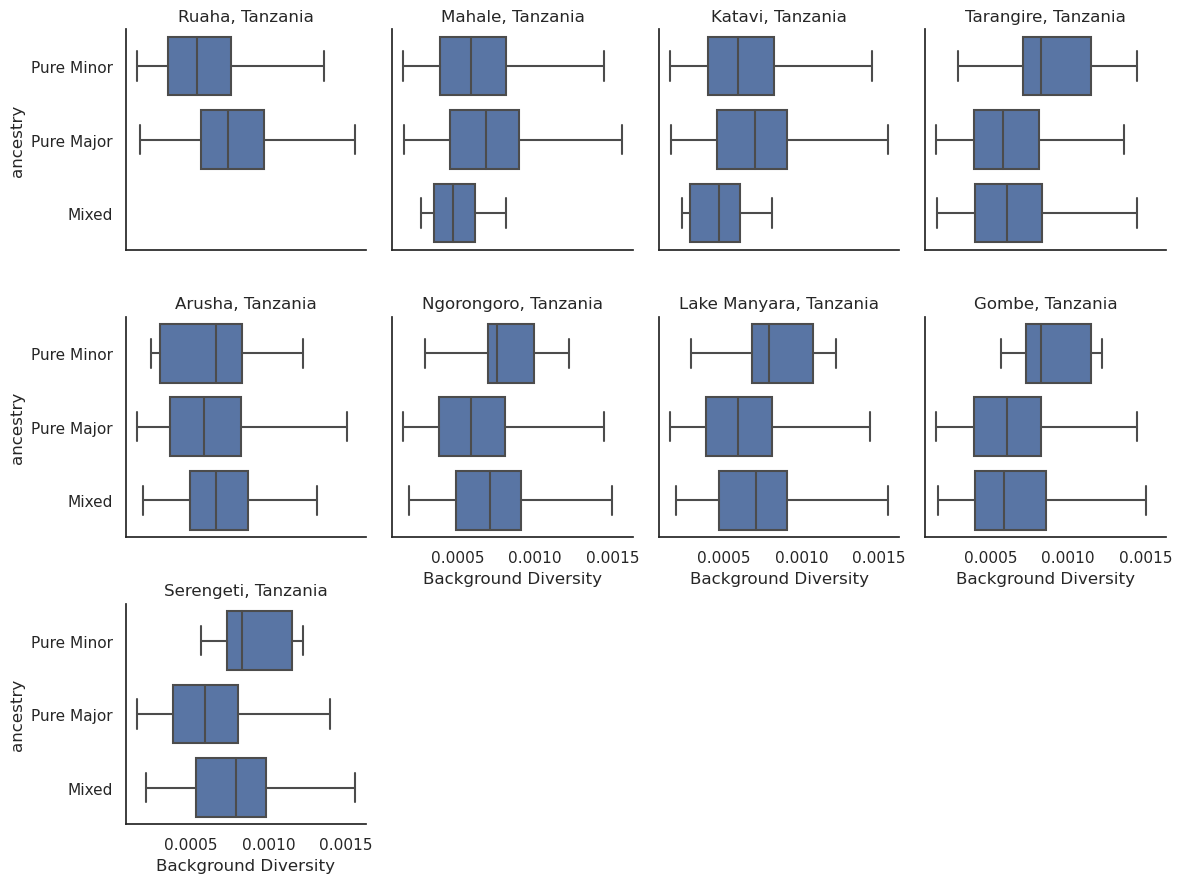

In [160]:
filter_qcut_chrX["ancestry"] = ["Pure Major" if x <= 0.1 else "Pure Minor" if x >= 0.9
                        else "Mixed" for x in filter_qcut_chrX["minor_parent_percentage"]]
g = sns.FacetGrid(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(result_order)], col="Origin",
                  col_wrap = 4, col_order=result_order)
g.map_dataframe(sns.boxplot, x="diversity", y="ancestry", fliersize=0)
g.set_titles(col_template="{col_name}")
g.set(xlabel="Background Diversity")

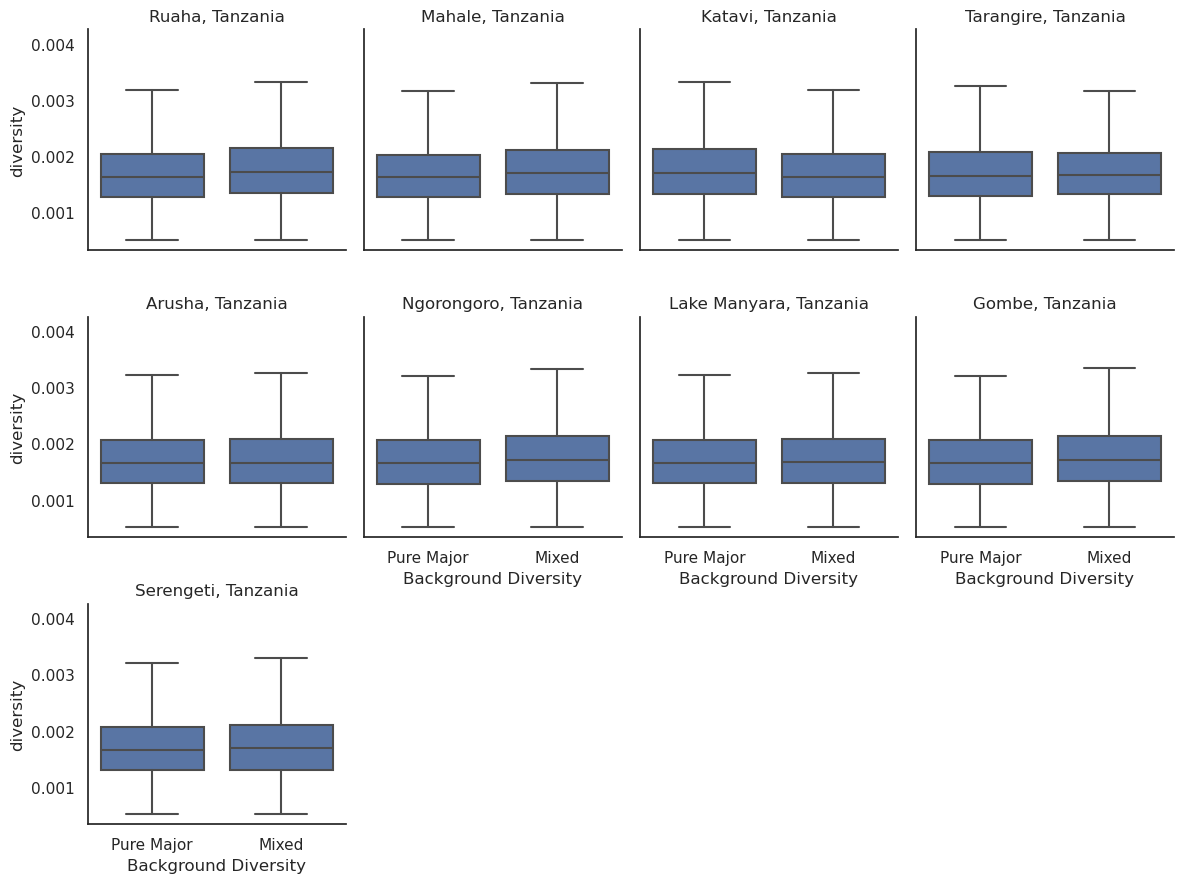

In [161]:
filter_qcut["ancestry"] = ["Pure Major" if x <= 0.1 else "Pure Minor" if x >= 0.9
                        else "Mixed" for x in filter_qcut["minor_parent_percentage"]]
g = sns.FacetGrid(filter_qcut.loc[filter_qcut.Origin.isin(result_order)], col="Origin",
                  col_wrap = 4, col_order=result_order)
g.map_dataframe(sns.boxplot, y="diversity", x="ancestry", fliersize=0)
g.set_titles(col_template="{col_name}")
g.set(xlabel="Background Diversity")

In [162]:
hama_df = filter_qcut.loc[(filter_qcut.Origin == "Gog Woreda, Ethiopia")][["chrom", "start", "ancestry"]]
hama_df_add = filter_qcut.merge(hama_df, on=["chrom", "start"])
hama_df_chrX = filter_qcut_chrX.loc[(filter_qcut_chrX.Origin == "Gog Woreda, Ethiopia")][["chrom", "start", "ancestry"]]
hama_df_add_chrX = filter_qcut_chrX.merge(hama_df_chrX, on=["chrom", "start"])

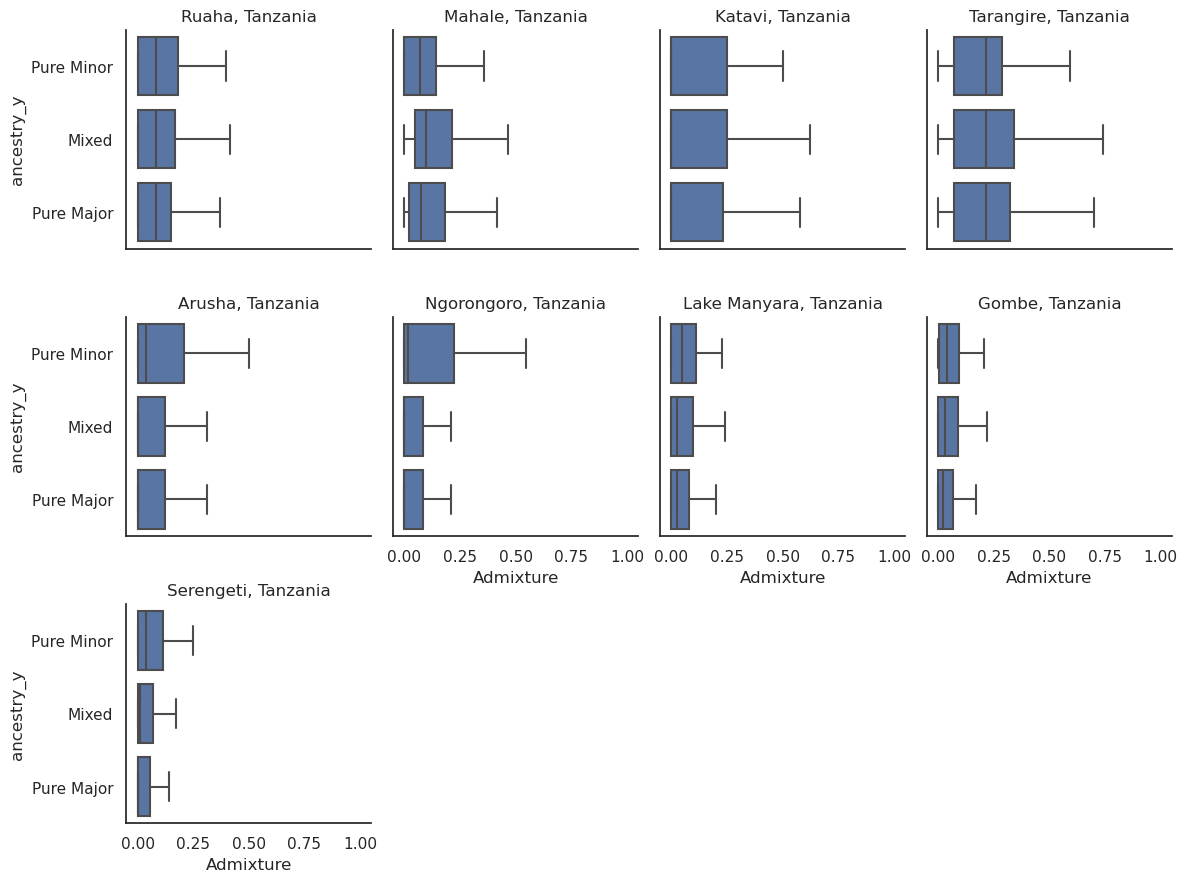

In [163]:
g = sns.FacetGrid(hama_df_add.loc[hama_df_add.Origin.isin(result_order)], col="Origin",
                  col_wrap = 4, col_order=result_order)
g.map_dataframe(sns.boxplot, x="minor_parent_percentage", y="ancestry_y", fliersize=0)
g.set_titles(col_template="{col_name}")
g.set(xlabel="Admixture")

In [164]:
for o in result_order:
    o_df = hama_df_add.loc[hama_df_add.Origin == o]
    print(o, o_df.groupby(["ancestry_y"])["minor_parent_percentage"].mean(),
         o_df.value_counts(["ancestry_y"]))
    print(mannwhitneyu(o_df.loc[o_df.ancestry_y == "Pure Minor"].minor_parent_percentage,
                   o_df.loc[o_df.ancestry_y == "Mixed"].minor_parent_percentage))

Ruaha, Tanzania ancestry_y
Mixed            0.0984
Pure Major       0.0893
Pure Minor        0.105
Name: minor_parent_percentage, dtype: float64 ancestry_y
Pure Major    18897
Mixed          6432
Pure Minor       77
Name: count, dtype: int64
MannwhitneyuResult(statistic=259530.0, pvalue=0.4603476245583936)
Mahale, Tanzania ancestry_y
Mixed             0.138
Pure Major         0.12
Pure Minor        0.122
Name: minor_parent_percentage, dtype: float64 ancestry_y
Pure Major    18897
Mixed          6432
Pure Minor       77
Name: count, dtype: int64
MannwhitneyuResult(statistic=207982.0, pvalue=0.015055203815220129)
Katavi, Tanzania ancestry_y
Mixed             0.102
Pure Major       0.0945
Pure Minor        0.111
Name: minor_parent_percentage, dtype: float64 ancestry_y
Pure Major    18897
Mixed          6432
Pure Minor       77
Name: count, dtype: int64
MannwhitneyuResult(statistic=248040.5, pvalue=0.9777950450863008)
Tarangire, Tanzania ancestry_y
Mixed             0.229
Pure Major       

In [165]:
for o in result_order:
    o_df = hama_df_add_chrX.loc[hama_df_add_chrX.Origin == o]
    print(o, o_df.groupby(["ancestry_y"])["minor_parent_percentage"].mean(),
         o_df.value_counts(["ancestry_y"]))
    print(mannwhitneyu(o_df.loc[o_df.ancestry_y == "Pure Minor"].minor_parent_percentage,
                   o_df.loc[o_df.ancestry_y == "Mixed"].minor_parent_percentage))

Ruaha, Tanzania ancestry_y
Mixed              0.13
Pure Major       0.0551
Pure Minor        0.115
Name: minor_parent_percentage, dtype: float64 ancestry_y
Mixed         488
Pure Major    464
Pure Minor    111
Name: count, dtype: int64
MannwhitneyuResult(statistic=23980.5, pvalue=0.04824175716059358)
Mahale, Tanzania ancestry_y
Mixed             0.109
Pure Major        0.102
Pure Minor       0.0865
Name: minor_parent_percentage, dtype: float64 ancestry_y
Mixed         488
Pure Major    464
Pure Minor    111
Name: count, dtype: int64
MannwhitneyuResult(statistic=24090.0, pvalue=0.046618502544394085)
Katavi, Tanzania ancestry_y
Mixed              0.11
Pure Major       0.0688
Pure Minor        0.096
Name: minor_parent_percentage, dtype: float64 ancestry_y
Mixed         488
Pure Major    464
Pure Minor    111
Name: count, dtype: int64
MannwhitneyuResult(statistic=26383.0, pvalue=0.5625886673017537)
Tarangire, Tanzania ancestry_y
Mixed             0.267
Pure Major        0.296
Pure Minor   

Merged quintiles

/tmp/55160035/ipykernel_2576839/2948258745.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["Diversity Quintile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
/tmp/55160035/ipykernel_2576839/2948258745.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["Chromosome Type"] = "chrX"


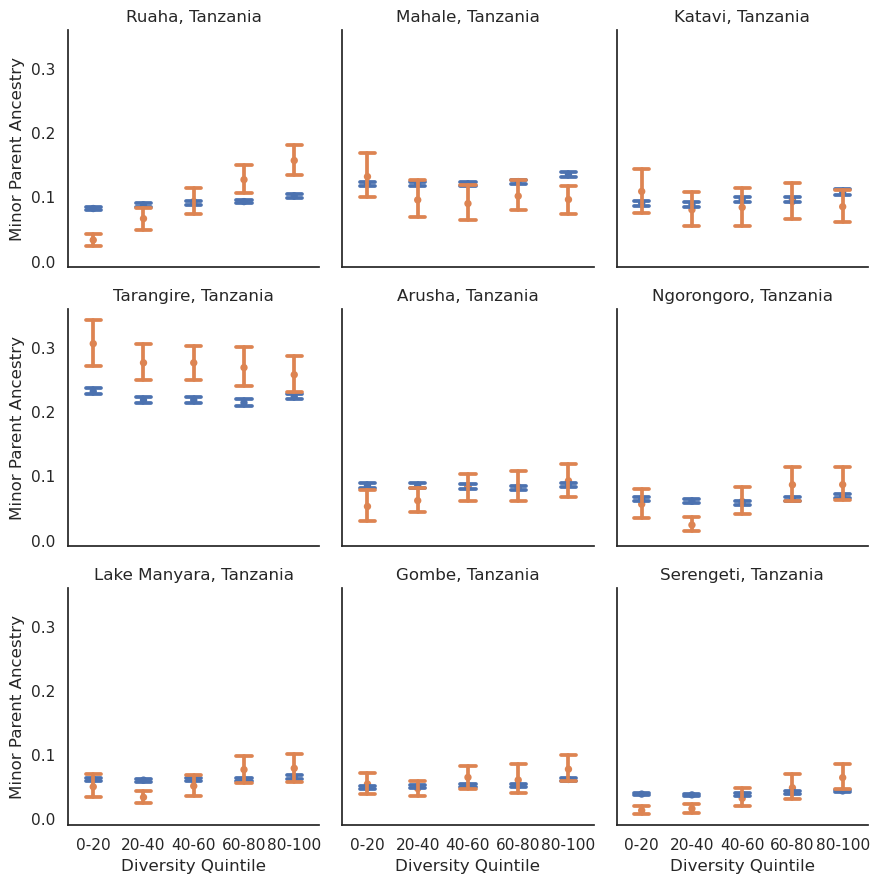

In [166]:
filter_qcut_chrX["Diversity Quintile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
filter_qcut_chrX["Chromosome Type"] = "chrX"

filter_qcut["Diversity Quintile"] = pd.qcut(filter_qcut.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
filter_qcut["Chromosome Type"] = "autosome"
filter_qcut_both = pd.concat([filter_qcut, filter_qcut_chrX])
g = sns.FacetGrid(filter_qcut_both.loc[filter_qcut_both.Origin.isin(result_order_no_gog)], col="Origin",
                  col_wrap = 3, col_order=result_order_no_gog, hue="Chromosome Type")
g.map_dataframe(sns.pointplot, y="minor_parent_percentage", x="Diversity Quantile", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
#g.set(xlim=(0, 0.25))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Diversity Quintile", ylabel="Minor Parent Ancestry")

In [167]:
mean_window_df_tanz_eth = window_df_tanz_eth.groupby(["chrom", "Origin", "individual", "start", "end"])[["north_sum"]].mean().reset_index()
mean_window_df_tanz = window_df_tanz.groupby(["chrom", "Origin", "individual", "start", "end"])[["north_sum"]].mean().reset_index()
admix_div_mean_ind = mean_diversity.merge(mean_window_df_tanz_eth, on=["chrom", "start"])
admix_div_mean_ind["Species"] = admix_div_mean_ind.Origin.map(dict(zip(meta_data_samples_sci.Origin, meta_data_samples_sci.Species)))
admix_div_mean_ind = admix_div_mean_ind.merge(c_r_g_df, on=["chrom", "start"])
admix_div_mean_ind["North Percentage"] = admix_div_mean_ind.north_sum/100000

In [168]:
admix_div_mean_ind = admix_div_mean_ind.loc[admix_div_mean_ind.Origin.isin(origins_interest)]
admix_div_mean_ind["minor_parent_percentage"] = [x if y == ("cynocephalus") or z == "Gog Woreda, Gambella region, Ethiopia_eth_case"
                                             else 1-x for x, y, z in zip(admix_div_mean_ind["North Percentage"],
                                                                         admix_div_mean_ind["Species"],
                                                                        admix_div_mean_ind["Origin"])]
admix_div_mean_ind["local_minor_ancestry"] = [min(x, 1-x) for x in admix_div_mean_ind["North Percentage"]]

In [169]:
filter_callable_ind = admix_div_mean_ind.loc[admix_div_mean_ind.callable_frac > 0.75]
filter_qcut_ind = filter_callable_ind.loc[(filter_callable_ind.diversity >= 0.000513) &
                                 (filter_callable_ind.diversity <= 0.00408)]

In [170]:
o_l, id_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut_ind.loc[(filter_qcut_ind.Origin == o)]
    for i in o_div.individual.unique():
        i_df = o_div.loc[o_div.individual == i]
        glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity", data=i_df,
                         var_weights=np.asarray(i_df["diversity"])).fit()
        print(o, i, glm_results.summary())
        o_l.append(o), id_l.append(i)
        slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
        pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
        stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Ruaha, Tanzania PD_0213                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      6.8444e-05
Method:                               IRLS   Log-Likelihood:                 4069.5
Date:                     Fri, 14 Aug 2026   Deviance:                       1.7387
Time:                             08:51:19   Pearson chi2:                     1.74
No. Iterations:                          3   Pseudo R-squ. (CS):           0.002266
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

Mahale, Tanzania PD_0228                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      9.1612e-05
Method:                               IRLS   Log-Likelihood:                 365.94
Date:                     Fri, 14 Aug 2026   Deviance:                       2.3273
Time:                             08:51:19   Pearson chi2:                     2.33
No. Iterations:                          3   Pseudo R-squ. (CS):           0.002537
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

Katavi, Tanzania PD_0233                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      7.6959e-05
Method:                               IRLS   Log-Likelihood:                 2580.0
Date:                     Fri, 14 Aug 2026   Deviance:                       1.9551
Time:                             08:51:20   Pearson chi2:                     1.96
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0005184
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

Arusha, Tanzania PD_0204                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      7.1946e-05
Method:                               IRLS   Log-Likelihood:                 3435.6
Date:                     Fri, 14 Aug 2026   Deviance:                       1.8277
Time:                             08:51:20   Pearson chi2:                     1.83
No. Iterations:                          3   Pseudo R-squ. (CS):          3.221e-05
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

Lake Manyara, Tanzania PD_0238                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      5.0756e-05
Method:                               IRLS   Log-Likelihood:                 7867.4
Date:                     Fri, 14 Aug 2026   Deviance:                       1.2894
Time:                             08:51:21   Pearson chi2:                     1.29
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0001096
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

...

Lake Manyara, Tanzania PD_0686                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      5.8266e-05
Method:                               IRLS   Log-Likelihood:                 6114.6
Date:                     Fri, 14 Aug 2026   Deviance:                       1.4802
Time:                             08:51:22   Pearson chi2:                     1.48
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0004724
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

Gombe, Tanzania PD_0504                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      4.9248e-05
Method:                               IRLS   Log-Likelihood:                 8250.6
Date:                     Fri, 14 Aug 2026   Deviance:                       1.2511
Time:                             08:51:23   Pearson chi2:                     1.25
No. Iterations:                          3   Pseudo R-squ. (CS):           0.002121
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

Gombe, Tanzania PD_0653                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      4.4811e-05
Method:                               IRLS   Log-Likelihood:                 9450.1
Date:                     Fri, 14 Aug 2026   Deviance:                       1.1384
Time:                             08:51:23   Pearson chi2:                     1.14
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0001858
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

Serengeti, Tanzania PD_0493                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      3.2278e-05
Method:                               IRLS   Log-Likelihood:                 13617.
Date:                     Fri, 14 Aug 2026   Deviance:                      0.81999
Time:                             08:51:24   Pearson chi2:                    0.820
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0006567
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

Serengeti, Tanzania PD_0499                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      3.4227e-05
Method:                               IRLS   Log-Likelihood:                 12873.
Date:                     Fri, 14 Aug 2026   Deviance:                      0.86951
Time:                             08:51:24   Pearson chi2:                    0.870
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0007251
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

In [171]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "individual": id_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,individual,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Ruaha, Tanzania",PD_0213,0.0624,15.6,1.87e-51,3.14e-14,0.00413,2.06
1,"Ruaha, Tanzania",PD_0214,0.0643,14.4,4.7e-55,2.1e-12,0.00412,2.05
2,"Ruaha, Tanzania",PD_0215,0.0664,10.2,1.23e-63,1.83e-07,0.00394,1.96
3,"Ruaha, Tanzania",PD_0216,0.087,7.61,1.56e-95,0.000269,0.00419,2.09
4,"Ruaha, Tanzania",PD_0217,0.0673,18.1,3.18e-59,2.19e-18,0.00415,2.07
...,...,...,...,...,...,...,...,...
77,"Serengeti, Tanzania",PD_0497,0.0352,4.06,3.93e-33,0.00551,0.00293,1.46
78,"Serengeti, Tanzania",PD_0498,0.0332,6.1,1.77e-29,3.25e-05,0.00295,1.47
79,"Serengeti, Tanzania",PD_0499,0.031,6.25,2.75e-26,1.76e-05,0.00292,1.46
80,"Serengeti, Tanzania",PD_0500,0.0302,7.77,7.76e-25,1.13e-07,0.00294,1.46


<Axes: xlabel='Slope', ylabel='Count'>

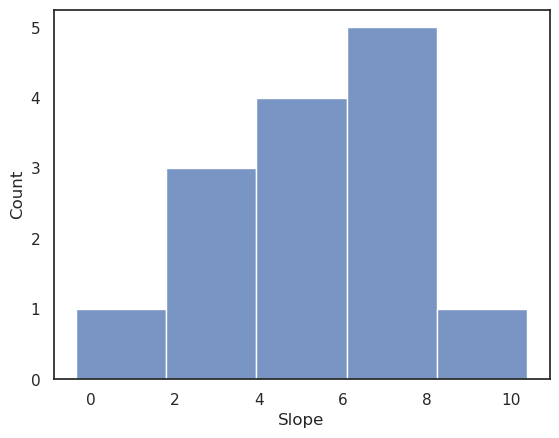

In [172]:
sns.histplot(data=glm_diversity_df.loc[glm_diversity_df.Origin == "Serengeti, Tanzania"], x="Slope")

In [173]:
glm_diversity_df.loc[glm_diversity_df.Origin == "Serengeti, Tanzania"]

,Origin,individual,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
68,"Serengeti, Tanzania",PD_0199,0.0329,3.45,2.41e-32,0.0126,0.00278,1.39
69,"Serengeti, Tanzania",PD_0200,0.0302,6.48,1.58e-25,6.93e-06,0.00289,1.44
70,"Serengeti, Tanzania",PD_0201,0.0344,4.91,1.23e-30,0.000989,0.00299,1.49
71,"Serengeti, Tanzania",PD_0202,0.0305,3.08,1.65e-29,0.0221,0.0027,1.35
72,"Serengeti, Tanzania",PD_0203,0.0295,4.94,3.42e-27,0.000275,0.00273,1.36
73,"Serengeti, Tanzania",PD_0493,0.0291,5.78,1.13e-24,4.4e-05,0.00284,1.41
74,"Serengeti, Tanzania",PD_0494,0.027,6.81,1.32e-20,2.37e-06,0.0029,1.44
75,"Serengeti, Tanzania",PD_0495,0.0312,3.59,2.42e-29,0.00943,0.00277,1.38
76,"Serengeti, Tanzania",PD_0496,0.0373,-0.353,6.53e-44,0.792,0.00268,1.34
77,"Serengeti, Tanzania",PD_0497,0.0352,4.06,3.93e-33,0.00551,0.00293,1.46


Admixture per chromosome investigation

In [174]:
ind_df = window_df_tanz_eth.groupby(["individual", "chrom", "Origin", "start", "end"])[["north_sum"]].mean().reset_index()
ind_df_div = mean_diversity.merge(ind_df, on=["chrom", "start"])
ind_df_div = ind_df_div.merge(c_r_g_df, on=["chrom", "start"])
ind_df_div["North Percentage"] = ind_df_div.north_sum/100000
ind_df_div["Species"] = ind_df_div.Origin.map(dict(zip(meta_data_samples_sci.Origin, meta_data_samples_sci.Species)))

#Selecting the cases of interest and setting Minor Parent Ancestry

ind_df_div = ind_df_div.loc[ind_df_div.Origin.isin(origins_interest)]
ind_df_div["minor_parent_percentage"] = [x if y == ("cynocephalus") or z == "Gog Woreda, Gambella region, Ethiopia_eth_case"
                                             else 1-x for x, y, z in zip(ind_df_div["North Percentage"],
                                                                         ind_df_div["Species"],
                                                                        ind_df_div["Origin"])]
ind_df_div = ind_df_div.loc[ind_df_div.callable_frac > 0.75]

In [175]:
o_l, low_l, high_l, effect_l, admix_l, chr_l, ind_l = [], [], [], [], [], [], []
#filter_qcut_chrX["Diversity Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
#                                                       labels=["0-20","20-40",
#                                                              "40-60","60-80",
#                                                              "80-100"])

for o in ind_df_div.Origin.unique():
    print(o)
    for c in ind_df_div.chrom.unique():
        print(c)
        for i in ind_df_div.loc[(ind_df_div.Origin == o) & (ind_df_div.chrom == c)].individual.unique():
            i_s_df = ind_df_div.loc[(ind_df_div.individual == i) & (ind_df_div.chrom == c)]
            #print(i)
            o_l.append(o), ind_l.append(i), chr_l.append(c)
            i_s_df["Diversity Quantile"] = pd.qcut(i_s_df.diversity, 2,
                                                       labels=["0-50", "50-100"])
            low_mean = i_s_df.loc[i_s_df["Diversity Quantile"] == "0-50"][["minor_parent_percentage"]].mean()[0]*100
            high_mean = i_s_df.loc[i_s_df["Diversity Quantile"] == "50-100"][["minor_parent_percentage"]].mean()[0]*100
            low_l.append(low_mean)
            high_l.append(high_mean)
            effect_l.append(high_mean/low_mean)
            admix_l.append(i_s_df.minor_parent_percentage.mean())

Serengeti, Tanzania
chr1


/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i_s_df["Diversity Quantile"] = pd.qcut(i_s_df.diversity, 2,
/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i_s_df["Diversity Quantile"] = pd.qcut(i_s_df.diversity, 2,
/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

chr10


/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i_s_df["Diversity Quantile"] = pd.qcut(i_s_df.diversity, 2,
/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i_s_df["Diversity Quantile"] = pd.qcut(i_s_df.diversity, 2,
/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

chr11


...

/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i_s_df["Diversity Quantile"] = pd.qcut(i_s_df.diversity, 2,
/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i_s_df["Diversity Quantile"] = pd.qcut(i_s_df.diversity, 2,
/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i_s_df["Diversity Quantile"] = pd.qcut(i_s_df.diversity, 2,
/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i_s_df["Diversity Quantile"] = pd.qcut(i_s_df.diversity, 2,
/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

chr9


/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i_s_df["Diversity Quantile"] = pd.qcut(i_s_df.diversity, 2,
/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i_s_df["Diversity Quantile"] = pd.qcut(i_s_df.diversity, 2,
/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i_s_df["Diversity Quantile"] = pd.qcut(i_s_df.diversity, 2,
/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i_s_df["Diversity Quantile"] = pd.qcut(i_s_df.diversity, 2,
/tmp/55160035/ipykernel_2576839/1377206513.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

In [176]:
admix_df = pd.DataFrame({"Origin": o_l, "individual": ind_l, "chrom": chr_l, "Low Diversity Quantile": low_l,
              "High Diversity Quantile": high_l, "Relative Difference": effect_l, "Mean_Admixture": admix_l})
admix_df["Absolute_Difference"] = admix_df["High Diversity Quantile"]-admix_df["Low Diversity Quantile"]
admix_df["Concentration"] = admix_df["High Diversity Quantile"]/admix_df.Mean_Admixture*0.5

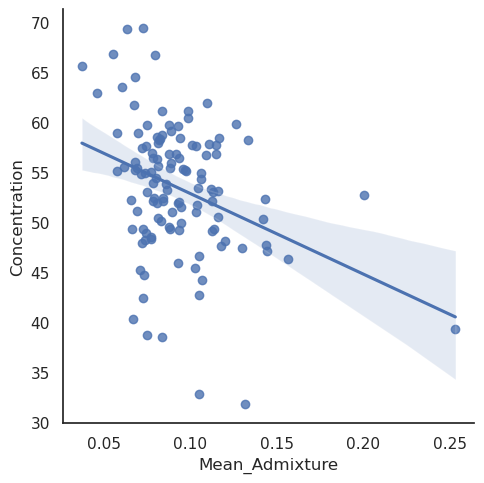

In [177]:
sns.lmplot(admix_df.loc[admix_df.Origin == "Ruaha, Tanzania"],
           x="Mean_Admixture", y="Concentration")

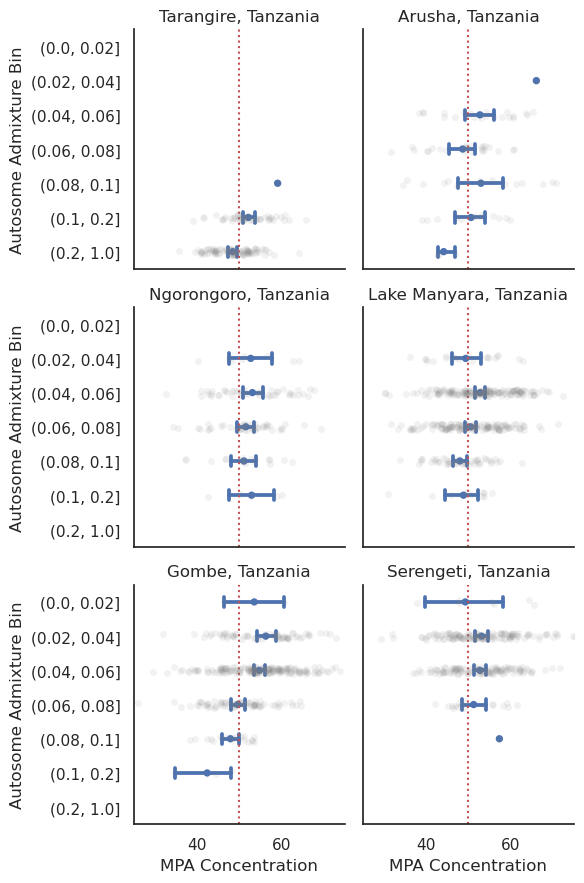

In [178]:
admix_df["Mean Admixture Bin"] = pd.cut(admix_df.Mean_Admixture, [0, 0.02, 0.04, 0.06,
                                                                  0.08, 0.1, 0.2, 1])
g = sns.FacetGrid(admix_df.loc[admix_df.Origin.isin(focus_pops6)], col="Origin",
                  col_wrap = 2, col_order=focus_pops6)
g.map_dataframe(sns.stripplot, y="Mean Admixture Bin", x="Concentration", alpha=.1, color="grey")
g.map_dataframe(sns.pointplot, y="Mean Admixture Bin", x="Concentration", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
g.set(xlim=(25, 75))
g.set_titles(col_template="{col_name}")
axes = g.axes.flatten()
for ax in g.axes.flat:
    ax.axvline(x=50, color='r', linestyle=':')
g.set(xlabel="MPA Concentration", ylabel="Autosome Admixture Bin")

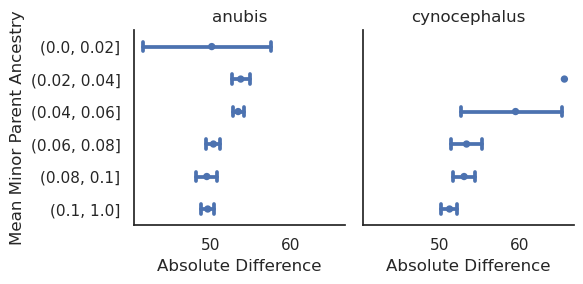

In [179]:
admix_df["Mean Admixture Bin"] = pd.cut(admix_df.Mean_Admixture, [0, 0.02, 0.04, 0.06,
                                                                  0.08, 0.1, 1])
admix_df["Species"] = admix_df.Origin.map(dict(zip(meta_data_samples_sci.Origin, meta_data_samples_sci.Species)))
g = sns.FacetGrid(admix_df.loc[admix_df.Origin.isin(result_order_no_gog)], col="Species",
                  col_wrap = 2)
g.map_dataframe(sns.pointplot, y="Mean Admixture Bin", x="Concentration", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
#g.set(xlim=(0, 0.25))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Absolute Difference", ylabel="Mean Minor Parent Ancestry")

In [180]:
glm_results = smf.glm(formula = "Absolute_Difference ~ Mean_Admixture+I(Mean_Admixture**2)",
                      data=admix_df.loc[admix_df.Origin == "Ruaha, Tanzania"]).fit()
print(glm_results.summary())

                  Generalized Linear Model Regression Results                  
Dep. Variable:     Absolute_Difference   No. Observations:                  120
Model:                             GLM   Df Residuals:                      117
Model Family:                 Gaussian   Df Model:                            2
Link Function:                Identity   Scale:                          5.5140
Method:                           IRLS   Log-Likelihood:                -271.19
Date:                 Fri, 14 Aug 2026   Deviance:                       645.13
Time:                         09:01:21   Pearson chi2:                     645.
No. Iterations:                      3   Pseudo R-squ. (CS):             0.1826
Covariance Type:             nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept         

In [181]:
glm_results = smf.glm(formula = "Absolute_Difference ~ Mean_Admixture", data=admix_df).fit()
print(glm_results.summary())

                  Generalized Linear Model Regression Results                  
Dep. Variable:     Absolute_Difference   No. Observations:                 2320
Model:                             GLM   Df Residuals:                     2318
Model Family:                 Gaussian   Df Model:                            1
Link Function:                Identity   Scale:                          7.8130
Method:                           IRLS   Log-Likelihood:                -5675.6
Date:                 Fri, 14 Aug 2026   Deviance:                       18110.
Time:                         09:01:21   Pearson chi2:                 1.81e+04
No. Iterations:                      3   Pseudo R-squ. (CS):           0.004437
Covariance Type:             nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.7223      0.0